# Machine Learning for Credit Risk Modeling: Predicting Customer Loan Default Using Financial and Behavioral Data

### Ploblem statement

Financial institutions face significant challenges in identifying loan applicants who are likely to default while ensuring that creditworthy customers are not unfairly rejected. Traditional credit risk assessment methods may fail to capture complex relationships within large and diverse financial datasets, leading to poor lending decisions and increased financial losses. This project aims to develop a machine learning model that predicts the probability of customer loan default using the Home Credit Default Risk dataset. By leveraging customer demographic information, financial history, credit bureau records, previous loan applications, installment payments, credit card activity, and POS/Cash loan history, the model seeks to improve credit risk assessment and support more accurate, data-driven lending decisions.

## Importing Libraries

In [76]:
#  Core data handling 
import os
import gc
import itertools
import random
import numpy as np
import pandas as pd

#  Data source 
from datasets import load_dataset

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Model selection / splitting 
from sklearn.model_selection import train_test_split, RandomizedSearchCV

#  Feature selection 
from sklearn.feature_selection import mutual_info_classif, RFE

#  Models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

#  Evaluation metrics 
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report,accuracy_score, roc_curve
)

# Interpretability 
import shap

#  Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [2]:
# Core libraries used in almost every cell below
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make inline plots render in Jupyter
%matplotlib inline

### Downloading the raw data

Pulls all 8 tables from the Hugging Face mirror of the competition. Saves each as a CSV into the `data/` folder.

In [3]:

# Make sure the data folder exists

folder = "data"
os.makedirs(folder, exist_ok=True)

# Home Credit dataset configurations

configs = {
    "application_train_dated": "application_train.csv",
    "application_test": "application_test.csv",
    "bureau": "bureau.csv",
    "bureau_balance": "bureau_balance.csv",
    "previous_application": "previous_application.csv",
    "POS_CASH_balance": "POS_CASH_balance.csv",
    "credit_card_balance": "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv",
    "sample_submission": "sample_submission.csv"
}

print("=" * 60)
print("Downloading Home Credit Default Risk Dataset")
print("=" * 60)

for config_name, output_file in configs.items():

    print(f"\nLoading: {config_name}")

    try:
        dataset = load_dataset(
            "mohameddhameem/home-credit-default-risk",
            config_name
        )

         # Convert the HF dataset split to a pandas DataFrame
        df = dataset["train"].to_pandas()

         # Save to CSV so the rest of the notebook can work with plain pandas
        save_path = os.path.join("data", output_file)
        df.to_csv(save_path, index=False)

        print(f"✓ Saved: {output_file}")
        print(f"  Shape: {df.shape}")

        # Free memory before moving to the next (large) table
        del dataset
        del df
        gc.collect()

    except Exception as e:
        print(f"✗ Failed: {config_name}")
        print(e)

print("\n" + "=" * 60)
print("Download Complete!")
print("=" * 60)


Loading: application_train_dated


✓ Saved: application_train.csv
  Shape: (307511, 123)

Loading: application_test
✓ Saved: application_test.csv
  Shape: (48744, 121)

Loading: bureau
✓ Saved: bureau.csv
  Shape: (1716428, 17)

Loading: bureau_balance
✓ Saved: bureau_balance.csv
  Shape: (27299925, 3)

Loading: previous_application
✓ Saved: previous_application.csv
  Shape: (1670214, 37)

Loading: POS_CASH_balance
✓ Saved: POS_CASH_balance.csv
  Shape: (10001358, 8)

Loading: credit_card_balance
✓ Saved: credit_card_balance.csv
  Shape: (3840312, 23)

Loading: installments_payments
✓ Saved: installments_payments.csv
  Shape: (13605401, 8)

Loading: sample_submission
✓ Saved: sample_submission.csv
  Shape: (48744, 2)

Download Complete!


Due to account verification issues with Kaggle, I was unable to access the dataset directly through the Kaggle API. As an alternative, I downloaded the Home Credit Default Risk dataset from the Hugging Face repository, which mirrors the original Kaggle competition dataset. This ensured I could proceed with the project while using the same data structure and features as the original competition dataset.

In [4]:
# Load the primary applicant-level table and take a first look
train = pd.read_csv("data/application_train.csv")

print("Shape:", train.shape)
train.head()

Shape: (307511, 123)


,SK_ID_CURR,application_date,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,2018-01-01,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,2018-01-01,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,2018-01-01,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,2018-01-01,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,2018-01-01,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Loaded my training dataset into Python to give me a quick overview of what it contains.

Do a data validation and integrity check. Before I begin the analysis, I need to  verify that all the required dataset files are present, appear complete, and contain the expected columns.

In [5]:
folder = "data"

expected_files = [
    "application_train.csv", "application_test.csv", "bureau.csv",
    "bureau_balance.csv", "previous_application.csv", "POS_CASH_balance.csv",
    "credit_card_balance.csv", "installments_payments.csv"
]

missing = [f for f in expected_files if not os.path.exists(os.path.join(folder, f))]
if missing:
    print(f"✗ MISSING: {missing}")
else:
    print(f"All {len(expected_files)} expected files found in '{folder}'")

check = pd.read_csv(os.path.join(folder, "application_train.csv"), nrows=5)
print("TARGET column present:", "TARGET" in check.columns)

All 8 expected files found in 'data'
TARGET column present: True


In [6]:

files = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv"
]

for file in files:
    df = pd.read_csv(f"data/{file}")
    print(f"{file}: {len(df):,} rows")

application_train.csv: 307,511 rows
application_test.csv: 48,744 rows
bureau.csv: 1,716,428 rows
bureau_balance.csv: 27,299,925 rows
previous_application.csv: 1,670,214 rows
POS_CASH_balance.csv: 10,001,358 rows
credit_card_balance.csv: 3,840,312 rows
installments_payments.csv: 13,605,401 rows


Before I start working with the data, I run two quick checks.

First, I make sure all 8 files are actually there, and that the main file has the TARGET column — that's the column that tells me who defaulted and who didn't, so if it's missing, nothing else in the project can work.

Second, I open each file and count how many rows it has. This helps me see how big each table is before I start combining them. For example, bureau_balance has over 27 million rows — way more than one row per person — which is why I had to shrink it down to one row per applicant before I could use it.

Basically, these two checks make sure everything is in place before I start the real work, so if something's wrong, I catch it early instead of getting a confusing error later on."

TARGET is a column with one value per applicant, and it only has two possible values:

0 = did not default → they repaid the loan

1 = did default → they failed to repay

##  Feature Engineering: Aggregate the Secondary Tables


There are 5 extra tables, and each one has many rows per person (like many past loans per applicant). Since our main table only has one row per person, we will first squish each of these 5 tables down to one row per person - using things like the average, total, and worst-case value to summarize their history. Then we merged each of these summarized tables onto our main table, matching rows by the person's ID. After each merge, we will check that the number of rows don't change, just to make sure nothing gets duplicated by mistake. 

In [7]:

# Define the folder where the input datasets are stored
INPUT_DIR = './data'

# Define the folder where processed files or outputs will be saved
OUTPUT_DIR = './output'

# Create the output folder if it does not already exist
# exist_ok=True prevents an error if the folder already exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

def downcast(df, exclude=('SK_ID_CURR',)):
    """Shrink dtypes to reduce memory footprint (float64->float32, int64->smallest int, etc)."""

    # Loop through every column in the dataframe one at a time
    for col in df.columns:

        if col in exclude:       # Skip columns listed in the exclude parameter
            continue

        if df[col].dtype == 'float64':             # Convert float64 columns to float32 This cuts memory usage roughly in half while maintaining good precision
            df[col] = df[col].astype('float32')

        elif df[col].dtype == 'int64':     # Convert int64 columns to the smallest possible integer type (e.g., int8, int16, int32) depending on the values stored
            df[col] = pd.to_numeric(df[col], downcast='integer')

        # If it's True/False, store it as a tiny integer (0 or 1) instead
        elif df[col].dtype == 'bool':
            df[col] = df[col].astype('int8')

        # If it's text, store it as a "category" type instead of plain text    
        elif df[col].dtype == object:
            df[col] = df[col].astype('category')
            
    return df

The Home Credit dataset contains millions of records across several CSV files. Therfore, two folders are created,  one to read the raw data from, and one to save our results into.This makes sure that save folder actually exists, to avoid crashing later when we try to write a file to it.


The **downcast function** is about saving memory. When data is loaded into into pandas, it often uses more computer memory than it needs to. For example, it might use a big number type to store something small, like someone's age. That's a waste of space.

So this function goes through every column and checks what kind of data it holds, then switches it to a smaller, lighter version that still holds the same information correctly:

* Decimal numbers - switched to a smaller decimal type
* Whole numbers - switched to the smallest whole-number type that fits
* True/False - switched to just 0 or 1
* Text - switched to a more compact text format 

By optimizing data types:

- Memory usage is significantly reduced.
- Data loads and operations become faster.
- The risk of running out of RAM is lower.
- Machine learning preprocessing becomes more efficient, especially when merging multiple large tables.

#### A. Aggregate **bureau_balance** - one row per **SK_ID_BUREAU**

This table is monthly loan status history at *other* credit institutions, keyed by ***SK_ID_BUREAU*** (not ***SK_ID_CURR***), so it has to be aggregated up one level before it can attach to ***bureau***.

In [8]:
# Read the CSV file using optimized data types to reduce memory usage.
# bureau_balance is a largest table in the project (~27 million rows), so specifying smaller data types saves a significant amount of RAM.
bb = pd.read_csv(
    f"{INPUT_DIR}/bureau_balance.csv",
    dtype={"SK_ID_BUREAU": "int32", "MONTHS_BALANCE": "int16", "STATUS": "category"},   # Tell pandas exactly what size/type to use for each column while loading,
    # instead of letting it guess, this saves a lot of memory right from the start
)
print("Loaded bureau_balance:", bb.shape)

# Convert each repayment status into separate binary columns.
# One-hot encode the monthly status flag (0-5 = days-past-due bucket, C = closed, X = unknown)
# This turns the single STATUS column into several 0/1 columns, one per status value
status_dummies = pd.get_dummies(bb["STATUS"], prefix="BB_STATUS")
# Keep only the required columns and combine them with the new dummy variables
bb = pd.concat([bb[["SK_ID_BUREAU", "MONTHS_BALANCE"]], status_dummies], axis=1)

# Aggregate to one row per SK_ID_BUREAU: how many months of history, its span, and how many
# months fell into each status bucket

# Aggregate Monthly Records
# Each loan (SK_ID_BUREAU) has many monthly records. summarize them into a single row
bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),        # Total number of months recorded
    BB_MONTHS_MIN=("MONTHS_BALANCE", "min"),            # Earliest month available
    BB_MONTHS_MAX=("MONTHS_BALANCE", "max"),            # Most recent month available
)

# Sum each dummy column.
# Since the dummy columns contain only 0 and 1, summing gives the number of months in each status.
bb_agg = bb_agg.join(bb.groupby("SK_ID_BUREAU")[status_dummies.columns].sum())

# Convert the grouped index (loan ID) back into a normal column
bb_agg.reset_index(inplace=True)

# Display the aggregated dataset
print("Aggregated bureau_balance shape:", bb_agg.shape)
# Store the summarized dataset as a Parquet file. Parquet files are smaller, faster to read, and more efficient than CSV files.
bb_agg.to_parquet(f"{OUTPUT_DIR}/agg_bureau_balance.parquet", index=False)

# Delete large objects that are no longer needed. ( The original dataset is very large and is no longer needed after aggregation. Deleting it frees up memory for the next processing steps.)
del bb, status_dummies
# Force Python's garbage collector to release memory.
gc.collect()

Loaded bureau_balance: (27299925, 3)
Aggregated bureau_balance shape: (817395, 12)


0

This table (bureau_balance) is huge - about 27 million rows - and it tracks the monthly status of loans that people had at other banks, not Home Credit itself. Each row is one month of one loan's history.

Since it's so big, the code loads it carefully, telling pandas the exact (small) data type for each column up front, instead of loading it the normal way and shrinking it after.

Each loan's monthly status is a code like "0" (up to date), "1-5" (increasingly overdue), "C" (closed), or "X" (unknown). The code turns that one status column into several yes/no columns  one per possible status  so it can be counted and summed later.

Then it groups everything by loan ID and narrows each loan down to one summary row: how many months of history it has, the first and last month, and how many months it spent in each status.

Finally, it saves this smaller summary table to disk, and clears the big original table out of memory since it's no longer needed - this keeps the notebook from running out of memory when working with such a large file.

#### B. Aggregate **bureau** (+ bureau_balance features) - one row per **SK_ID_CURR**

Past loans at other credit institutions. Each applicant can have many rows here (many past loans), so we one-hot the categoricals, fold in the ***bureau_balance*** aggregates, then group by ***SK_ID_CURR*** with mean/sum/min/max.

In [9]:
# Load the bureau dataset

# Read the bureau.csv file into a DataFrame.
# This dataset contains information about each applicant's previous loans from external credit bureaus.bureau = pd.read_csv(f"{INPUT_DIR}/bureau.csv")
bureau = pd.read_csv(f"{INPUT_DIR}/bureau.csv")

print("Loaded bureau:", bureau.shape)

# Merge with the aggregated bureau_balance dataset. Combine bureau.csv with the aggregated bureau_balance
# using SK_ID_BUREAU as the common key.
# how="left" ensures that every bureau loan is kept, even if it has no matching bureau_balance record.

bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")

# One-hot encode the categorical columns (Convert each category into separate binary columns.)
# This allows machine learning algorithms to use categorical variables.
for col in ["CREDIT_ACTIVE", "CREDIT_CURRENCY", "CREDIT_TYPE"]:
    bureau = pd.concat([bureau, pd.get_dummies(bureau[col], prefix=col)], axis=1)

# Select Numeric Columns for Aggregation
# Numeric columns get mean/sum/min/max per applicant (captures typical + extreme loan behavior)
num_cols = [
    # Days since the credit was granted
    "DAYS_CREDIT",
    # Number of overdue days
    "CREDIT_DAY_OVERDUE",
    # Expected credit end date
    "DAYS_CREDIT_ENDDATE",
    # Actual credit closing date
    "DAYS_ENDDATE_FACT",
    # Maximum overdue credit amount
    "AMT_CREDIT_MAX_OVERDUE",
    # Number of times the loan was prolonged
    "CNT_CREDIT_PROLONG",
    # Total credit amount
    "AMT_CREDIT_SUM",
    # Outstanding debt
    "AMT_CREDIT_SUM_DEBT",
    # Credit limit
    "AMT_CREDIT_SUM_LIMIT",
    # Amount currently overdue
    "AMT_CREDIT_SUM_OVERDUE",
    # Last bureau update
    "DAYS_CREDIT_UPDATE",
    # Loan annuity
    "AMT_ANNUITY",
    # Aggregated bureau_balance variables
    "BB_MONTHS_COUNT",
    "BB_MONTHS_MIN",
    "BB_MONTHS_MAX",
]
# Find the names of the new  columns we just created above, to summarize them too
bb_status_cols = [c for c in bureau.columns if c.startswith("BB_STATUS_")]
dummy_cols = [c for c in bureau.columns if c.startswith(("CREDIT_ACTIVE_", "CREDIT_CURRENCY_", "CREDIT_TYPE_"))]

# Define Aggregation Rules
# For every numeric column calculate:Mean, Sum, Minimum, Maximum
agg_dict = {c: ["mean", "sum", "min", "max"] for c in num_cols + bb_status_cols}
# For dummy variables calculate only the mean. Example:CREDIT_ACTIVE_Active Mean = proportion of loans that are Active.
agg_dict.update({c: "mean" for c in dummy_cols})     
# Count the total number of bureau loans each applicant has. 
agg_dict["SK_ID_BUREAU"] = "count" 

# Aggregate to One Row Per Customer
# Group all rows by person (applicant ID), and apply the summary plan above
bureau_agg = bureau.groupby("SK_ID_CURR").agg(agg_dict)
# Rename the resulting columns to be clear and consistent
bureau_agg.columns = ["BUREAU_" + "_".join(col).upper() for col in bureau_agg.columns]
# Turn the applicant ID from an index back into a normal column
bureau_agg.reset_index(inplace=True)

print("Aggregated bureau shape:", bureau_agg.shape)
bureau_agg.to_parquet(f"{OUTPUT_DIR}/agg_bureau.parquet", index=False)

del bureau, bb_agg
gc.collect()


Loaded bureau: (1716428, 17)
Aggregated bureau shape: (305811, 117)


0

This picks up the bureau table - every past loan a person had at other banks, not Home Credit. One person can appear many times here (once per past loan), so just like before, everything needs to be squished down to one row per person.

First, it attaches the monthly-history summary from the earlier step, matching by loan ID, so each loan now also carries info like how many months of history it had.

Then it converts the text columns (like loan status: active, closed, etc.) into simple yes/no columns, since summary math like "average" or "sum" only works on numbers, not text.

After that, it groups everything by person and boils each person's loans down into one row, calculating for each number column: the average, the total, the smallest, and the largest value. This captures both the "typical" loan behavior and the worst-case one (like their biggest overdue amount). For the yes/no columns, it just takes the average, which tells you what share of a person's loans fall into each category (for example, what percent were closed loans).

It also counts how many past loans each person had in total.

Finally, it renames the columns clearly, saves the result, and clears the big tables out of memory to keep things running smoothly.

#### C. Aggregate **POS_CASH_balance** - one row per **SK_ID_CURR**

Monthly balance history on POS/cash loans. This table already carries ***SK_ID_CURR*** directly, so no intermediate ***SK_ID_PREV*** step is needed.

In [10]:
# Load the POS_CASH_balance dataset

# Read the dataset while specifying smaller data types to reduce memory usage.
pos = pd.read_csv(
    f"{INPUT_DIR}/POS_CASH_balance.csv",
    dtype={
        "SK_ID_PREV": "int32",                 # Previous loan ID
        "SK_ID_CURR": "int32",                 # Customer ID
        "MONTHS_BALANCE": "int16",             # Months before current application
        "CNT_INSTALMENT": "float32",           # Total scheduled installments
        "CNT_INSTALMENT_FUTURE": "float32",    # Remaining installments
        "NAME_CONTRACT_STATUS": "category",    # Loan status
        "SK_DPD": "int32",                     # Days Past Due
        "SK_DPD_DEF": "int32",                 # Days Past Due with tolerance
    },
)
print("Loaded POS_CASH_balance:", pos.shape)

# One-hot encode contract status (Active, Completed, Signed, etc.)
status_dummies = pd.get_dummies(pos["NAME_CONTRACT_STATUS"], prefix="POS_STATUS")
# Remove the original status column and append the newly created dummy columns.
pos = pd.concat([pos.drop(columns=["NAME_CONTRACT_STATUS"]), status_dummies], axis=1)

# Define Aggregation Rules

# For numerical variables calculate:Mean,Maximum
agg_dict = {c: ["mean", "max"] for c in ["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"]}

# For dummy variables calculate the mean. The mean represents the proportion of loans in each contract status.
agg_dict.update({c: "mean" for c in status_dummies.columns})

# Count the number of unique previous POS/Cash loans belonging to each customer.
agg_dict["SK_ID_PREV"] = "nunique" 

# Aggregate to One Row Per Customer
# Group all POS/Cash loans belonging to each customer.
pos_agg = pos.groupby("SK_ID_CURR").agg(agg_dict)
# Rename Columns
pos_agg.columns = ["POS_" + "_".join(col).upper() for col in pos_agg.columns]

# Convert SK_ID_CURR back into a normal column.
pos_agg.reset_index(inplace=True)

print("Aggregated POS_CASH_balance shape:", pos_agg.shape)
pos_agg.to_parquet(f"{OUTPUT_DIR}/agg_pos_cash.parquet", index=False)

del pos, status_dummies
gc.collect()

Loaded POS_CASH_balance: (10001358, 8)
Aggregated POS_CASH_balance shape: (337252, 19)


0

The POS_CASH_balance.csv table records the month-by-month repayment history of customers' Point-of-Sale (POS) and cash loans, meaning each customer can appear many times-once for each month of each loan. To make the data suitable for machine learning, the code summarizes these records into one row per customer (SK_ID_CURR).

It first converts the loan status (e.g., Active, Completed) into numeric dummy variables, then groups all records belonging to the same customer. For each customer, it calculates key features such as the average and maximum number of installments, the average and maximum days past due, the proportion of loans in each contract status, and the total number of unique POS/Cash loans. Finally, it renames the columns, saves the aggregated dataset, and frees memory by deleting the large raw dataset, ensuring efficient processing of the remaining tables.

#### D. Aggregate **credit_card_balance** -  one row per **SK_ID_CURR**

In [11]:

# Load the Credit Card Balance Dataset


# Read the credit_card_balance.csv file.
# This dataset contains monthly information about customers'credit card accounts.

cc = pd.read_csv(f"{INPUT_DIR}/credit_card_balance.csv")

# Display the number of rows and columns loaded
print("Loaded credit_card_balance:", cc.shape)


# One-Hot Encode the Contract Status

# Convert each contract status (e.g., Active, Completed) into binary (0/1) columns.

status_dummies = pd.get_dummies(
    cc["NAME_CONTRACT_STATUS"],
    prefix="CC_STATUS"
)

# Remove the original contract status column and append the dummy variables.

cc = pd.concat(
    [
        cc.drop(columns=["NAME_CONTRACT_STATUS"]),
        status_dummies
    ],
    axis=1
)

# Select Numeric Columns
# These are the numerical variables that describe customers' credit card usage and repayment behavior.

num_cols = [
    # Current outstanding balance
    "AMT_BALANCE",
    # Credit limit
    "AMT_CREDIT_LIMIT_ACTUAL",
    # ATM cash withdrawals
    "AMT_DRAWINGS_ATM_CURRENT",
    # Total withdrawals
    "AMT_DRAWINGS_CURRENT",
    # Other withdrawals
    "AMT_DRAWINGS_OTHER_CURRENT",
    # POS purchases
    "AMT_DRAWINGS_POS_CURRENT",
    # Minimum payment due
    "AMT_INST_MIN_REGULARITY",
    # Current payment
    "AMT_PAYMENT_CURRENT",
    # Total payment
    "AMT_PAYMENT_TOTAL_CURRENT",
    # Principal receivable
    "AMT_RECEIVABLE_PRINCIPAL",
    # Receivable amount
    "AMT_RECIVABLE",
    # Total receivable
    "AMT_TOTAL_RECEIVABLE",
    # Number of ATM withdrawals
    "CNT_DRAWINGS_ATM_CURRENT",
    # Total number of withdrawals
    "CNT_DRAWINGS_CURRENT",
    # Other withdrawals count
    "CNT_DRAWINGS_OTHER_CURRENT",
    # POS withdrawal count
    "CNT_DRAWINGS_POS_CURRENT",
    # Number of completed installments
    "CNT_INSTALMENT_MATURE_CUM",
    # Days past due
    "SK_DPD",
    # Days past due with tolerance
    "SK_DPD_DEF"
]

# Define Aggregation Rules

# For each numeric variable calculate:Mean ,Maximum, Sum

agg_dict = {
    c: ["mean", "max", "sum"]
    for c in num_cols
}

# For contract status dummy variables,calculate the mean (proportion).
agg_dict.update({c: "mean"for c in status_dummies.columns})

# Count the number of unique credit card accounts each customer has had.

agg_dict["SK_ID_PREV"] = "nunique"

# Aggregate to One Row Per Customer
# Group all credit card records belonging to each customer.

cc_agg = cc.groupby("SK_ID_CURR").agg(agg_dict)

# Rename Columns
# Create descriptive column names.
cc_agg.columns = ["CC_" + "_".join(col).upper()for col in cc_agg.columns]

# Convert SK_ID_CURR back into a normal column.
cc_agg.reset_index(inplace=True)

# Display Results
print("Aggregated credit_card_balance shape:", cc_agg.shape)

# Save the Aggregated Dataset
cc_agg.to_parquet(f"{OUTPUT_DIR}/agg_credit_card.parquet",index=False)

# Free Memory
# Delete objects that are no longer needed.
del cc, status_dummies
# Force Python to release unused memory.
gc.collect()

Loaded credit_card_balance: (3840312, 23)
Aggregated credit_card_balance shape: (103558, 66)


0

The credit_card_balance.csv table contains the month-by-month history of customers' credit card accounts, so the same customer can appear many times-once for each month of each credit card account. To prepare the data for machine learning, the code summarizes these records into one row per customer (SK_ID_CURR).

It first converts the credit card contract status (such as Active or Completed) into numeric dummy variables, then groups all records belonging to the same customer. For each customer, it calculates the average, maximum, and total values for key credit card features such as balances, credit limits, payments, withdrawals, receivables, and days past due. It also calculates the proportion of records in each contract status and counts the number of unique credit card accounts each customer has had. Finally, it renames the columns with clear prefixes, saves the aggregated dataset, and frees memory by deleting the large raw dataset before processing the next table.

#### E. Aggregate **previous_application** - one row per **SK_ID_CURR**


In [12]:
# Load the Previous Application Dataset

# Read the previous_application.csv file. Each row represents one previous loan application made by a customer.
prev = pd.read_csv(f"{INPUT_DIR}/previous_application.csv")
print("Loaded previous_application:", prev.shape)

# In this dataset, the value 365243 is a placeholdermeaning "date not available".
# Replace it with NaN (missing value) so it is ignored during statistical calculations.
for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
    prev[col] = prev[col].replace(365243, np.nan)

# One-hot encode all categorical columns, then take the per-applicant mean of each dummy
# (= "share of previous applications that had this category")
cat_cols = [
    "NAME_CONTRACT_TYPE", "FLAG_LAST_APPL_PER_CONTRACT", "NAME_CASH_LOAN_PURPOSE",
    "NAME_CONTRACT_STATUS", "NAME_PAYMENT_TYPE", "CODE_REJECT_REASON", "NAME_TYPE_SUITE",
    "NAME_CLIENT_TYPE", "NAME_GOODS_CATEGORY", "NAME_PORTFOLIO", "NAME_PRODUCT_TYPE",
    "CHANNEL_TYPE", "NAME_SELLER_INDUSTRY", "NAME_YIELD_GROUP", "PRODUCT_COMBINATION",
]
# Start with the customer ID.
dummy_frames = [prev[["SK_ID_CURR"]]]
# Store the names of all dummy columns.
dummy_cols = []
# Convert each categorical column into dummy variables.
for col in cat_cols:
    d = pd.get_dummies(prev[col], prefix=col)
    dummy_cols.extend(d.columns.tolist())
    dummy_frames.append(d)
# Combine all dummy variables into one DataFrame.
prev_dummies = pd.concat(dummy_frames, axis=1)

# Numeric columns get mean/max/min/sum
num_cols = [
    "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE",
    "RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED", "DAYS_DECISION",
    "SELLERPLACE_AREA", "CNT_PAYMENT", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION", "NFLAG_INSURED_ON_APPROVAL",
]

# For every numeric column calculate:Mean, Maximum, Minimum, Sum
agg_dict = {c: ["mean", "max", "min", "sum"] for c in num_cols}
# Group all previous applications belonging to each customer.
prev_num_agg = prev.groupby("SK_ID_CURR").agg(agg_dict)
prev_num_agg.columns = ["PREV_" + "_".join(col).upper() for col in prev_num_agg.columns]

# Calculate the mean of every dummy column.
# This represents the proportion of previous applications in each category.
prev_dummy_agg = prev_dummies.groupby("SK_ID_CURR")[dummy_cols].mean()
# Rename columns.
prev_dummy_agg.columns = ["PREV_" + c.upper() + "_MEAN" for c in prev_dummy_agg.columns]
# Count how many previous applications each customer has submitted.
prev_count = prev.groupby("SK_ID_CURR")["SK_ID_PREV"].count().rename("PREV_COUNT")
# Merge All Aggregated Features
# Combine: Numeric summaries, Dummy summaries, Application count
prev_agg = prev_num_agg.join(prev_dummy_agg).join(prev_count)
# Convert SK_ID_CURR back into a normal column.
prev_agg.reset_index(inplace=True)
#  Display Results
print("Aggregated previous_application shape:", prev_agg.shape)
# Save the Aggregated Dataset
prev_agg.to_parquet(f"{OUTPUT_DIR}/agg_previous_app.parquet", index=False)

# Free Memory

# Delete large DataFrames that are no longer needed.

del prev
del prev_dummies
del prev_num_agg
del prev_dummy_agg

# Release unused memory.

gc.collect()

Loaded previous_application: (1670214, 37)
Aggregated previous_application shape: (338857, 206)


0

The previous_application.csv table contains information about every previous loan application that customers submitted to Home Credit (as opposed to the bureau table, which contains loans from other financial institutions). Since one customer may have submitted multiple applications over time, they can appear many times in this table. To prepare the data for machine learning, the code summarizes all previous applications into one row per customer (SK_ID_CURR).

The first step addresses a data quality issue where several date columns use the value 365243 as a placeholder to indicate that no date is available. These placeholder values are replaced with NaN (missing values) so they are ignored during statistical calculations and do not distort measures such as averages, minimums, or maximums.

Next, all categorical (text) variables, such as loan purpose, contract status, payment type, and rejection reason, are converted into numeric dummy variables, allowing them to be included in the aggregation process.

The customer-level summary is then created in three parts. First, for each numerical feature-such as loan amounts, interest rates, installment information, and application dates-the code calculates the mean, maximum, minimum, and total across all previous applications. Second, for each dummy variable, it calculates the mean, which represents the proportion of a customer's previous applications that belong to each category (for example, the share of applications that were approved or refused). Finally, it counts the total number of previous loan applications submitted by each customer.

The three sets of aggregated features are then combined into a single customer-level dataset. Lastly, the columns are renamed with clear PREV_ prefixes, the summarized dataset is saved as a Parquet file, and the large intermediate DataFrames are removed from memory to improve efficiency before processing the next dataset.

#### F. Aggregate **installments_payments**

In [13]:

# Load the installments_payments table - the actual record of whether each loan installment was paid on time and in full
inst = pd.read_csv(f"{INPUT_DIR}/installments_payments.csv")
print("Loaded installments_payments:", inst.shape)

# Create New Payment Behaviour Features

# Calculate how many days late (or early) a payment was made.
# Positive value  -> payment was late.
# Zero            -> payment was made on time.
# Negative value  -> payment was made early.
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]       
# Calculate the difference between the expected installment amount and the amount actually paid.
# Positive value -> customer underpaid.
# Zero           -> exact payment.
# Negative value -> customer paid more than required.
inst["AMT_PAYMENT_DIFF"] = inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]      

# Calculate the payment ratio.
# 1.0  -> paid exactly the required amount.
# >1   -> overpaid.
# <1   -> underpaid.
# Replace zero installment values with NaN to avoid division-by-zero errors.   
inst["AMT_PAYMENT_RATIO"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)

# List of number columns we want to summarize for each person
num_cols = [
    "NUM_INSTALMENT_VERSION", "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT",
    "AMT_INSTALMENT", "AMT_PAYMENT", "DAYS_LATE", "AMT_PAYMENT_DIFF", "AMT_PAYMENT_RATIO",
]

# Define Aggregation Rules

# For every numeric feature calculate:, Mean, Maximum, Minimum, Sum, Standard deviation
agg_dict = {c: ["mean", "max", "min", "sum", "std"] for c in num_cols}
# Count the number of unique previous loans with installment records.
agg_dict["SK_ID_PREV"] = "nunique"       
# Count the total number of installment records.        
agg_dict["NUM_INSTALMENT_NUMBER"] = "count"      

# Aggregate to One Row Per Customer
# Group all installment records belongingto each customer.
inst_agg = inst.groupby("SK_ID_CURR").agg(agg_dict)
# Rename Columns

# Create descriptive column names beginning with INSTAL_.
inst_agg.columns = ["INSTAL_" + "_".join(col).upper() for col in inst_agg.columns]
# Convert SK_ID_CURR back into a normal column.
inst_agg.reset_index(inplace=True)

# Display Results
print("Aggregated installments_payments shape:", inst_agg.shape)
# Save the Aggregated Dataset
inst_agg.to_parquet(f"{OUTPUT_DIR}/agg_installments.parquet", index=False)


# Delete the original large DataFrame.
del inst
# Release unused memory.
gc.collect()

Loaded installments_payments: (13605401, 8)
Aggregated installments_payments shape: (339587, 43)


0

The installments_payments.csv table contains the detailed repayment history for customers' previous loans, recording every installment payment made. Since each customer can have multiple loans and each loan consists of many installments, a customer may appear many times in this table. To prepare the data for machine learning, the code summarizes all installment records into **one row per customer (SK_ID_CURR)**.

Before performing the aggregation, the code creates three new features that capture payment behaviour. It calculates **DAYS_LATE**, which measures how many days early or late a payment was (with positive values indicating late payments), **AMT_PAYMENT_DIFF**, which measures the difference between the expected installment amount and the amount actually paid (where positive values indicate underpayment), and **AMT_PAYMENT_RATIO**, which shows the proportion of the expected installment that was paid. These engineered features provide valuable insights into a customer's repayment behaviour and are often strong indicators of future default risk.

The data is then grouped by customer, and for each numerical feature the code calculates the **mean, maximum, minimum, sum, and standard deviation**. These statistics capture not only the customer's typical payment behaviour but also their highest and lowest values, total payment activity, and the consistency of their repayment patterns. The code also counts the **number of unique previous loans** with installment records and the **total number of installments** associated with each customer.

Finally, the aggregated features are renamed using clear *INSTAL_* prefixes, the summarized dataset is saved as a Parquet file, and the large raw dataset is removed from memory to improve efficiency before processing the next table.


#### G. Merge everything onto ***application_train*** / ***application_test***

Each secondary table is now one row per `SK_ID_CURR`, so a left-merge won't duplicate any rows. We verify row counts stay constant after every merge as a sanity check.

In [14]:
 # Load the main application file (either train or test)
def build_features(app_path, is_train):
    df = pd.read_csv(app_path)
    # Reduce memory usage by converting columns to smaller data types
    df = downcast(df)
    # Store the original number of rows.
    # This will later be used to verify that merging does not accidentally duplicate or remove customers.
    start_rows = df.shape[0]

# List of Aggregated Feature Tables
   # These datasets were created during the previous preprocessing steps.
    pieces = [
        f'{OUTPUT_DIR}/agg_bureau.parquet',
        f'{OUTPUT_DIR}/agg_pos_cash.parquet',
        f'{OUTPUT_DIR}/agg_credit_card.parquet',
        f'{OUTPUT_DIR}/agg_previous_app.parquet',
        f'{OUTPUT_DIR}/agg_installments.parquet',
    ]

  # Merge Every Aggregated Dataset
 # Loop through each summarized table one at a time and attach it
    for path in pieces:
        piece = downcast(pd.read_parquet(path))       # Optimize memory usage
        # Attach it onto the main table, matching rows by applicant ID
        # "left" means: keep every row in df, even if a person has no matching data in this table (those columns just become blank)
        df = df.merge(piece, on='SK_ID_CURR', how='left')
         # Verify that the number of customers
        # has not changed after merging.
        assert df.shape[0] == start_rows, f"Row count changed after merging {path}!"

       # Delete the temporary dataset
        del piece
        # Release unused memory
        gc.collect()
    # Display Final Dataset Shape
    print(f"{'train' if is_train else 'test'} final shape:", df.shape)
       # Return the Final Dataset
    return df
# Build the Training Dataset
train = build_features(f'{INPUT_DIR}/application_train.csv', is_train=True)
# Build the Testing Dataset
test = build_features(f'{INPUT_DIR}/application_test.csv', is_train=False)

train final shape: (307511, 569)
test final shape: (48744, 567)


This function takes the main application file and glues all 5 of the summarized tables from earlier onto it, one at a time, matching them up by applicant ID.

It starts by loading the application data and shrinking its memory size, then notes down how many people (rows) are in it before anything else happens.

Then it loops through the 5 summary files one by one, and for each one:

- Loads it and shrinks it too
- Attaches it onto the main table using a "left" merge - this means every original applicant stays in the table no matter what, and if they don't have any history in that particular table (say, they never had a credit card), those new columns just come out blank for them
- Immediately checks that the number of rows hasn't changed. Since each summary table has exactly one row per applicant, a proper merge should never create extra rows. If it did, that would mean something went wrong earlier (like a duplicate ID slipping through), so the code stops right away with an error message instead of silently continuing with bad data
- Clears that summary table from memory before moving to the next one, to keep things running smoothly

Once all 5 tables are attached, it prints the final size and returns the combined table.

At the bottom, this same function is called twice - once to build the full feature table for train, and once for test - so both datasets go through exactly the same process and end up with the same set of columns.

#### 8. Align train/test columns and save

One-hot encoding can occasionally produce a category in train that never appears in test (or vice versa). Reindexing test to train's exact column set (filling any gaps with 0) prevents this from silently breaking prediction later.

Therefore, I need to have the training and testing datasets ready for machine learning for the model expects both datasets to have the same features, the code makes sure they match before saving them.

In [15]:

# Remove Unnecessary Columns

# Some datasets may contain columns that are not useful for model training. Remove them if they exist.

for c in ['application_date']:
    if c in train.columns:
        train = train.drop(columns=[c])            # Remove from the training dataset
    if c in test.columns:
        test = test.drop(columns=[c])               # Remove from the testing dataset


# Create the List of Feature Columns

# Get the list of all feature columns — everything except the answer column
# (TARGET) and the ID column (SK_ID_CURR), since those aren't model inputs
feature_cols = [c for c in train.columns if c not in ('TARGET', 'SK_ID_CURR')]
# Reorder the test dataset so its columns match the training dataset exactly.
# Keep SK_ID_CURR first because it is needed later to identify customers.
# If any feature is missing in the test set, create it and fill it with 0.
test = test.reindex(columns=['SK_ID_CURR'] + feature_cols, fill_value=0)


# Verify the Columns Match

# Confirm that the training and testing datasets contain exactly the same feature columns.
# TARGET exists only in the training dataset,so it is excluded from the comparison.
assert list(train.columns.drop('TARGET')) == list(test.columns), "Column mismatch between train/test!"

# Display Dataset Shapes
print("train:", train.shape, "| test:", test.shape)
print("Columns aligned OK.")

# Save the processed datasets as Parquet files.
train.to_parquet(f'{OUTPUT_DIR}/train_final.parquet', index=False)
test.to_parquet(f'{OUTPUT_DIR}/test_final.parquet', index=False)
print("Saved train_final.parquet and test_final.parquet")

train: (307511, 568) | test: (48744, 567)
Columns aligned OK.
Saved train_final.parquet and test_final.parquet


The Code above first removes any columns that should not be used for training, such as the raw application_date column. Next, it creates a list of all the feature columns by excluding the customer ID (SK_ID_CURR) and the target variable (TARGET), since these are not input features for the model.

The code then reshapes the test dataset so it has the same columns and the same column order as the training dataset. If the test dataset is missing any feature columns, they are added and filled with 0.

An assert statement is used to check that the training and testing datasets now have matching columns. If they do not, the code immediately stops with an error, preventing problems during model training.

Finally, both datasets are saved as Parquet files. This allows the processed data to be loaded quickly in future without repeating the entire preprocessing pipeline.

In [16]:
print(train.shape)
train.head()

(307511, 568)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INSTAL_AMT_PAYMENT_DIFF_MIN,INSTAL_AMT_PAYMENT_DIFF_SUM,INSTAL_AMT_PAYMENT_DIFF_STD,INSTAL_AMT_PAYMENT_RATIO_MEAN,INSTAL_AMT_PAYMENT_RATIO_MAX,INSTAL_AMT_PAYMENT_RATIO_MIN,INSTAL_AMT_PAYMENT_RATIO_SUM,INSTAL_AMT_PAYMENT_RATIO_STD,INSTAL_SK_ID_PREV_NUNIQUE,INSTAL_NUM_INSTALMENT_NUMBER_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,19.0,0.000000,1.0,19.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,25.0,0.000000,3.0,25.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,3.0,0.000000,1.0,3.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.000000,0.000000,1.000000,1.0,1.00000,16.0,0.000000,3.0,16.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,29857.365234,2843.383545,0.954545,1.0,0.00005,63.0,0.209751,5.0,66.0


In [17]:
print(test.shape)
test.head()

(48744, 567)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,INSTAL_AMT_PAYMENT_DIFF_MIN,INSTAL_AMT_PAYMENT_DIFF_SUM,INSTAL_AMT_PAYMENT_DIFF_STD,INSTAL_AMT_PAYMENT_RATIO_MEAN,INSTAL_AMT_PAYMENT_RATIO_MAX,INSTAL_AMT_PAYMENT_RATIO_MIN,INSTAL_AMT_PAYMENT_RATIO_SUM,INSTAL_AMT_PAYMENT_RATIO_STD,INSTAL_SK_ID_PREV_NUNIQUE,INSTAL_NUM_INSTALMENT_NUMBER_COUNT
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,7.0,0.000000,2.0,7.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,9.0,0.000000,1.0,9.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,179437.718750,4844.349609,0.935484,1.0,0.000266,145.0,0.241331,4.0,155.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,70348.226562,1724.086914,0.911504,1.0,0.030496,103.0,0.213056,3.0,113.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.000000,0.000000,1.000000,1.0,1.000000,12.0,0.000000,1.0,12.0


In [18]:
train.to_csv(f'{OUTPUT_DIR}/train_final.csv', index=False)
test.to_csv(f'{OUTPUT_DIR}/test_final.csv', index=False)
print("Saved CSVs to", OUTPUT_DIR)

Saved CSVs to ./output


### Data Preprocessing and EDA


### 1. Overview: shape, memory, target balance

In [19]:


print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Memory (train):", round(train.memory_usage(deep=True).sum()/1e9, 2), "GB")
print()
print("Target distribution:")
print(train['TARGET'].value_counts(normalize=True).round(4))

Train shape: (307511, 568)
Test shape: (48744, 567)
Memory (train): 0.77 GB

Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


The processed training and testing datasets were inspected to verify their dimensions and memory usage. The training dataset contained 307,511 observations and 568 variables, while the testing dataset contained 48,744 observations and 567 variables, with the difference attributable to the absence of the target variable in the test set. The processed training data occupied approximately 0.77 GB of memory. Finally, the distribution of the target variable was examined and revealed that 91.93% of applicants repaid their loans, while 8.07% defaulted, indicating a substantial class imbalance that informed the choice of evaluation metrics during model development.

### 2. Missing values & duplicate rows

In [20]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 568 entries, SK_ID_CURR to INSTAL_NUM_INSTALMENT_NUMBER_COUNT
dtypes: float32(477), float64(34), int16(2), int32(1), int64(1), int8(37), str(16)
memory usage: 731.4 MB


In [21]:
# checking for duplicates
train.duplicated().sum()

np.int64(0)

There are no duplicates

#### Identifying the missingness:


In [22]:

# Function to Generate a Missing Value Report


def missing_value_report(df, name="train"):

    # Count the number of missing (NaN) values in each column.
    missing_count = df.isna().sum()

    # Calculate the percentage of missing values in each column.
    missing_pct = (df.isna().mean() * 100).round(2)

    # Create a summary table containing the column name, number of missing values, and percentage of missing values.
    report = pd.DataFrame({
        "column": missing_count.index,
        "missing_count": missing_count.values,
        "missing_pct": missing_pct.values
    })

    # Keep only columns that have missing values, then sort them from the highest to the lowest percentage of missing data.
    report = (
        report[report["missing_count"] > 0]
        .sort_values("missing_pct", ascending=False)
        .reset_index(drop=True)
    )

    # Print Summary Statistics
    print(f"--- {name} ---")

    # Total number of columns
    print(f"Total columns: {df.shape[1]}")
    # Number of columns with missing values
    print(f"Columns with missing values: {len(report)}")
    # Number of columns with no missing values
    print(f"Columns with 0 missing: {df.shape[1] - len(report)}")
    print()
    # Number of columns with more than 90% missing values
    print(f"Columns >90% missing: {(report['missing_pct'] > 90).sum()}")
    # Number of columns with between 50% and 90% missing values
    print(f"Columns 50-90% missing: {((report['missing_pct'] > 50) & (report['missing_pct'] <= 90)).sum()}")
    # Number of columns with less than or equal to 50% missing values
    print(f"Columns <50% missing: {(report['missing_pct'] <= 50).sum()}")
    # Return the complete missing value report
    return report

# Generate Missing Value Reports

# Create a report for the training dataset.
train_missing = missing_value_report(train, "train")
# Create a report for the testing dataset.
test_missing = missing_value_report(test, "test")

# Display the Full Training Report


# Show the complete table of missing values,
# sorted from the highest percentage missing
# to the lowest.

train_missing

--- train ---
Total columns: 568
Columns with missing values: 513
Columns with 0 missing: 55

Columns >90% missing: 6
Columns 50-90% missing: 145
Columns <50% missing: 362
--- test ---
Total columns: 567
Columns with missing values: 510
Columns with 0 missing: 57

Columns >90% missing: 6
Columns 50-90% missing: 97
Columns <50% missing: 407


,column,missing_count,missing_pct
0,PREV_RATE_INTEREST_PRIMARY_MAX,302902,98.50
1,PREV_RATE_INTEREST_PRIVILEGED_MIN,302902,98.50
2,PREV_RATE_INTEREST_PRIVILEGED_MAX,302902,98.50
3,PREV_RATE_INTEREST_PRIVILEGED_MEAN,302902,98.50
4,PREV_RATE_INTEREST_PRIMARY_MIN,302902,98.50
...,...,...,...
508,EXT_SOURCE_2,660,0.21
509,AMT_GOODS_PRICE,278,0.09
510,CNT_FAM_MEMBERS,2,0.00
511,AMT_ANNUITY,12,0.00


Before building the machine learning models, I first assessed the quality of the dataset by checking for missing values. This function calculates both the number and percentage of missing values for each feature, summarizes the level of missingness across the dataset, and helps me decide the most appropriate strategy for handling missing data, such as imputation or removing variables with excessive missing values.

#### ***Key insights**
1. The dataset has a lot of missing values. Out of 568 features, 513 have at least one missing value. This means handling missing data is an important step before building the machine learning model.
Only 55 features have no missing values at all. These features are complete and do not need any missing value treatment.
2. There are 6 features with more than 90% missing values. Since almost all of their values are missing, these features may not be very useful and should be considered for removal or carefully evaluated.
145 features have between 50% and 90% missing values. These features still contain useful information, but they need to be handled carefully, usually through imputation.
3. The largest group, 362 features, have less than 50% missing values. Most of these features can be kept, and their missing values can be filled using suitable imputation methods.
4. The training and testing datasets have very similar missing value patterns. This is a good sign because it means the same preprocessing steps can be applied to both datasets.
5. The features with the highest missing values are mainly related to previous loan interest rates. This is likely because not every applicant had previous loans, so these values are naturally missing.
6. Some important features, such as EXT_SOURCE_2, AMT_GOODS_PRICE, and AMT_ANNUITY, have very few missing values. These can easily be handled using simple imputation methods.

### Handling the missingness

In [23]:
# Select all numeric columns in the training dataset and remove TARGET because it is the variable I want to predict, not a feature to impute.
#SK_ID_CURR because it is just a unique applicant ID and should not be used for prediction.
# Save the remaining numeric column names in a list called numeric_cols.

numeric_cols = train.select_dtypes(include=np.number).columns.drop(['TARGET', 'SK_ID_CURR'], errors='ignore').tolist()

# Get the list of categorical  feature columns
categorical_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numeric: {len(numeric_cols)} | Categorical: {len(categorical_cols)}")

#  1. Preserve missingness signal before imputing

# Find the 15 numeric columns with the highest percentage of missing values
top_missing_cols = train[numeric_cols].isna().mean().sort_values(ascending=False).head(15).index.tolist()

# For each of those columns, create a new "was this missing?" flag column
# BEFORE we fill in the blanks - this preserves the fact that a value was
# missing as its own signal, in case missingness itself is predictive

for col in top_missing_cols:
    train[f'{col}_WAS_MISSING'] = train[col].isna().astype('int8')
    test[f'{col}_WAS_MISSING'] = test[col].isna().astype('int8')

# 2. Impute numeric columns (median - robust to this dataset's skew) 

# Create an imputer that will fill blanks with each column's median value.
# Median is used instead of mean because many of these columns are heavily
# skewed (the mean gets pulled around by outliers, but the median stays close to the "typical" value)
num_imputer = SimpleImputer(strategy='median')

# Learn the median from train, and use it to fill train's blanks
train[numeric_cols] = num_imputer.fit_transform(train[numeric_cols])

# Use the SAME medians (learned from train) to fill test's blanks -
# Dont re-learn from test, or information could "leak" from test into the modeling process
test[numeric_cols] = num_imputer.transform(test[numeric_cols])

# 3. Impute categorical columns with an explicit "Missing" category

# For text columns, just fill blanks with the literal word "Missing",
# turning "no data here" into its own honest category rather than guessing
for col in categorical_cols:
    train[col] = train[col].fillna('Missing')
    test[col] = test[col].fillna('Missing')

# Confirm there's nothing left unfilled
print("Remaining missing in train:", train.isna().sum().sum())
print("Remaining missing in test:", test.isna().sum().sum())

Numeric: 550 | Categorical: 16


C:\Users\User\AppData\Local\Temp\ipykernel_6728\1344836341.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_WAS_MISSING'] = train[col].isna().astype('int8')
C:\Users\User\AppData\Local\Temp\ipykernel_6728\1344836341.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[f'{col}_WAS_MISSING'] = test[col].isna().astype('int8')
C:\Users\User\AppData\Local\Temp\ipykernel_6728\1344836341.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Remaining missing in train: 0
Remaining missing in test: 0


After identifying the missing values, I separated the data into numeric and categorical features because they are handled differently. For the 15 numeric features with the most missing values, I created new columns to show whether a value was originally missing. This is because missing values can sometimes help the model predict whether a customer will default on a loan. I then filled the missing values in all numeric features using the median, since it works better than the mean for financial data with extreme values. For all categorical features, I replaced missing values with the word "Missing" instead of guessing the correct category. Finally, I checked both the training and testing datasets to make sure there were no missing values left before building the machine learning models.

#### checking for data anomalies 

A data anomaly is any value in the dataset that looks abnormal or does not follow the expected pattern.

In [25]:

def scan_for_placeholder_anomalies(df, min_pct=0.5, iqr_multiplier=3):
    """
    Flags numeric columns where the single most common value sits far outside
    the normal range (IQR) AND appears in at least `min_pct`% of rows —
    the signature of a placeholder code rather than a genuine outlier.
    """
    findings = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if df[col].nunique() <= 2:  # skip binary flags, nothing to find here
            continue

        value_counts = df[col].value_counts()
        top_value = value_counts.index[0]
        top_count = value_counts.iloc[0]
        top_pct = (top_count / len(df)) * 100

        if top_pct < min_pct:
            continue

        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower_bound = q1 - iqr_multiplier * iqr
        upper_bound = q3 + iqr_multiplier * iqr

        if top_value < lower_bound or top_value > upper_bound:
            findings.append({
                'column': col,
                'suspicious_value': top_value,
                'count': top_count,
                'pct_of_rows': round(top_pct, 2),
                'normal_range': f"[{lower_bound:.1f}, {upper_bound:.1f}]"
            })

    return pd.DataFrame(findings).sort_values('pct_of_rows', ascending=False)

anomaly_report = scan_for_placeholder_anomalies(train)
print(f"Found {len(anomaly_report)} columns with a suspicious repeated extreme value:")
anomaly_report

Found 1 columns with a suspicious repeated extreme value:


,column,suspicious_value,count,pct_of_rows,normal_range
0,DAYS_EMPLOYED,365243.0,55374,18.01,"[-10173.0, 7124.0]"


DAYS_EMPLOYED anomaly count: 55374
As % of rows: 18.01


<Axes: title={'center': 'DAYS_EMPLOYED before fix'}, ylabel='Frequency'>

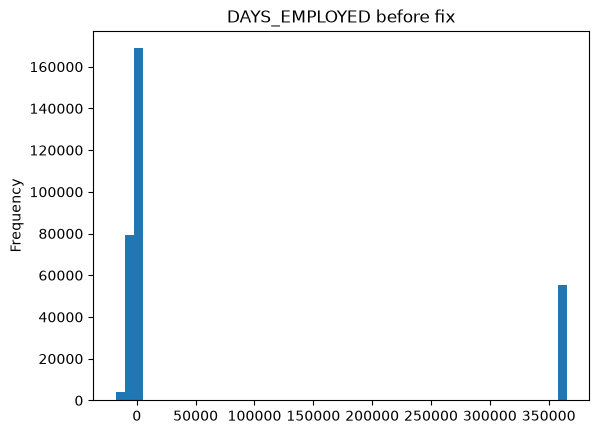

In [26]:
print("DAYS_EMPLOYED anomaly count:", (train['DAYS_EMPLOYED'] == 365243).sum())
print("As % of rows:", round((train['DAYS_EMPLOYED'] == 365243).mean()*100, 2))

# Before fixing, distribution is bimodal/broken:
train['DAYS_EMPLOYED'].plot(kind='hist', bins=50, title='DAYS_EMPLOYED before fix')

DAYS_EMPLOYED is supposed to tell you how many days ago someone started their current job. But Home Credit uses a strange trick: for people who aren't currently employed, instead of leaving this blank, they put in the number 365243 - which works out to roughly 1,000 years. That's obviously not a real answer, it's just a placeholder meaning "not applicable."

This code checks how big of a problem that placeholder actually is in your data:

- It counts exactly how many rows have that fake 365243 value.
- It turns that count into a percentage, so you know how much of your dataset is affected (a few rows would barely matter, but if it's a big chunk, it needs fixing).
- It draws a histogram (a bar chart showing how values are spread out) of DAYS_EMPLOYED as-is. 

Since real values are all fairly small numbers (days someone has worked, so ranging maybe from 0 up to a few thousand) and the fake value is enormous by comparison (365,243), the chart ends up looking broken - as shown  a normal-looking cluster of real values, plus a weird separate spike way off to the side for everyone with the placeholder.

-  That visual is the "before" picture, so later (when the column is fixed  by replacing 365243 with a proper blank value) you can compare it to an "after" picture and see the difference clearly.

#### Fixing the anomaly

In [29]:
def clean(df, days_employed_median=None):
    df = df.copy()

    # Fix DAYS_EMPLOYED anomaly: flag it, then set to NaN
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype('int8')
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # Impute the now-NaN DAYS_EMPLOYED using the median passed in
    # (computed from train's real values only — see below)
    if days_employed_median is not None:
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(days_employed_median)

    # Replace infinities (from ratio features) with NaN — can appear after
    # feature engineering (e.g. division by zero when creating ratio features)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

    return df

# Compute the median from TRAIN's real (non-anomalous) values only,
# BEFORE calling clean() on either dataset
days_employed_median = train.loc[train['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'].median()

# Clean both datasets using the SAME median (computed from train only)
train = clean(train, days_employed_median)
test = clean(test, days_employed_median)

print("Remaining NaNs in DAYS_EMPLOYED (train):", train['DAYS_EMPLOYED'].isnull().sum())
print("Remaining NaNs in DAYS_EMPLOYED (test):", test['DAYS_EMPLOYED'].isnull().sum())

Remaining NaNs in DAYS_EMPLOYED (train): 0
Remaining NaNs in DAYS_EMPLOYED (test): 0


### 5. Separating Numerical and Categorical Columns

In [30]:
 # Get the list of all columns that hold numbers 
numeric_cols = train.select_dtypes(include=[np.number]).columns

# For every numeric column, check each value: is it infinity (inf or -inf)?
# Then count how many infinite values each column has
inf_counts = np.isinf(train[numeric_cols]).sum()

# Keep only the columns that actually have at least 1 infinite value
inf_cols = inf_counts[inf_counts > 0]

print("Columns with infinite values:")
print(inf_cols)

Columns with infinite values:
Series([], dtype: int64)


In [31]:
# Identifying categorical columns

# or, if pandas 3.0 read them in as the newer string dtype:
# Newer versions of pandas sometimes store text as a "string" dtype instead
# of the older "object" dtype, so this line catches both possibilities —
# whichever one your version of pandas actually used
categorical_cols = train.select_dtypes(include=['object', 'string']).columns

# Show how many numeric columns we found earlier, and how many text columns we just found
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# List out the actual names of the text columns, so we can see exactly which ones they are
print(categorical_cols.tolist())

Numeric columns: 568
Categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


### 6. Outliers Analysis

In a boxplot :

1. The line inside the box represents the median (the middle value).
2. The box represents the middle 50% of the data (from the 25th to the 75th percentile).
3. The whiskers show the range of most normal observations.
4. The small circles (dots) outside the whiskers are outliers-values that are much higher or lower than most observations.

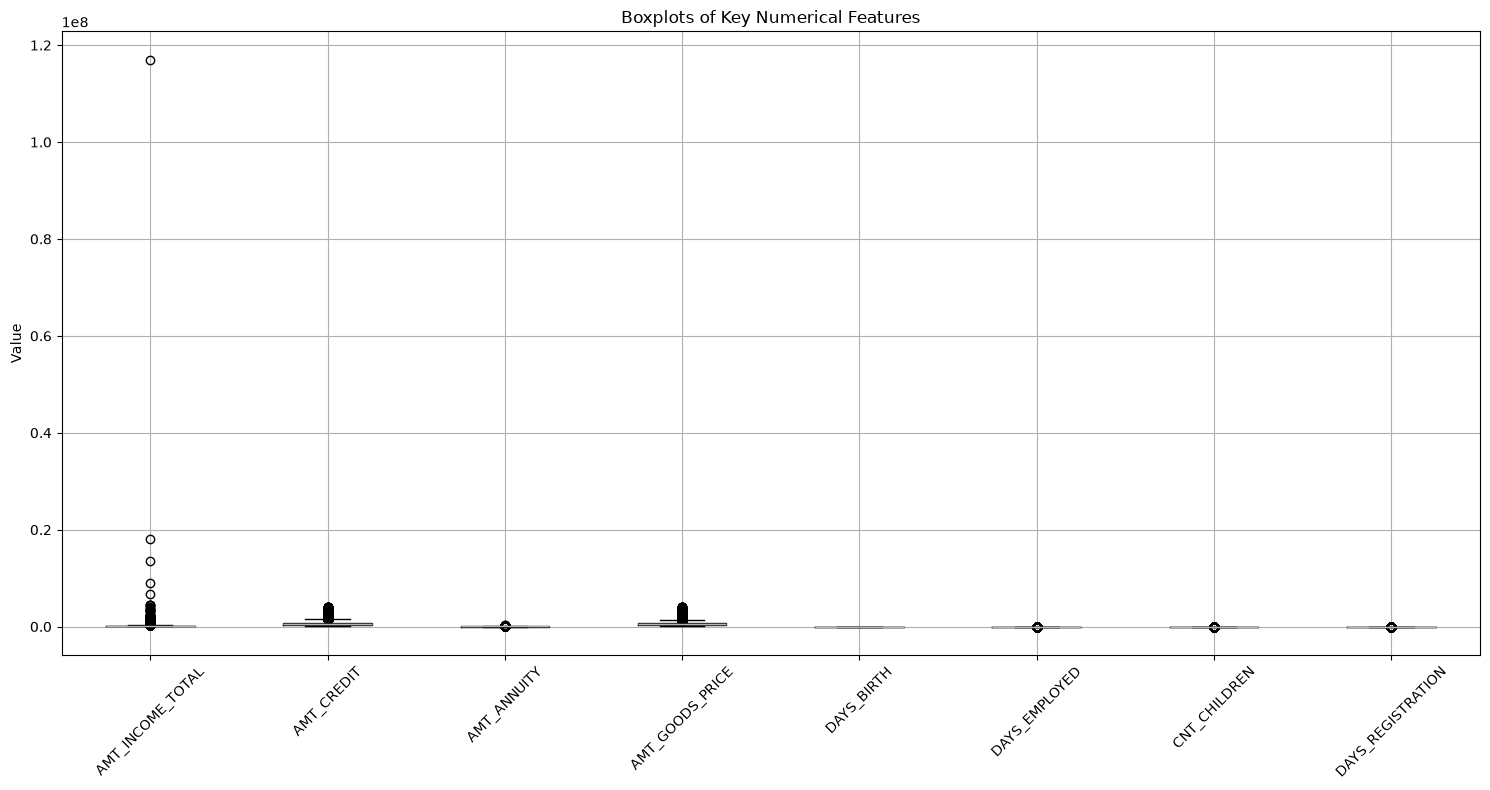

In [32]:

key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'DAYS_REGISTRATION']
key_cols = [c for c in key_cols if c in train.columns]

plt.figure(figsize=(15, 8))
train[key_cols].boxplot(rot=45)
plt.title("Boxplots of Key Numerical Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

Skip visual boxplots for 500 columns and compute outlier counts numerically instead 

The  code below identifies potential outliers in the numerical features of the training dataset using the Interquartile Range (IQR) method. For each numerical column, it calculates the lower and upper limits for normal values, counts how many observations fall outside these limits, and calculates the percentage of outliers. The results are sorted from the highest to the lowest percentage of outliers, helping identify variables with unusually extreme values that may need further investigation or preprocessing before training a machine learning model.

In [33]:
def outlier_summary(df, cols):
    results = []
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        if n_outliers > 0:
            results.append({'column': col, 'n_outliers': n_outliers, 
                             'pct_outliers': round(n_outliers/len(df)*100, 2)})
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = outlier_summary(train, numeric_cols)
outlier_report.head(30)

,column,n_outliers,pct_outliers
66,LIVINGAREA_MEDI,153080,49.78
38,LIVINGAREA_AVG,153089,49.78
52,LIVINGAREA_MODE,152942,49.74
55,APARTMENTS_MEDI,151063,49.12
27,APARTMENTS_AVG,150931,49.08
41,APARTMENTS_MODE,143928,46.80
57,YEARS_BEGINEXPLUATATION_MEDI,142141,46.22
29,YEARS_BEGINEXPLUATATION_AVG,142016,46.18
69,TOTALAREA_MODE,141917,46.15
43,YEARS_BEGINEXPLUATATION_MODE,141861,46.13


Outlier detection was performed using the Interquartile Range (IQR) method. Several housing-related variables, including LIVINGAREA_AVG, LIVINGAREA_MEDI, APARTMENTS_AVG, and TOTALAREA_MODE, showed a high proportion of observations outside the IQR boundaries, with some variables exceeding 40% of the dataset. Because missing values had already been handled using median imputation and missing-value indicator variables, these results indicate that the variables are inherently highly skewed rather than containing widespread data errors. The detected outliers were therefore retained, as they likely represent genuine variation in applicants' housing characteristics. Removing them would have resulted in substantial information loss and could negatively affect model performance.

### 7. Correlation Analysis

A full correlation matrix - all numeric columns against each other with a 500+ numeric columns,  the grid will be 500x500 which is  unreadable as a heatmap and slow to compute. 

Therefore, below are two more practical versions for a dataset this wide:

1. Heatmap of just a manageable subset (e.g. the original raw features):

A correlation matrix shows the strength and direction of the linear relationship between the selected numerical features and the target variable. Correlation values range from -1 to +1, where:

* +1 = Perfect positive relationship (both variables increase together)
* -1 = Perfect negative relationship (one increases while the other decreases)
* 0 = No linear relationship

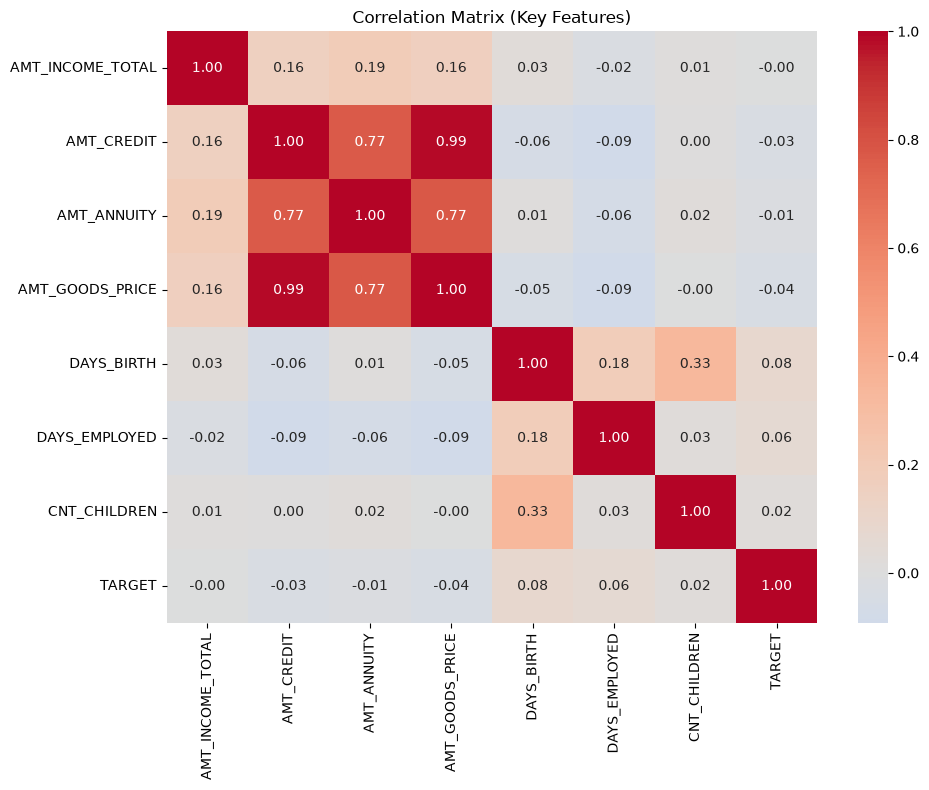

In [34]:


key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'TARGET']
key_cols = [c for c in key_cols if c in train.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(train[key_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Key Features)')
plt.tight_layout()
plt.show()

The correlation analysis revealed a very strong positive relationship between AMT_CREDIT and AMT_GOODS_PRICE (r = 0.99), indicating that applicants requesting larger loans generally purchase higher-priced goods. AMT_CREDIT was also strongly correlated with AMT_ANNUITY (r = 0.77), reflecting the relationship between loan amount and repayment obligations. Most variables exhibited weak correlations with the target variable, suggesting that loan default is determined by multiple interacting factors rather than any single feature.

2. Find highly correlated feature pairs across the full set 

In [35]:
corr_matrix = train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
    .query('correlation > 0.9')
    .sort_values('correlation', ascending=False)
)
print(f"Found {len(high_corr_pairs)} feature pairs with correlation > 0.9")
high_corr_pairs.head(30)

Found 263 feature pairs with correlation > 0.9


,feature_1,feature_2,correlation
321486,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_WAS_MISSING,CC_CNT_DRAWINGS_POS_CURRENT_MAX_WAS_MISSING,1.000000
320918,CC_CNT_DRAWINGS_ATM_CURRENT_MAX_WAS_MISSING,CC_CNT_DRAWINGS_POS_CURRENT_MAX_WAS_MISSING,1.000000
320917,CC_CNT_DRAWINGS_ATM_CURRENT_MAX_WAS_MISSING,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN_WAS_MISSING,1.000000
318072,PREV_DAYS_FIRST_DRAWING_MIN_WAS_MISSING,PREV_DAYS_FIRST_DRAWING_MEAN_WAS_MISSING,1.000000
315797,PREV_RATE_INTEREST_PRIVILEGED_MAX_WAS_MISSING,PREV_RATE_INTEREST_PRIMARY_MEAN_WAS_MISSING,1.000000
317504,PREV_DAYS_FIRST_DRAWING_MAX_WAS_MISSING,PREV_DAYS_FIRST_DRAWING_MEAN_WAS_MISSING,1.000000
317503,PREV_DAYS_FIRST_DRAWING_MAX_WAS_MISSING,PREV_DAYS_FIRST_DRAWING_MIN_WAS_MISSING,1.000000
316365,PREV_RATE_INTEREST_PRIMARY_MAX_WAS_MISSING,PREV_RATE_INTEREST_PRIMARY_MEAN_WAS_MISSING,1.000000
315229,PREV_RATE_INTEREST_PRIVILEGED_MIN_WAS_MISSING,PREV_RATE_INTEREST_PRIMARY_MEAN_WAS_MISSING,1.000000
315796,PREV_RATE_INTEREST_PRIVILEGED_MAX_WAS_MISSING,PREV_RATE_INTEREST_PRIMARY_MAX_WAS_MISSING,1.000000


The correlation analysis found 263 pairs of features with a correlation greater than 0.90, meaning these features are very similar and contain almost the same information. Most of these highly correlated features were created during feature engineering, especially the minimum, maximum, and mean values, as well as the missing value indicator (_WAS_MISSING) columns. For example, many _WAS_MISSING columns had a perfect correlation because the original variables were missing at the same time. Some financial features, such as CC_AMT_RECIVABLE_MEAN and CC_AMT_TOTAL_RECEIVABLE_MEAN, were also almost identical. This does not indicate a problem with the data; it simply means that some features are repetitive. Depending on the machine learning model used, these repetitive features can be removed to make the dataset simpler and reduce multicollinearity without significantly affecting model performance.

### calculate the Pearson correlation between each numerical feature and the target (TARGET).

In [36]:
corrs = train[numeric_cols].corrwith(train['TARGET']).drop('TARGET').sort_values()

print("Top 15 negative correlations (protective):")
print(corrs.head(15))
print()
print("Top 15 positive correlations (risk factors):")
print(corrs.tail(15))

c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 15 negative correlations (protective):
EXT_SOURCE_2                               -0.160295
EXT_SOURCE_3                               -0.155892
EXT_SOURCE_1                               -0.098887
PREV_CODE_REJECT_REASON_XAP_MEAN           -0.074348
BUREAU_CREDIT_ACTIVE_CLOSED_MEAN           -0.070352
PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN    -0.062983
INSTAL_DAYS_INSTALMENT_STD                 -0.056596
INSTAL_DAYS_ENTRY_PAYMENT_STD              -0.056149
INSTAL_AMT_PAYMENT_RATIO_MIN               -0.047335
DAYS_EMPLOYED_ANOM                         -0.045987
PREV_DAYS_FIRST_DRAWING_MAX_WAS_MISSING    -0.045487
PREV_DAYS_FIRST_DRAWING_MIN_WAS_MISSING    -0.045487
PREV_DAYS_FIRST_DRAWING_MEAN_WAS_MISSING   -0.045487
BUREAU_BB_MONTHS_COUNT_MEAN                -0.043466
AMT_GOODS_PRICE                            -0.039623
dtype: float64

Top 15 positive correlations (risk factors):
CC_CNT_DRAWINGS_CURRENT_MAX                         0.057261
INSTAL_DAYS_INSTALMENT_MIN              

#### Insigts from the Top Negative Correlations (Protective Factors)

| Feature | Correlation | Interpretation |
|---------|------------:|----------------|
| EXT_SOURCE_2 | -0.160 | Applicants with higher external credit scores are less likely to default. This was the strongest protective feature identified. |
| EXT_SOURCE_3 | -0.156 | Higher external credit scores were associated with a lower risk of loan default. |
| EXT_SOURCE_1 | -0.099 | Better external credit history reduced the likelihood of default. |
| PREV_CODE_REJECT_REASON_XAP_MEAN | -0.074 | This previous application feature showed a slight association with lower default risk. |
| BUREAU_CREDIT_ACTIVE_CLOSED_MEAN | -0.070 | Applicants with more closed credit accounts tended to have a slightly lower risk of default. |
| PREV_NAME_CONTRACT_STATUS_APPROVED_MEAN | -0.063 | Applicants with more previously approved loans were slightly less likely to default. |
| AMT_GOODS_PRICE | -0.040 | Applicants purchasing more expensive goods showed a slightly lower risk of default. |

##### Insight from the Top Positive Correlations (Risk Factors)

| Feature | Correlation | Interpretation |
|---------|------------:|----------------|
| BUREAU_DAYS_CREDIT_MEAN | 0.082 | Applicants with higher average values for this bureau credit measure tended to have a slightly higher risk of default. |
| DAYS_BIRTH | 0.078 | This feature showed a very weak positive correlation with default. Since `DAYS_BIRTH` is recorded as negative values, it should be interpreted carefully. |
| REGION_RATING_CLIENT_W_CITY | 0.061 | Applicants living in regions with higher risk ratings had a slightly higher likelihood of default. |
| REGION_RATING_CLIENT | 0.059 | Higher regional risk ratings were associated with a slightly higher risk of default. |
| PREV_NAME_PRODUCT_TYPE_WALK-IN_MEAN | 0.058 | Applicants with more walk-in loan products showed a slightly higher risk of default. |
| INSTAL_DAYS_ENTRY_PAYMENT_MIN | 0.057 | This installment payment feature had a weak positive relationship with default. |
| CC_CNT_DRAWINGS_CURRENT_MAX | 0.057 | Higher credit card drawing activity was associated with a slightly higher risk of default. |

The correlation analysis showed that none of the individual features had a strong linear relationship with the target variable, as all correlation coefficients were relatively small (less than ±0.20). The strongest negative correlations were observed for the external credit score variables (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3), indicating that applicants with better external credit scores were less likely to default on their loans. On the other hand, features such as BUREAU_DAYS_CREDIT_MEAN, REGION_RATING_CLIENT, and CC_CNT_DRAWINGS_CURRENT_MAX showed weak positive correlations, suggesting a slightly higher risk of default. Overall, the results indicate that loan default is influenced by the combined effect of many variables rather than by a single feature. This highlights the importance of using machine learning models that can capture complex relationships among multiple features to accurately predict loan default.

### 8. Numerical columns Distribution

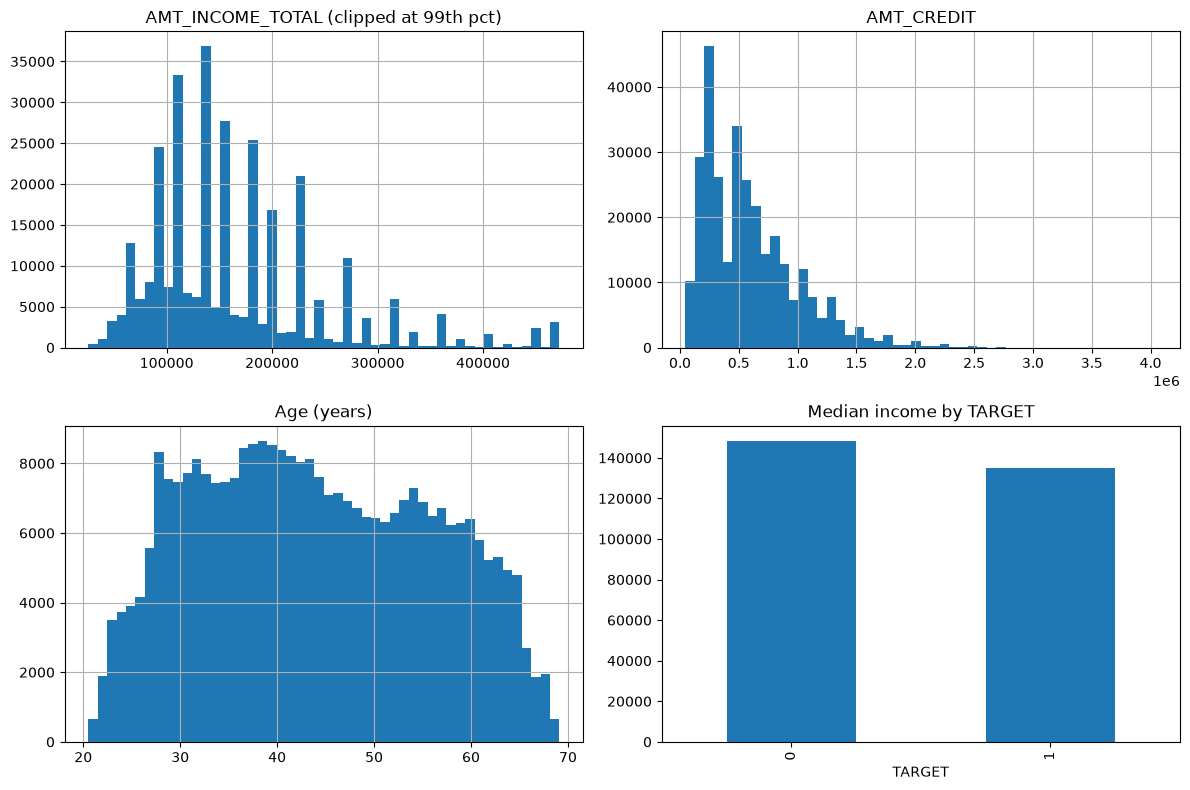

In [37]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(train['AMT_INCOME_TOTAL']).clip(upper=train['AMT_INCOME_TOTAL'].quantile(0.99)).hist(ax=axes[0,0], bins=50)
axes[0,0].set_title('AMT_INCOME_TOTAL (clipped at 99th pct)')

train['AMT_CREDIT'].hist(ax=axes[0,1], bins=50)
axes[0,1].set_title('AMT_CREDIT')

(-train['DAYS_BIRTH']/365).hist(ax=axes[1,0], bins=50)
axes[1,0].set_title('Age (years)')

train.groupby('TARGET')['AMT_INCOME_TOTAL'].median().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Median income by TARGET')
plt.tight_layout()
plt.show()

1. In the AMT_INCOME_TOTAL visualization

The histogram shows the distribution of customers' annual income. The data has been clipped at the 99th percentile, meaning the top 1% of extremely high incomes were excluded from the plot to make the distribution easier to see.

**Therefore,**
1. Most customers earn between 100,000 and 250,000.
2. The distribution is right-skewed, meaning there are many customers with moderate incomes and fewer customers with very high incomes.
3. Even after clipping, a small number of customers still have relatively high incomes.

*Conclusion:*
Most loan applicants have moderate incomes, while only a small proportion earn substantially higher incomes.

2. In the AMT_CREDIT Visualization

The histogram shows the distribution of loan amounts requested.

**Interpretation**
1. Most customers applied for small to medium-sized loans.
2. The distribution is also right-skewed, with fewer customers requesting very large loans.
3. A small number of applicants requested loans exceeding 2 million, creating a long right tail.

*Conclusion:*
The majority of applicants borrow relatively modest amounts, while only a few apply for very large loans.

3. In the Age Visualization

The histogram shows the distribution of applicants' ages.

**Interpretation**
1. Most applicants are between 30 and 60 years old.
2. There are relatively few applicants younger than 25 or older than 65.
3. The distribution is fairly balanced without extreme spikes.

*Conclusion:*
The customer base mainly consists of middle-aged adults, with fewer very young or elderly applicants.

4. In the Median Income by TARGET Visualization

This bar chart compares the median annual income of customers based on the target variable.

TARGET = 0 → Customer repaid the loan successfully.

TARGET = 1 → Customer defaulted on the loan.

**Interpretation**
* Customers who did not default (TARGET = 0) have a higher median income than customers who defaulted.
* Customers who defaulted (TARGET = 1) have a slightly lower median income.

Although the difference is not very large, it suggests that income may have some influence on repayment ability.



Batching through all numeric columns in chunks, e.g. 20 at a time

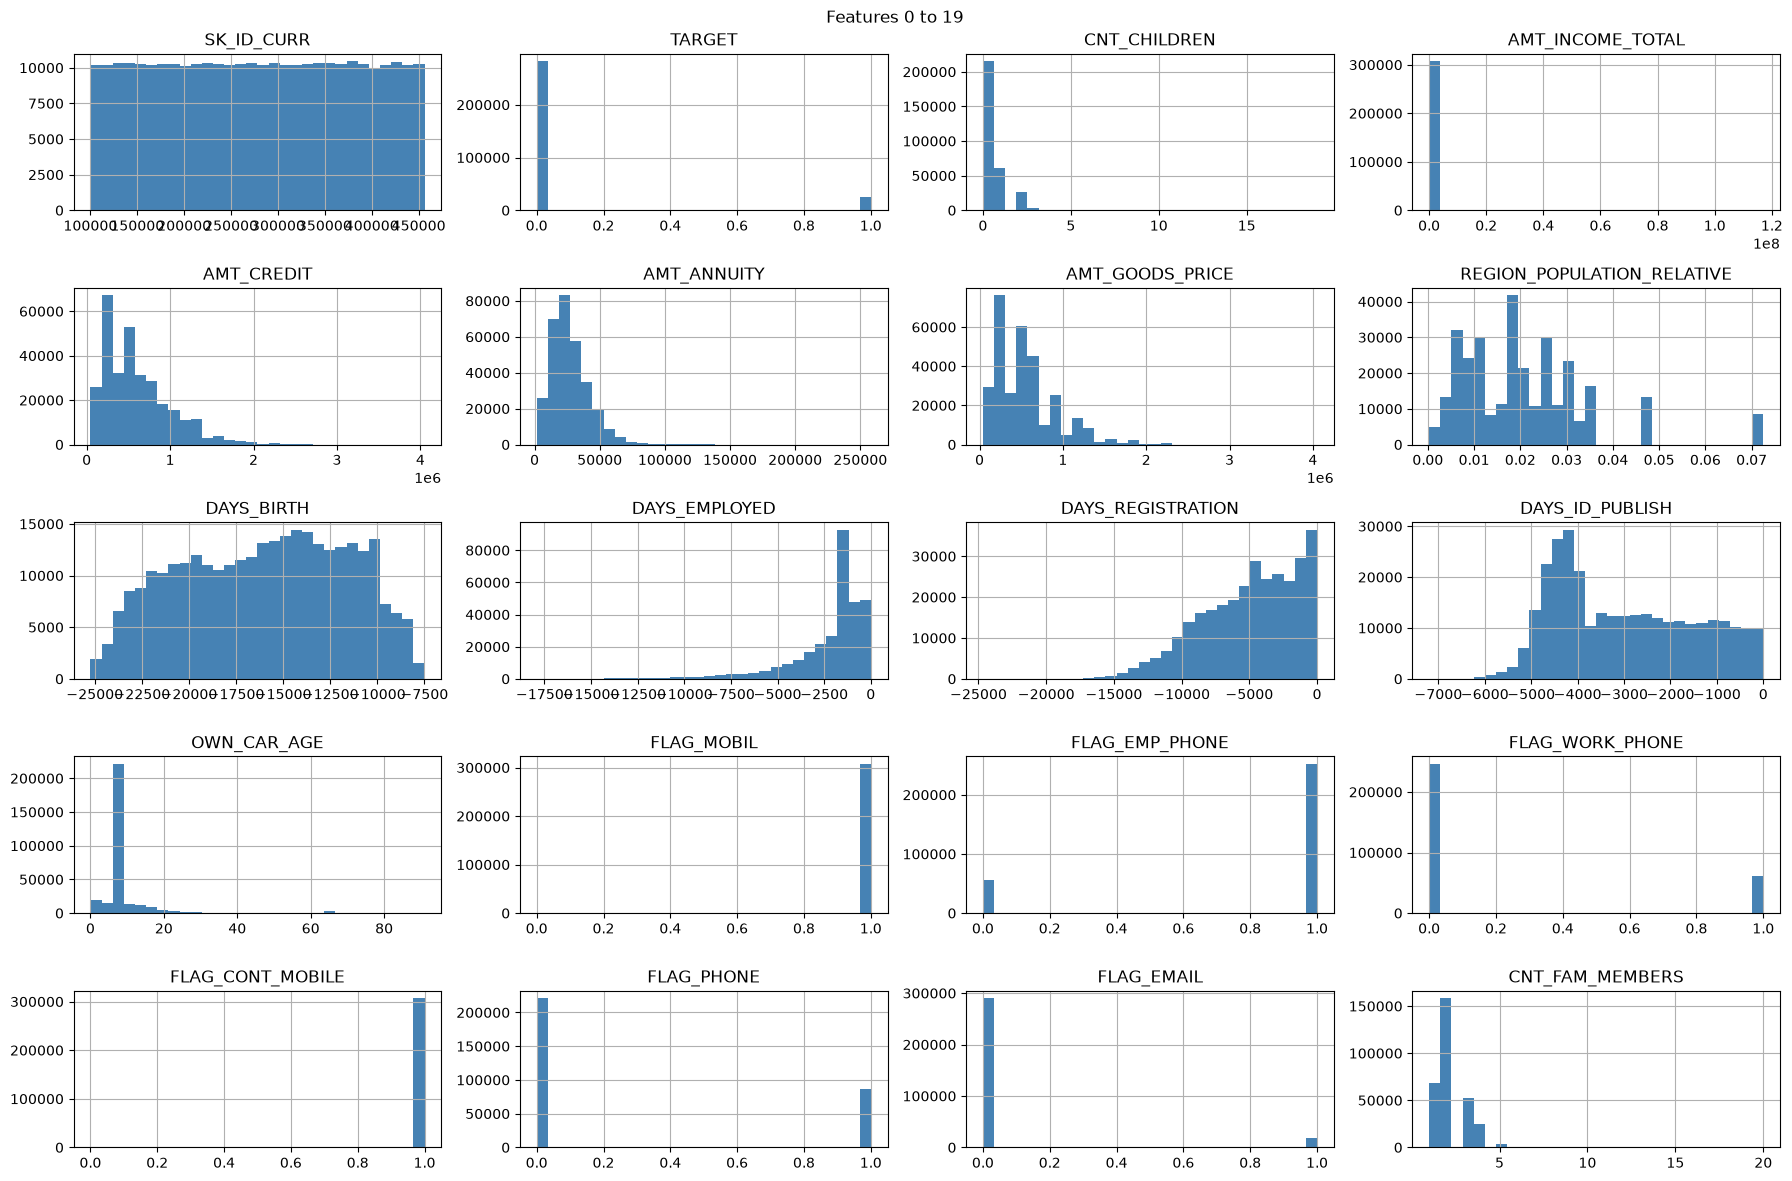

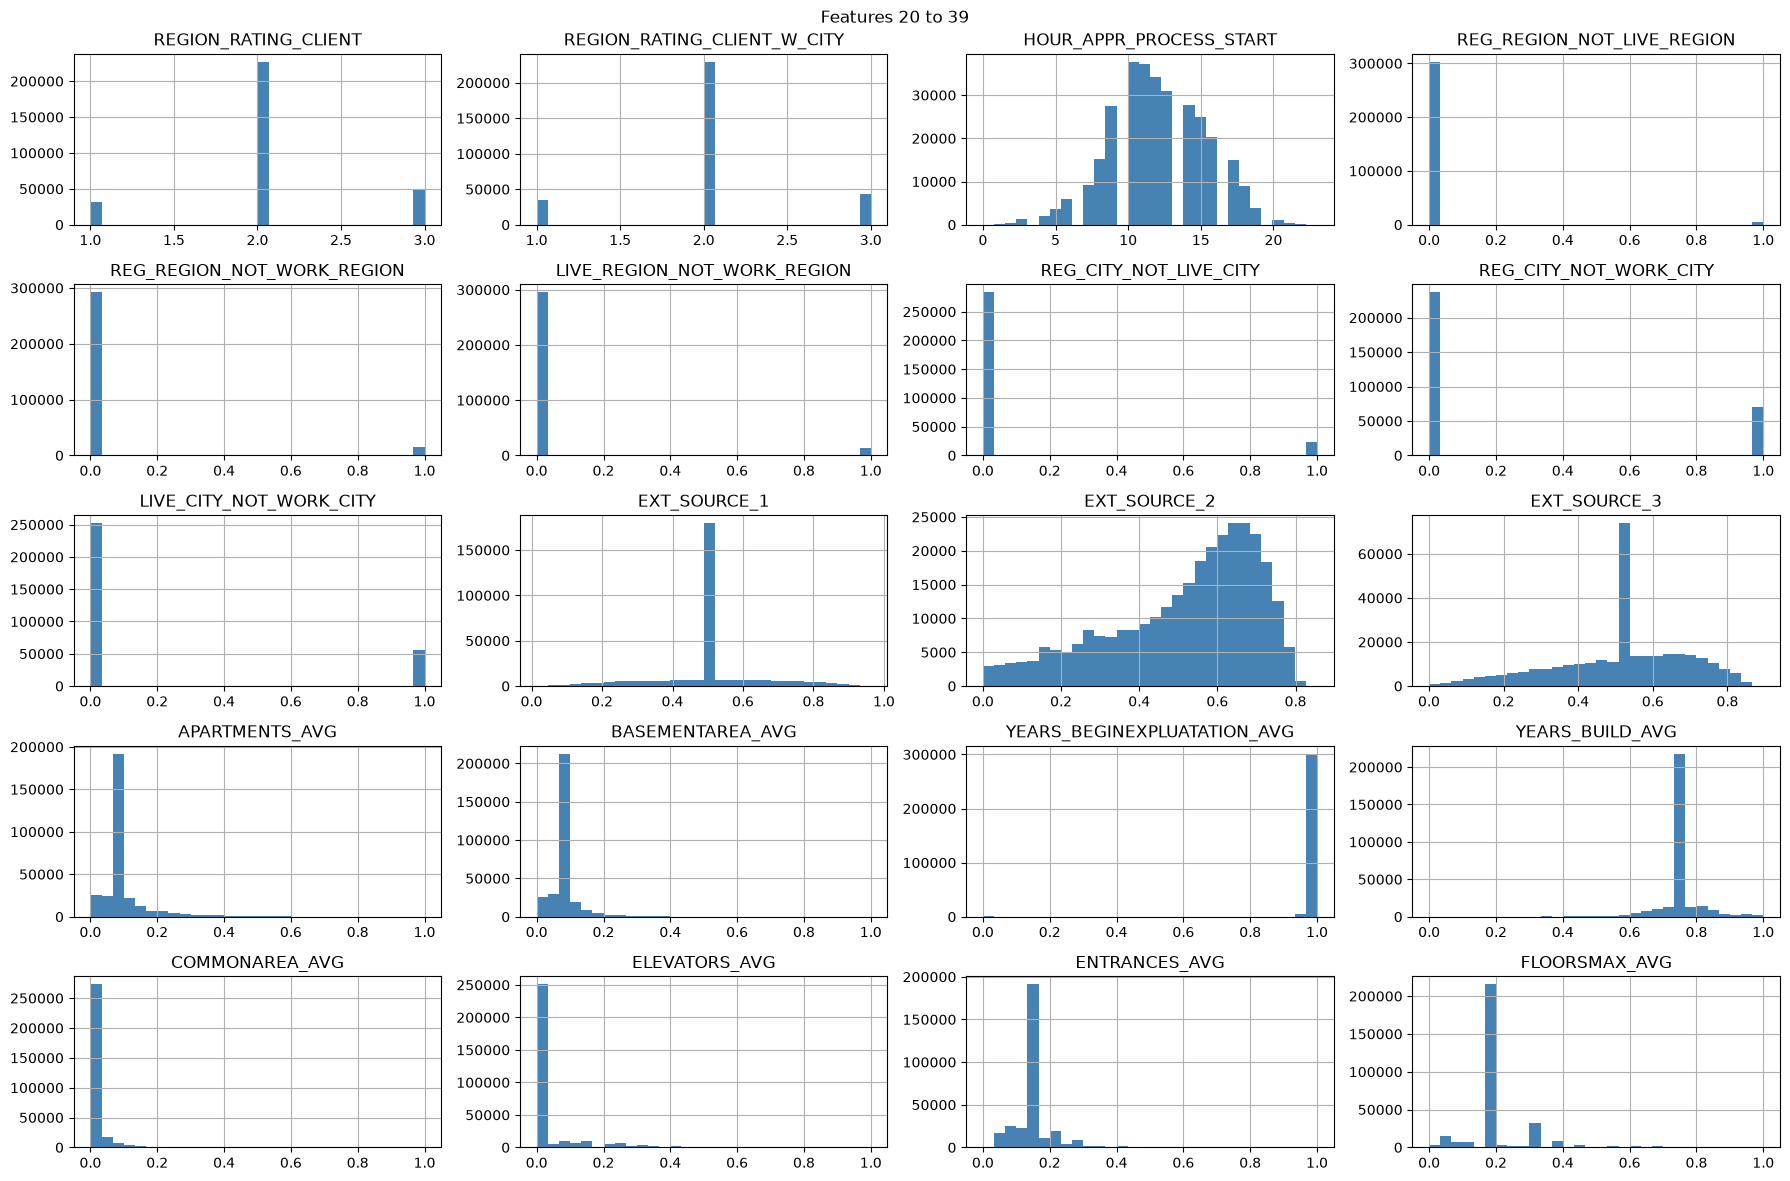

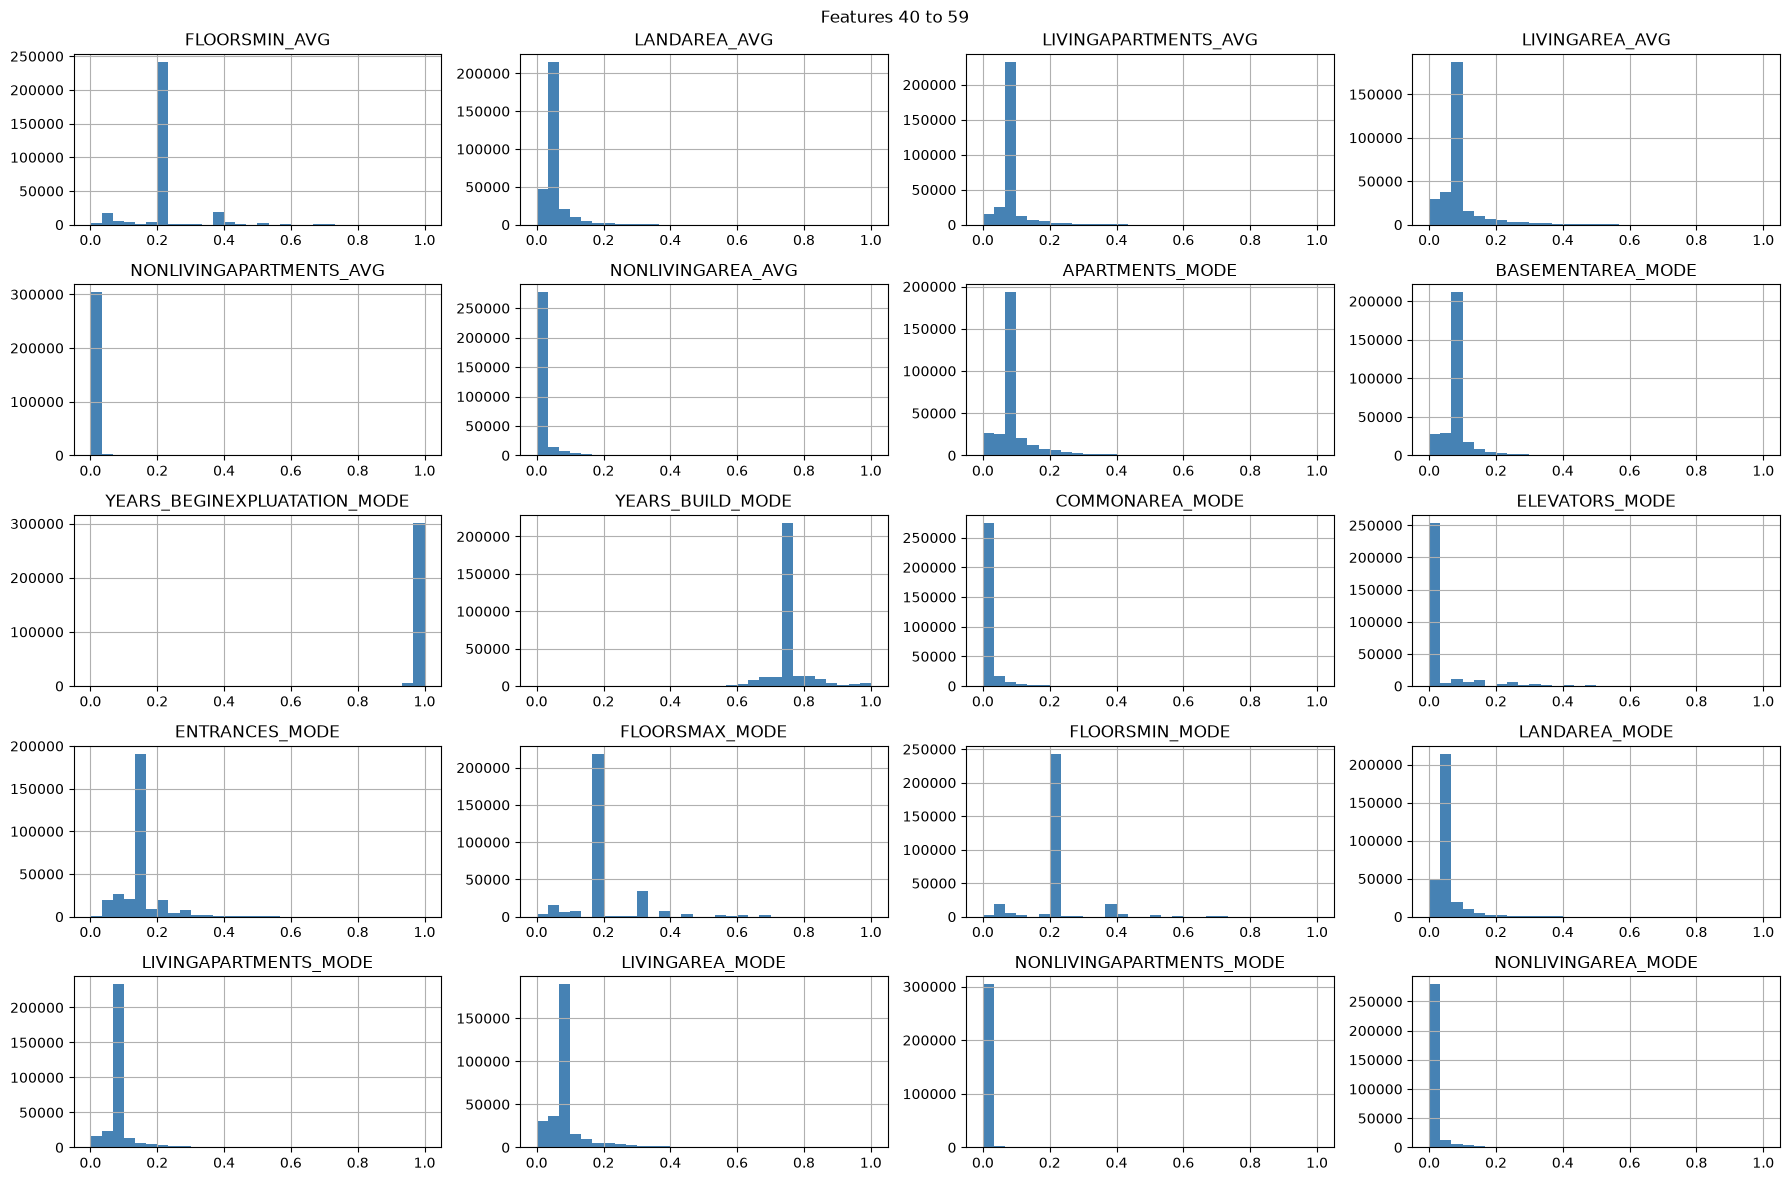

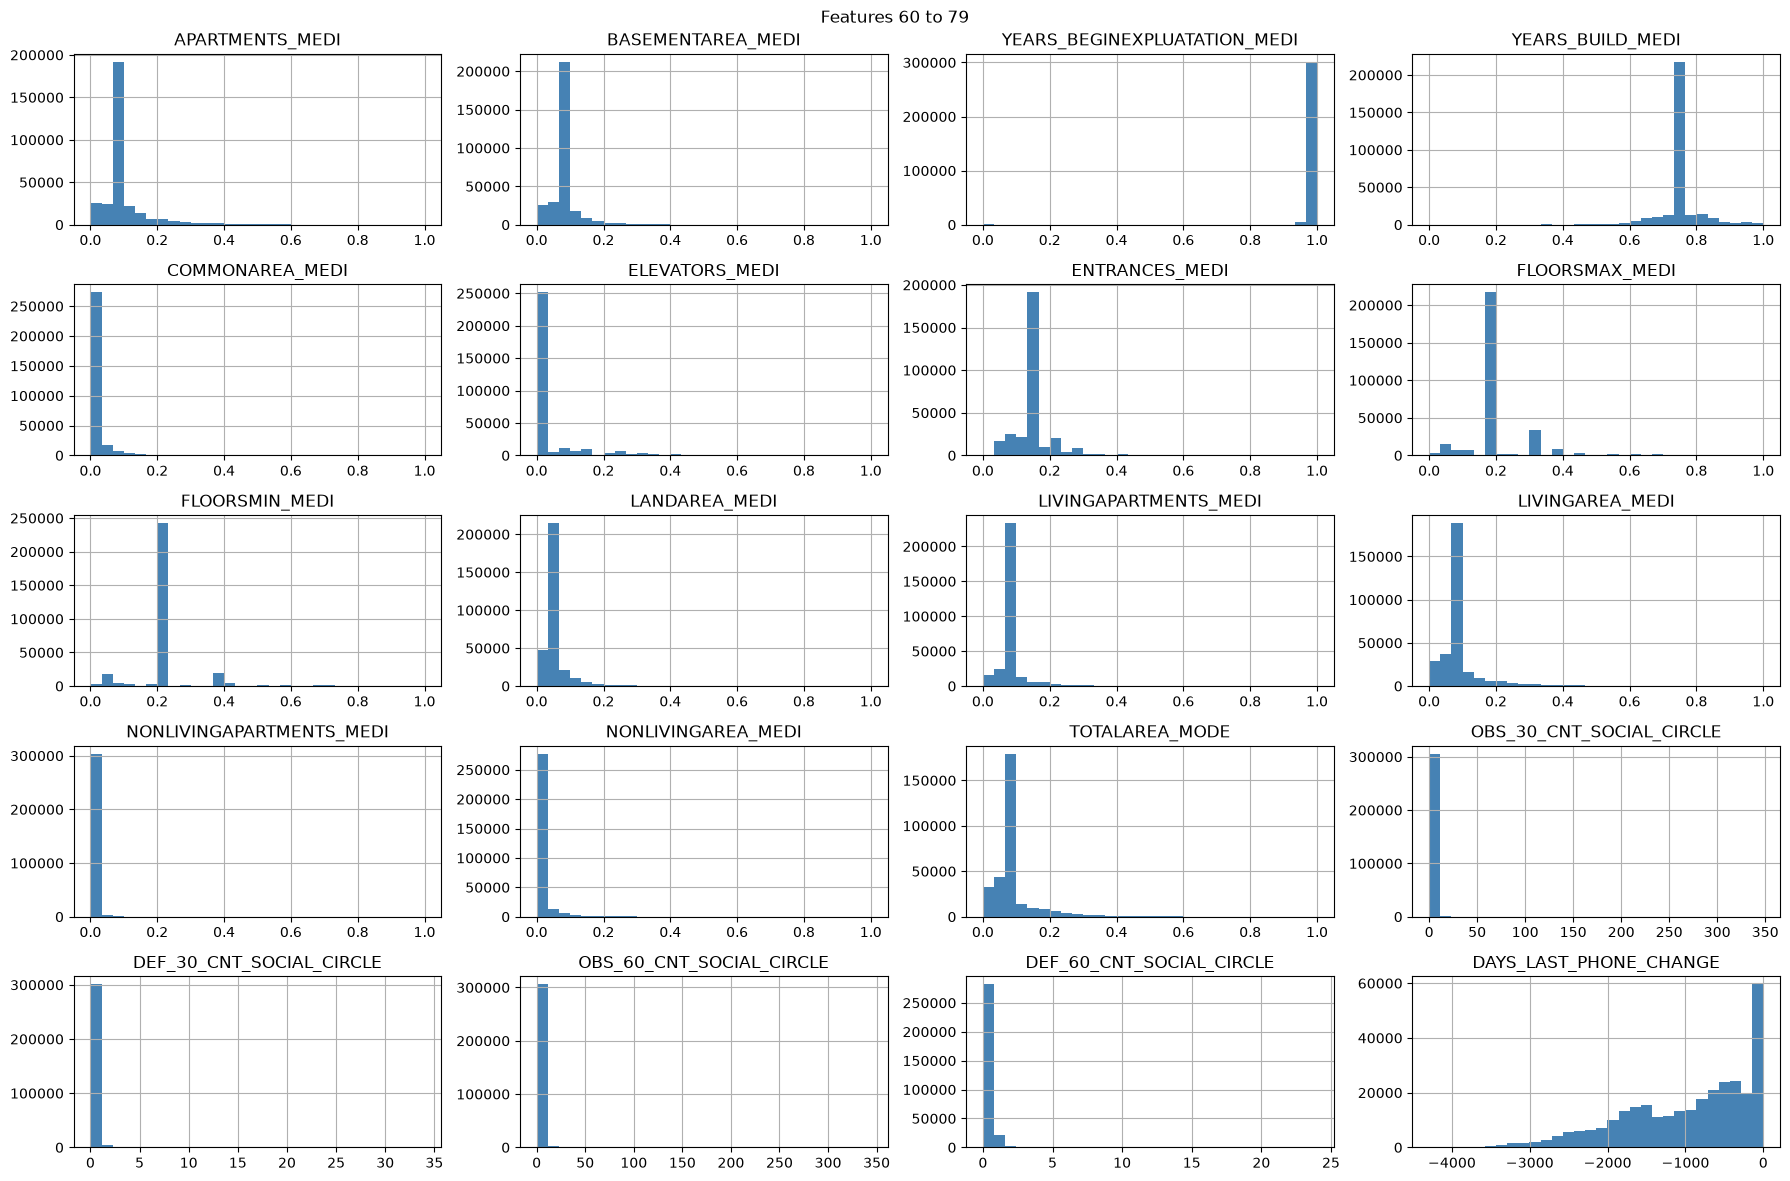

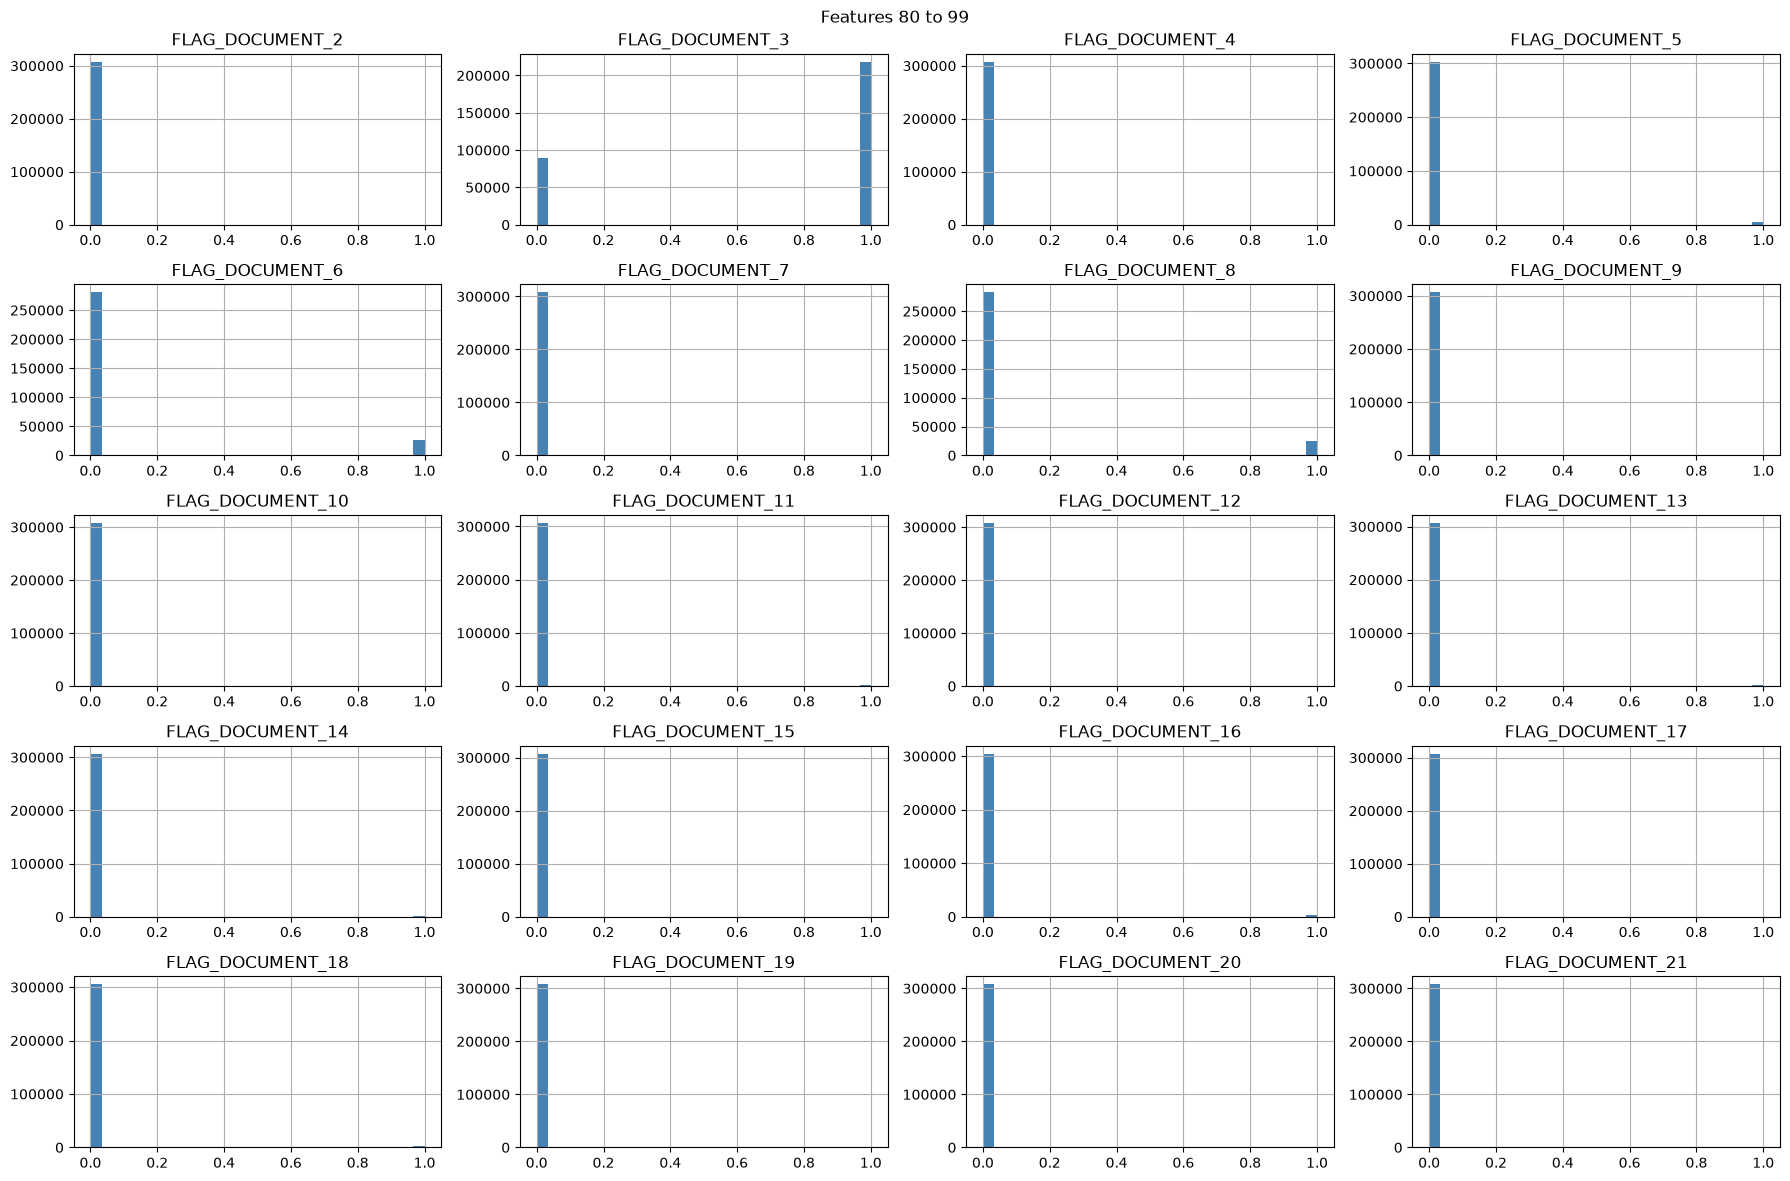

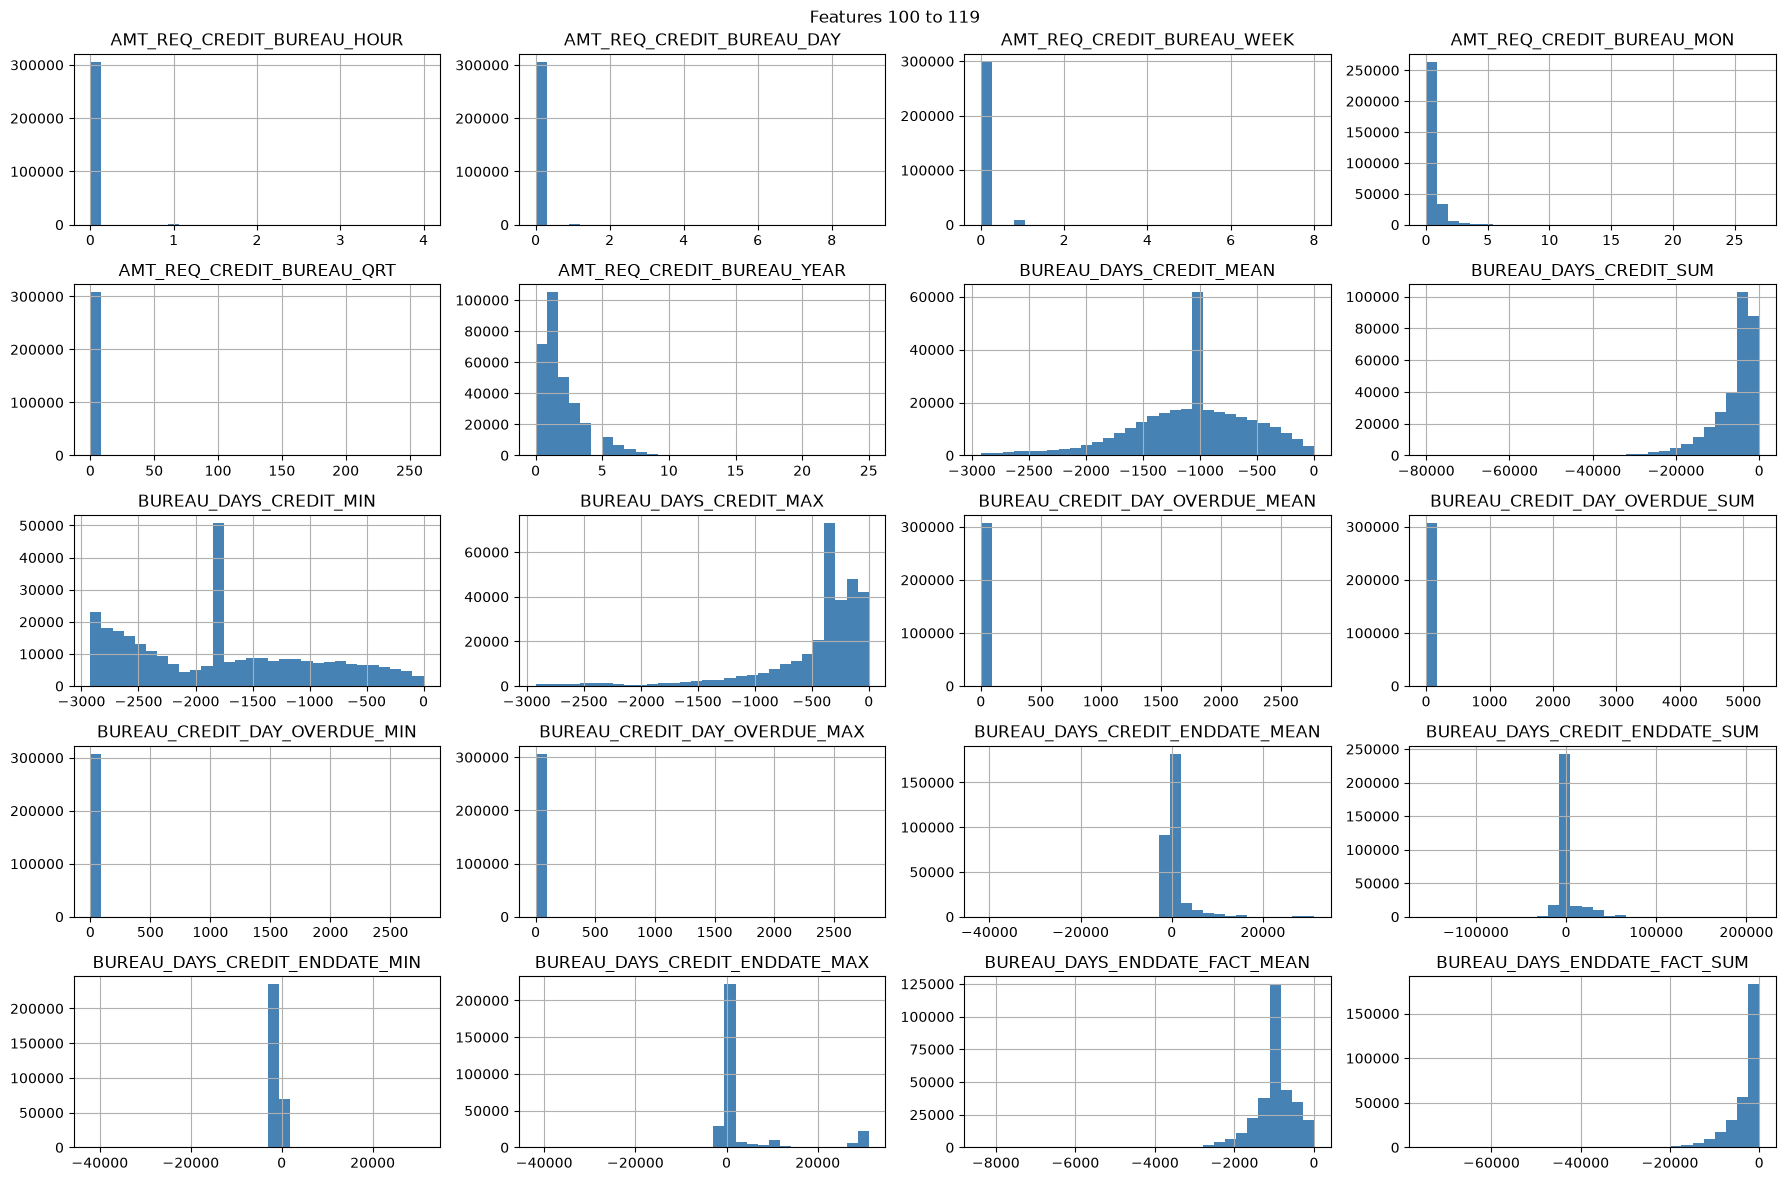

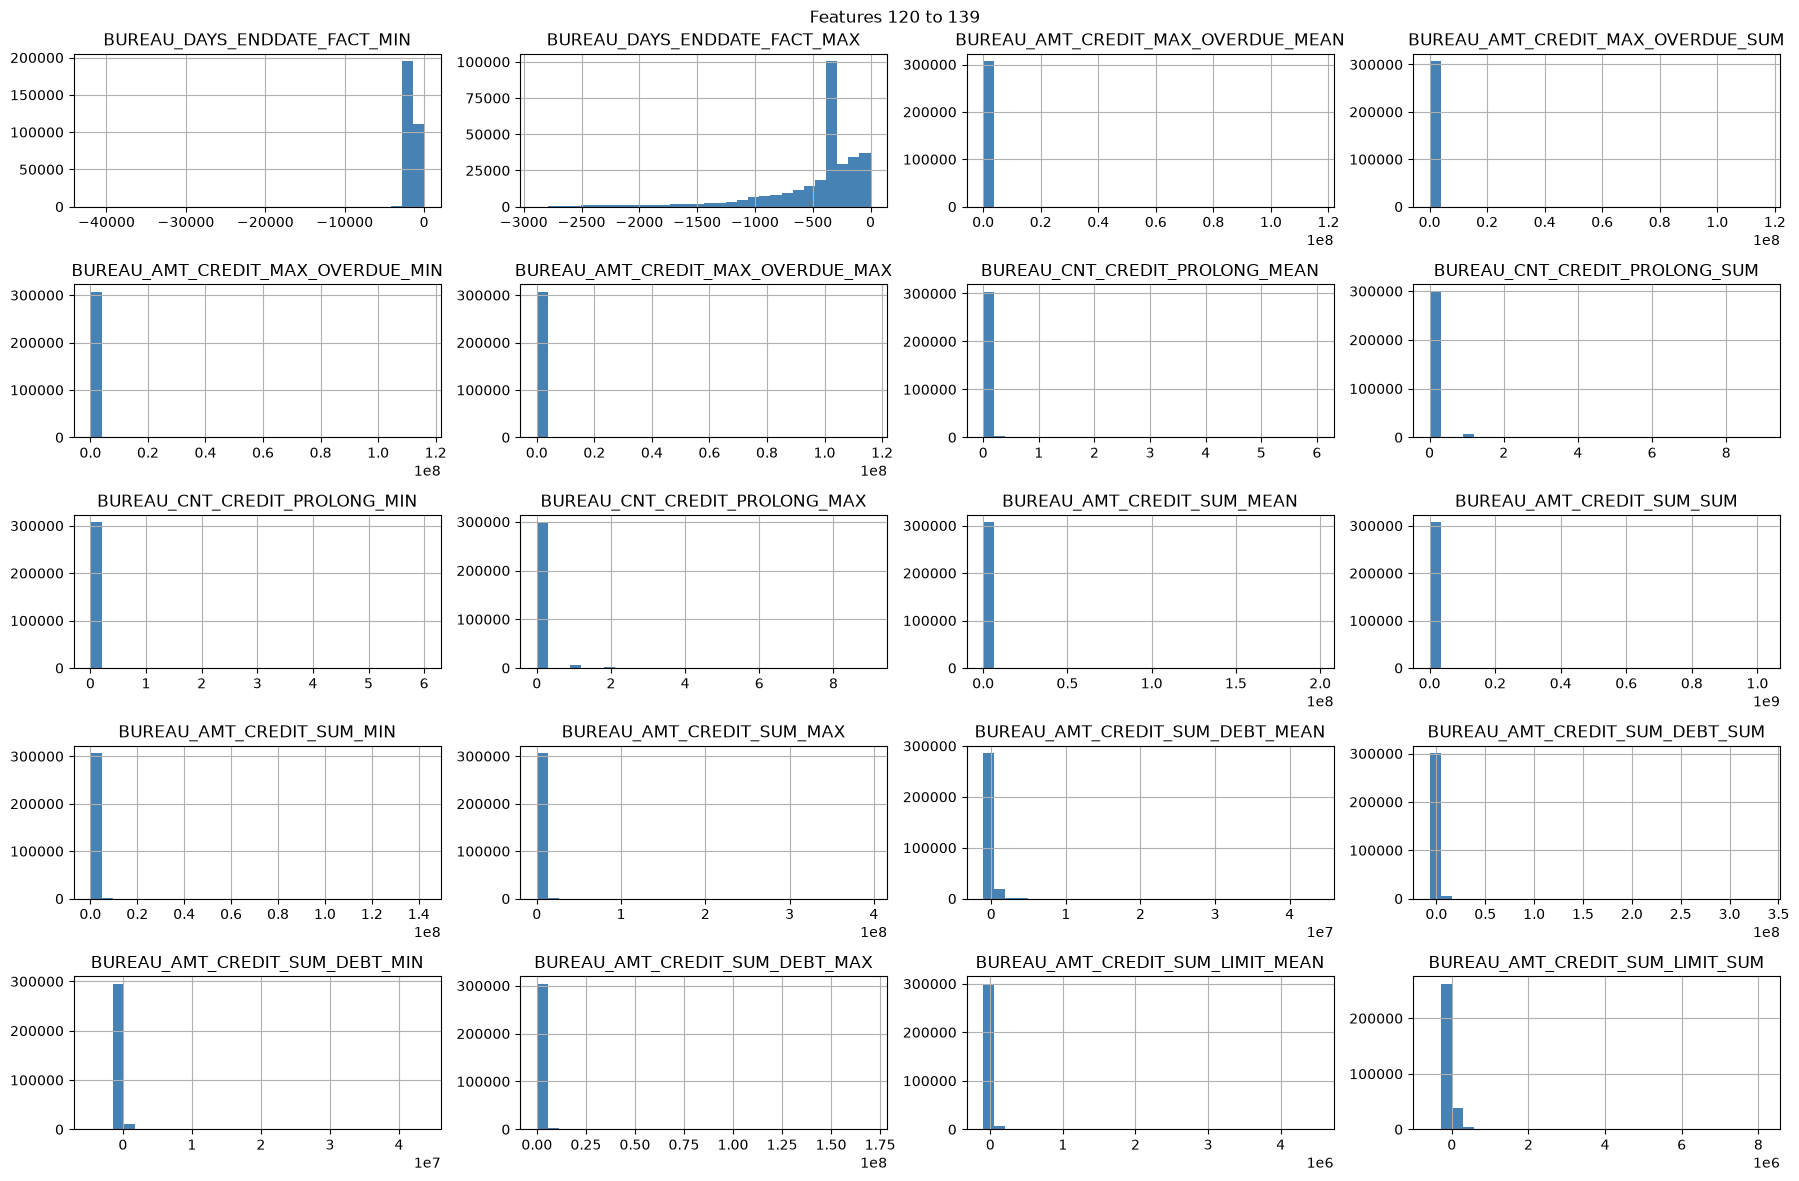

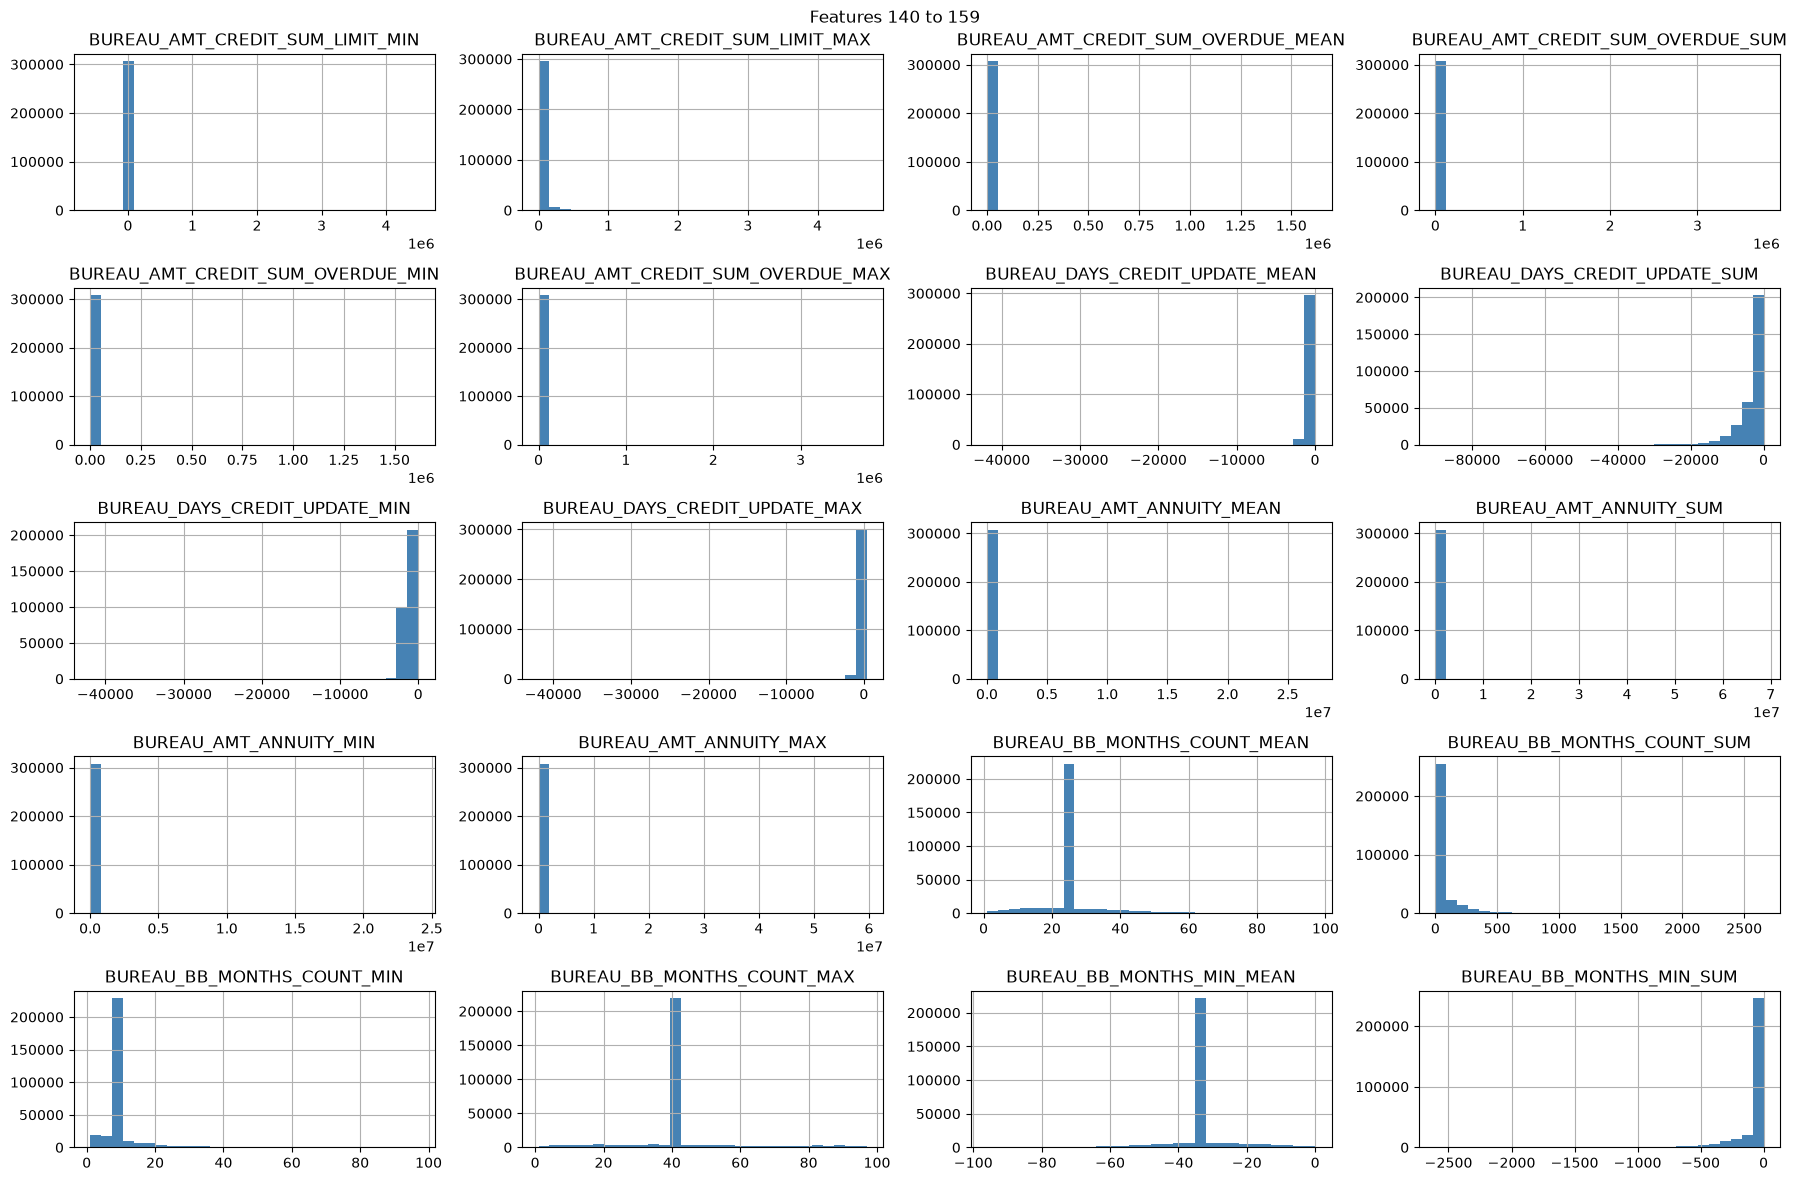

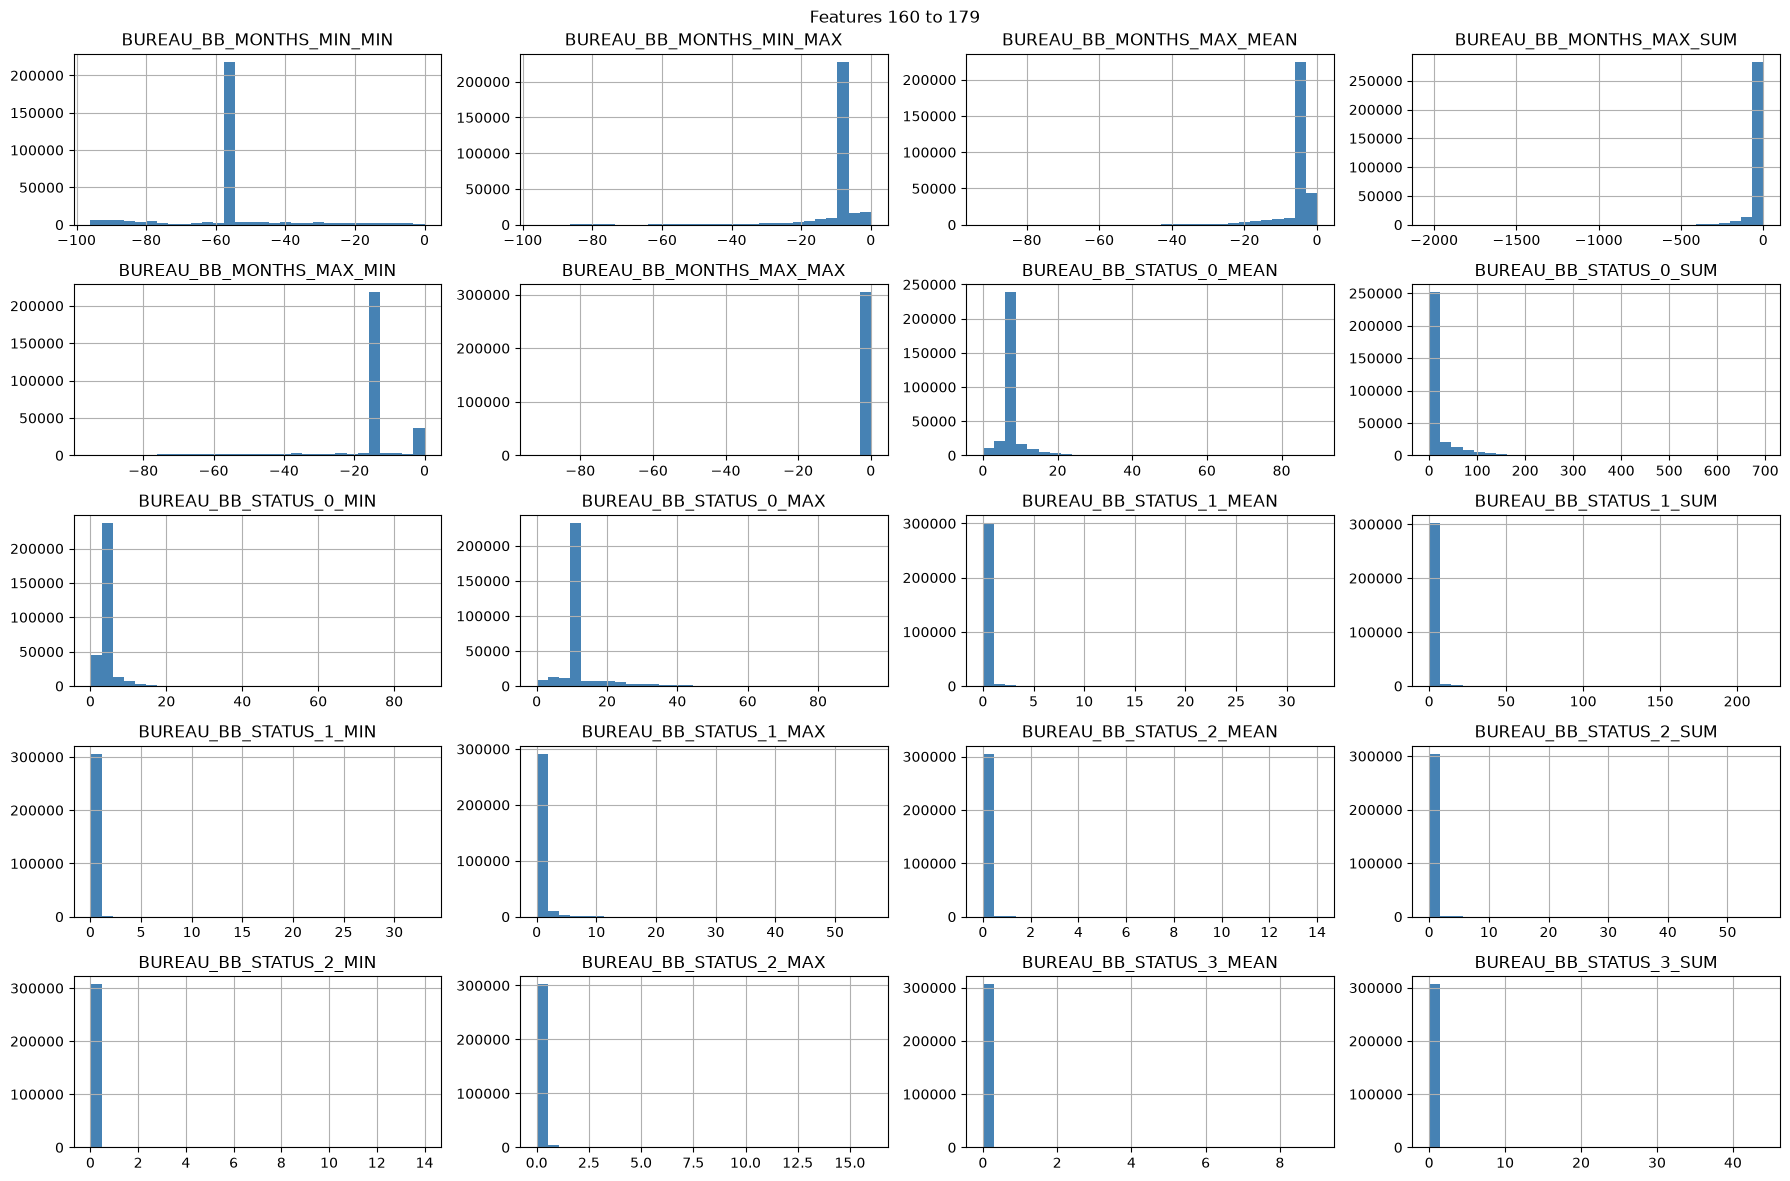

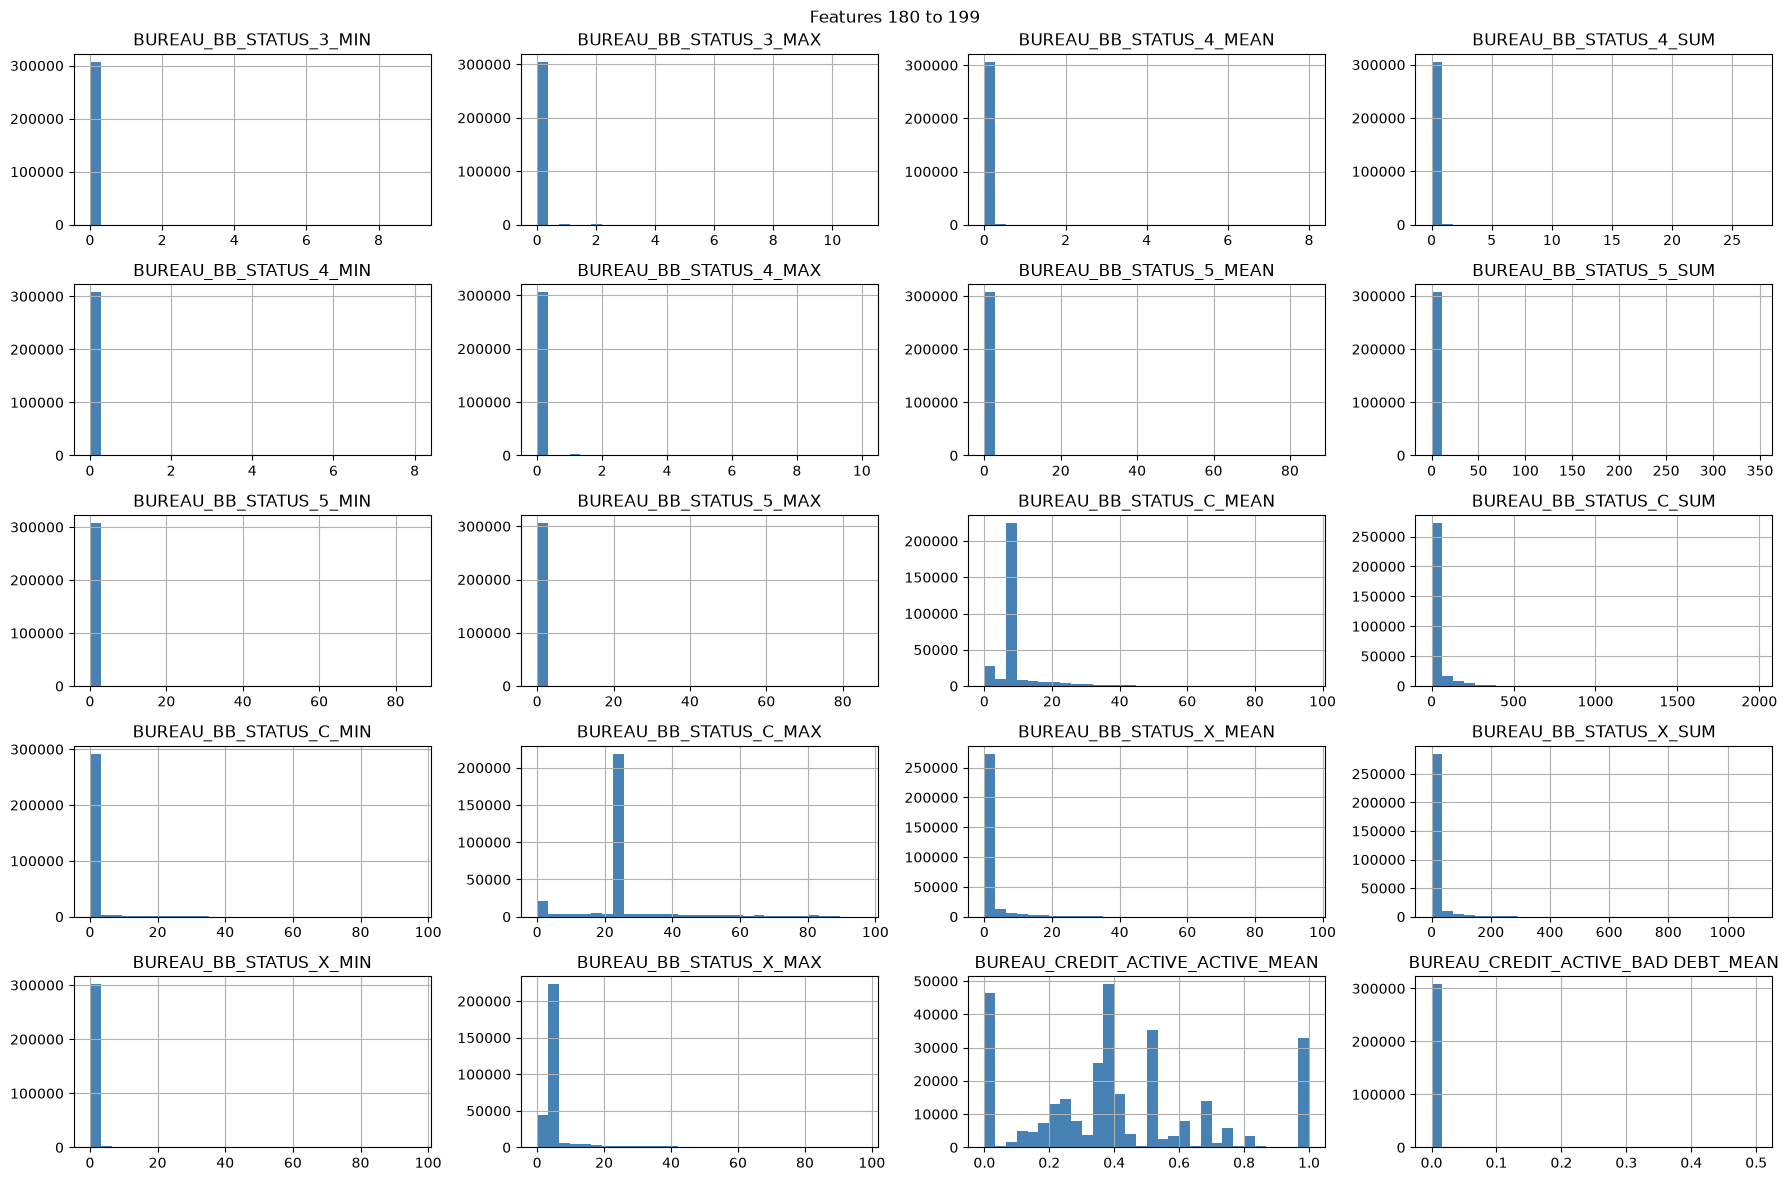

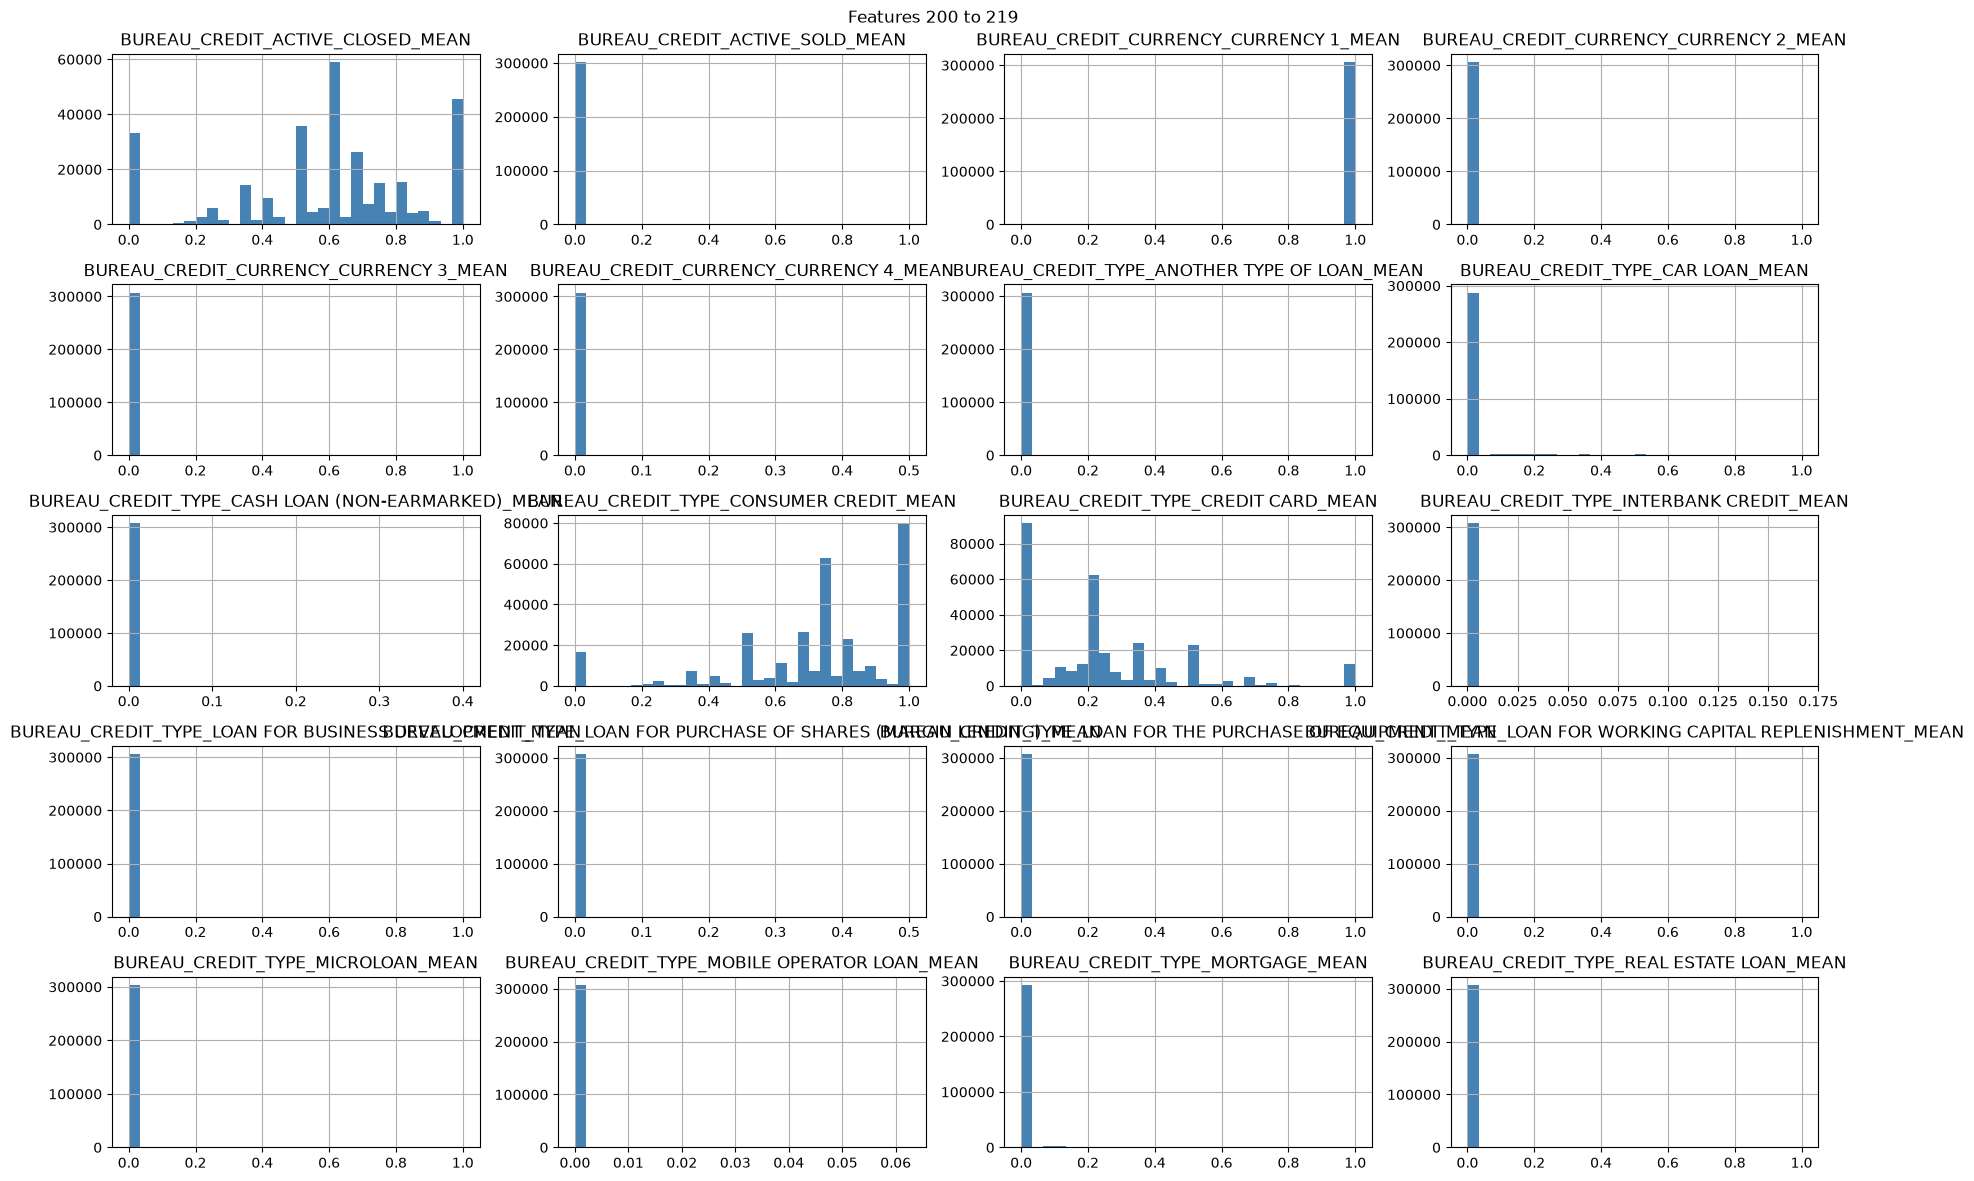

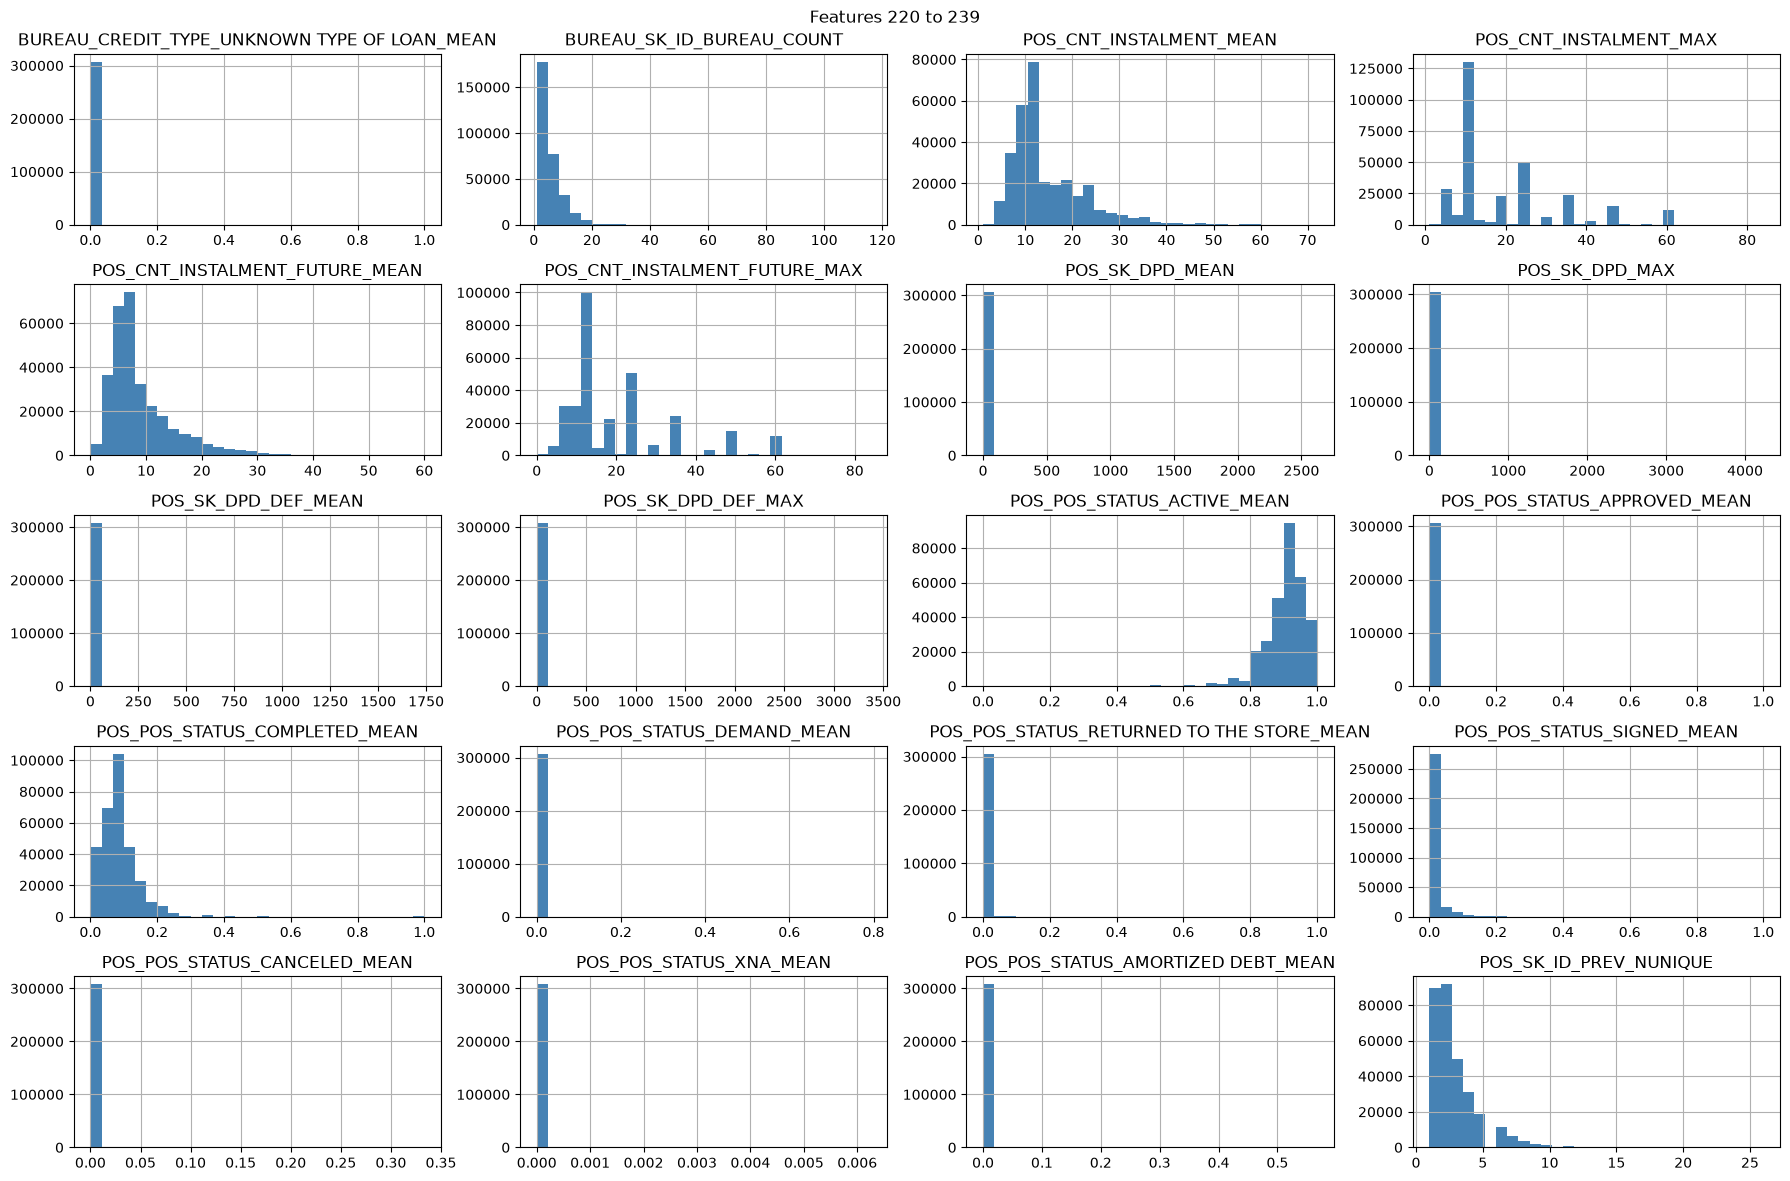

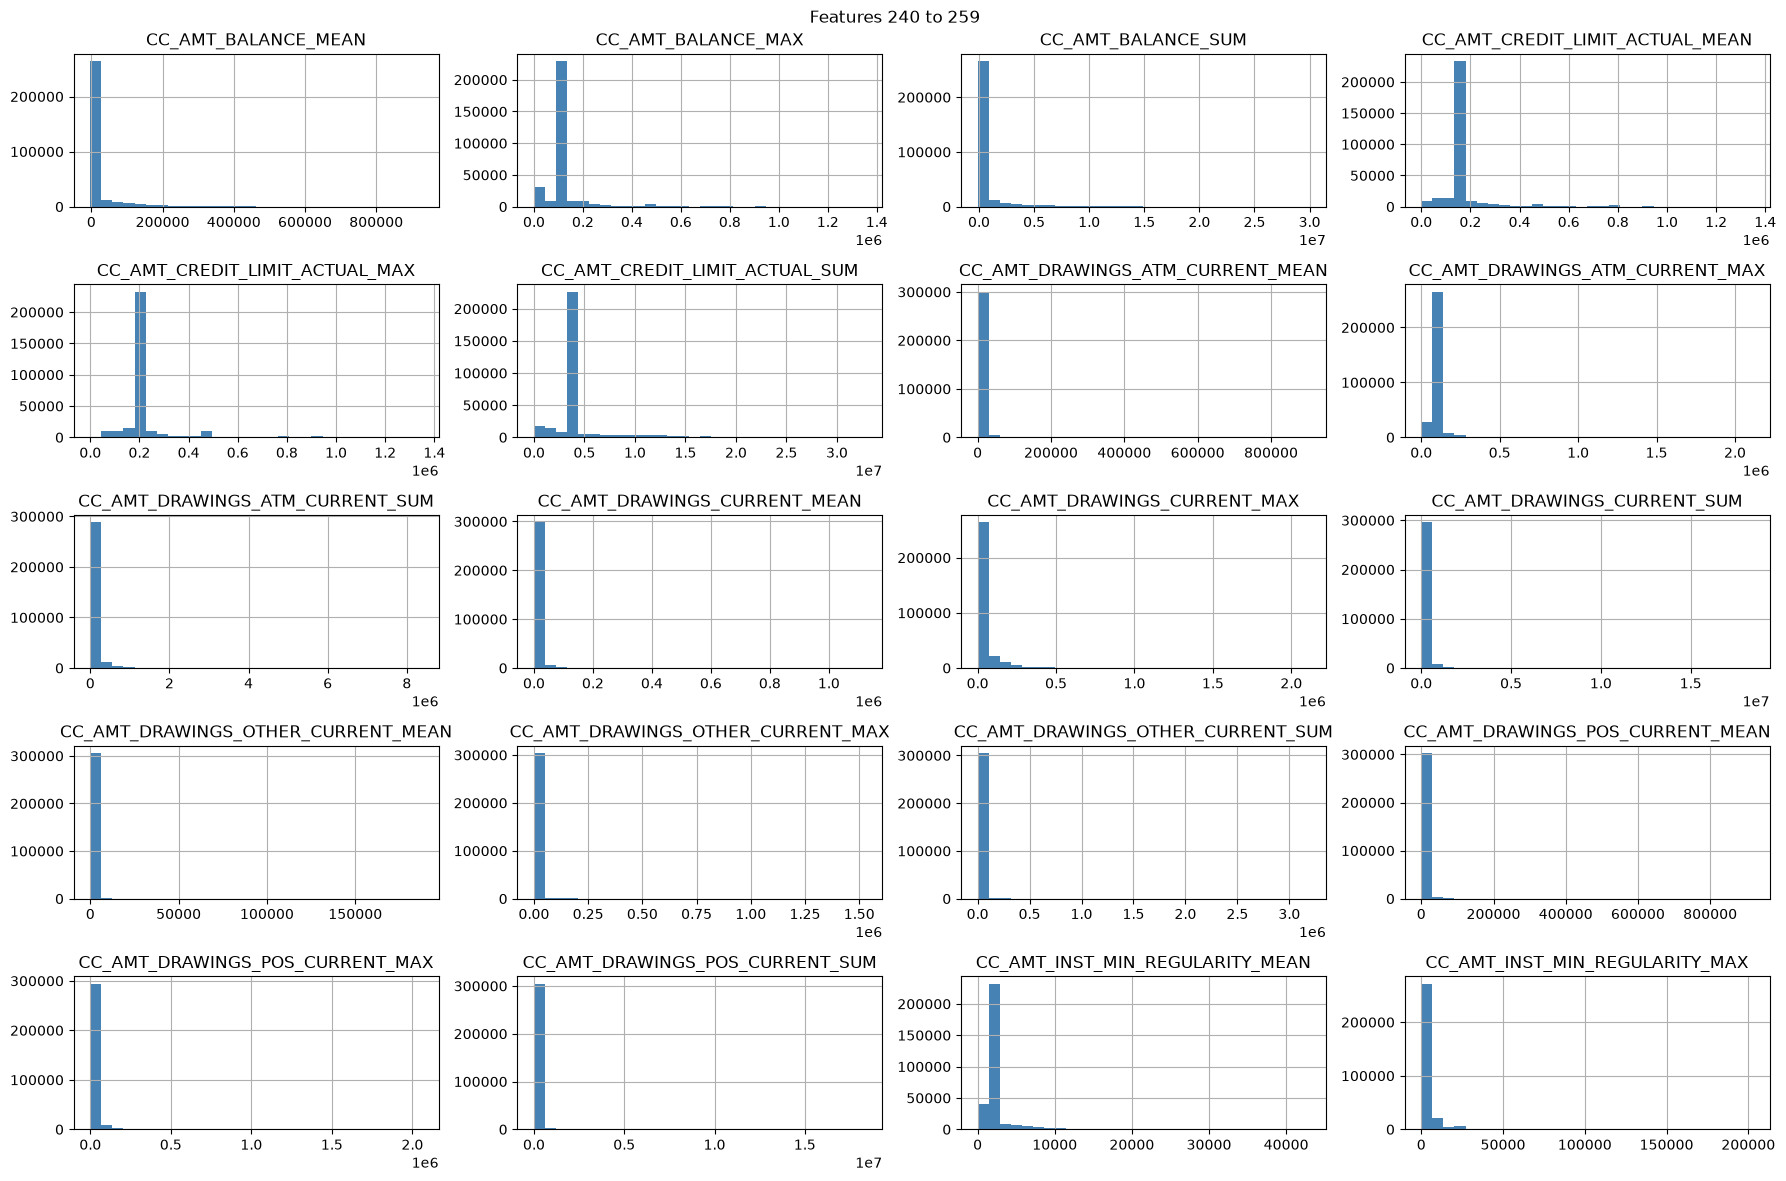

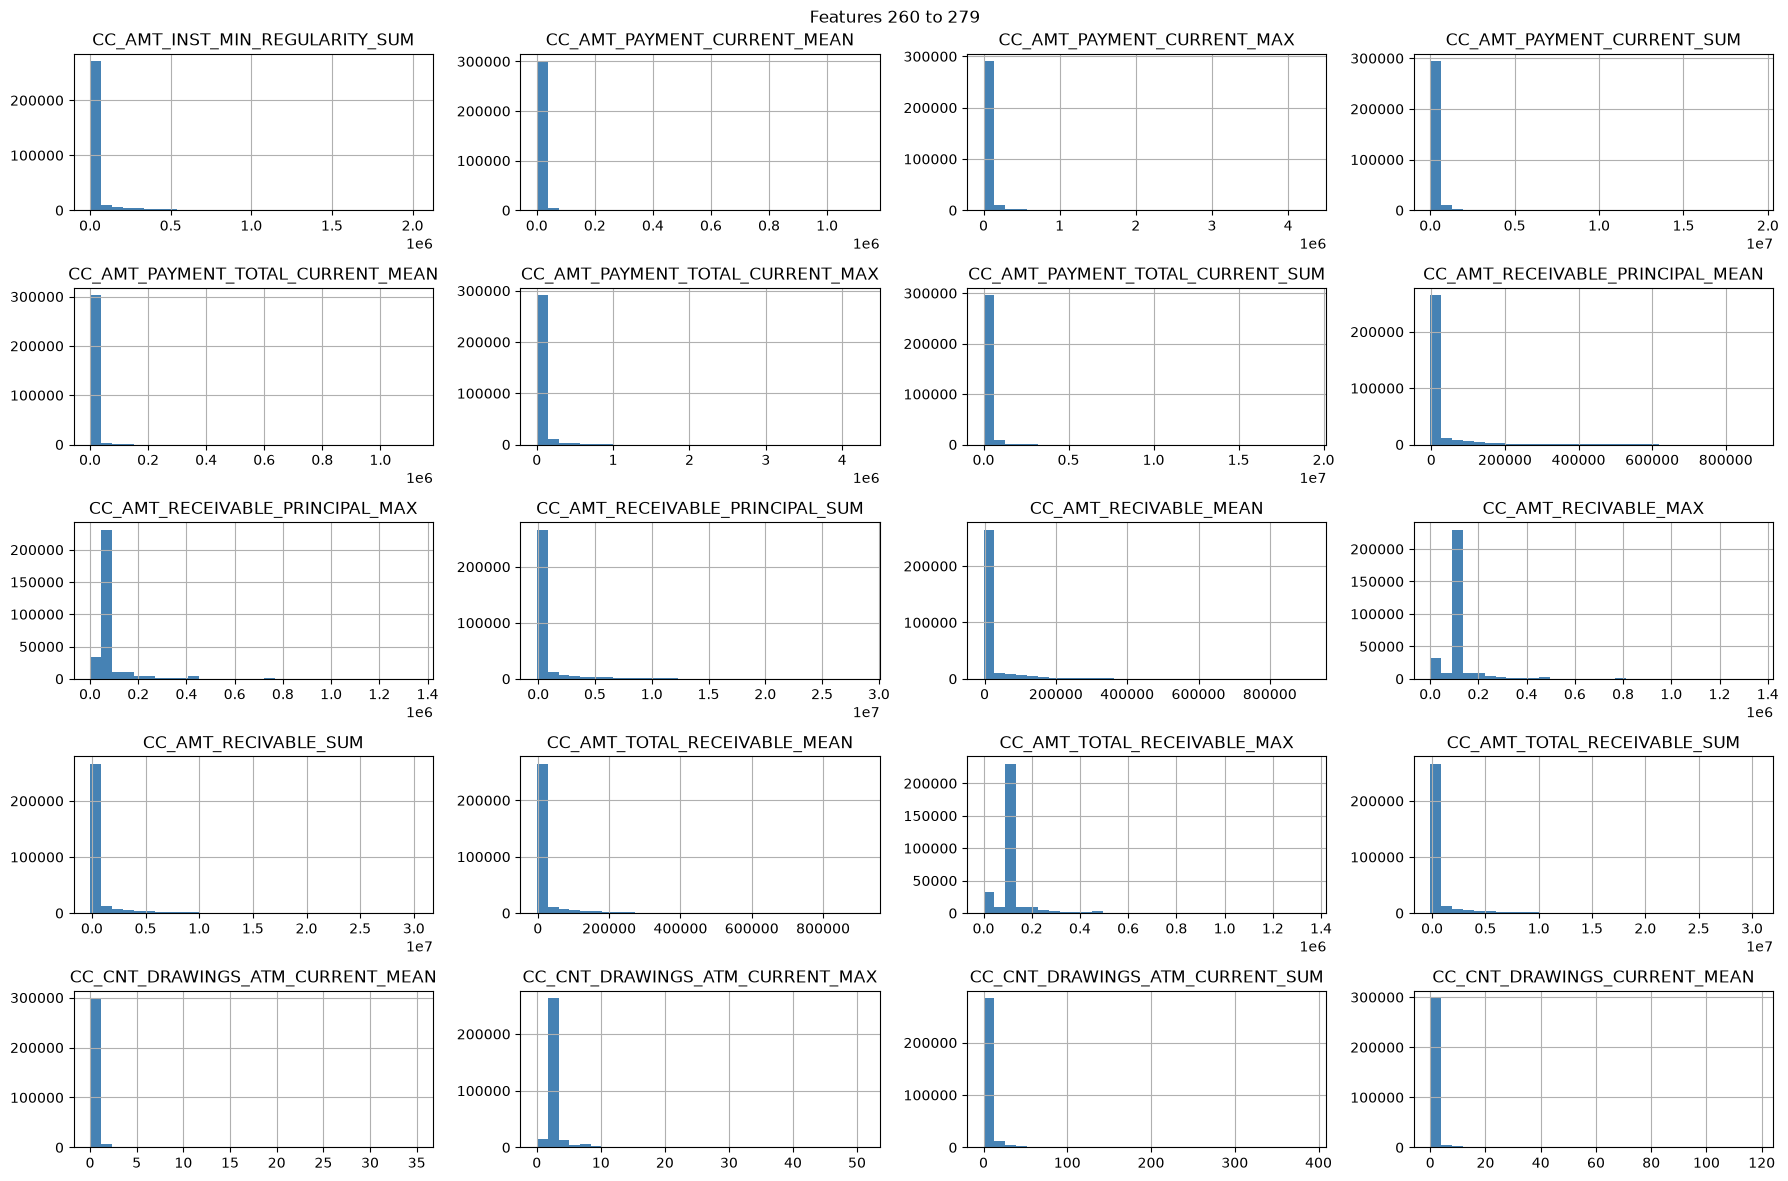

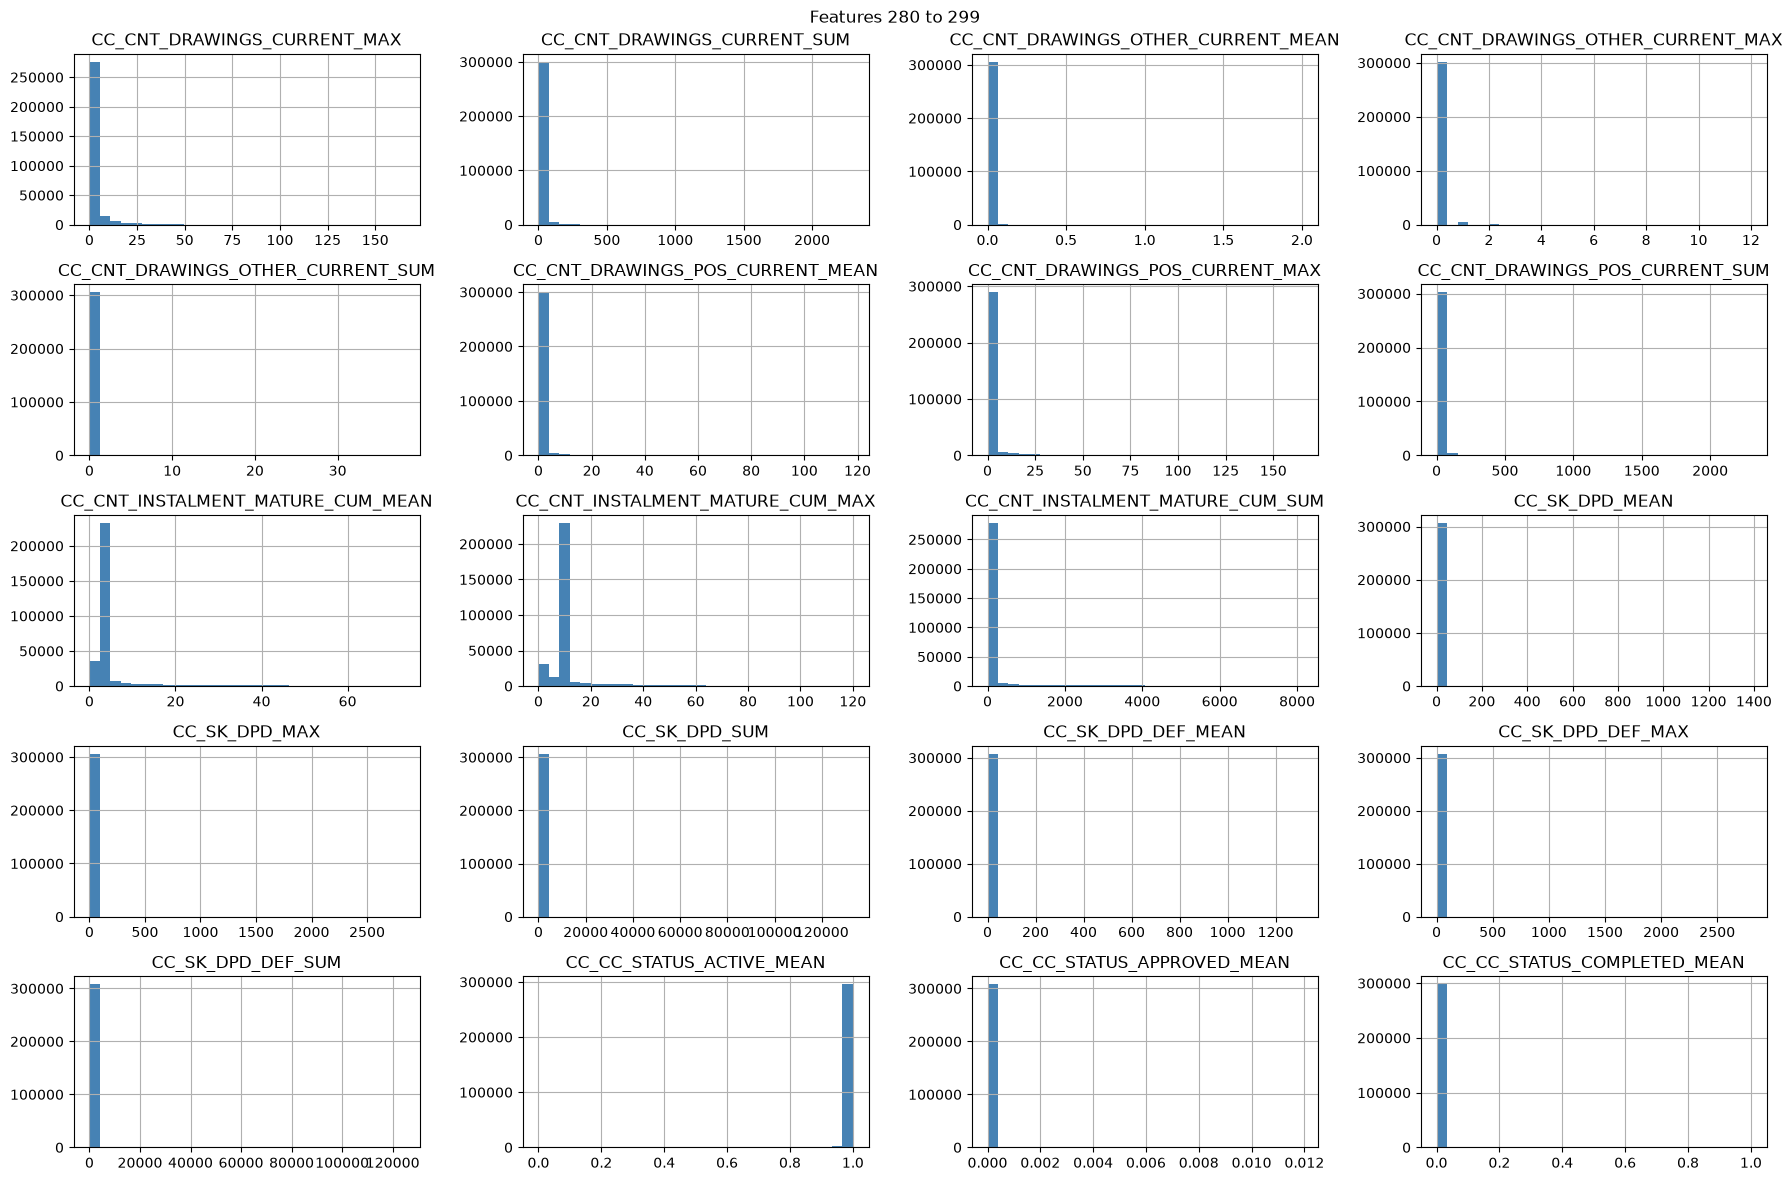

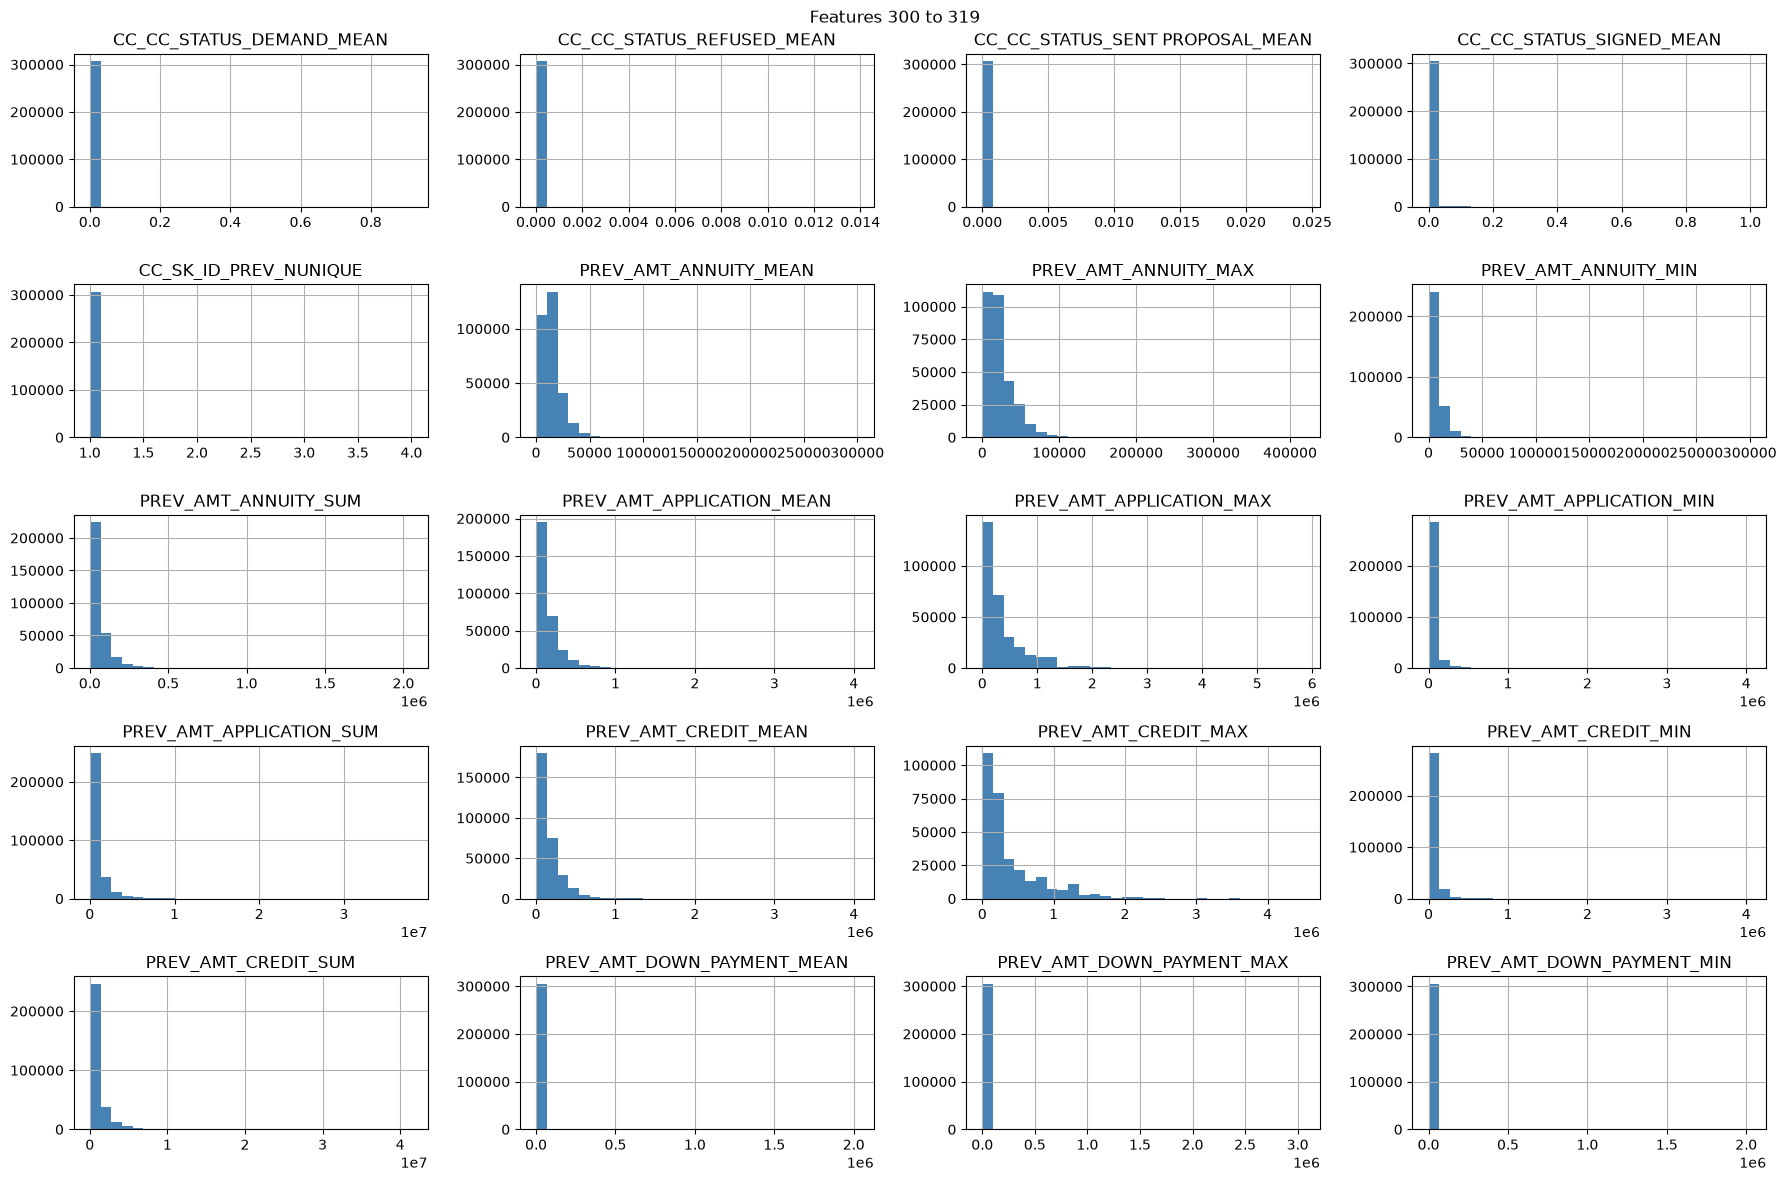

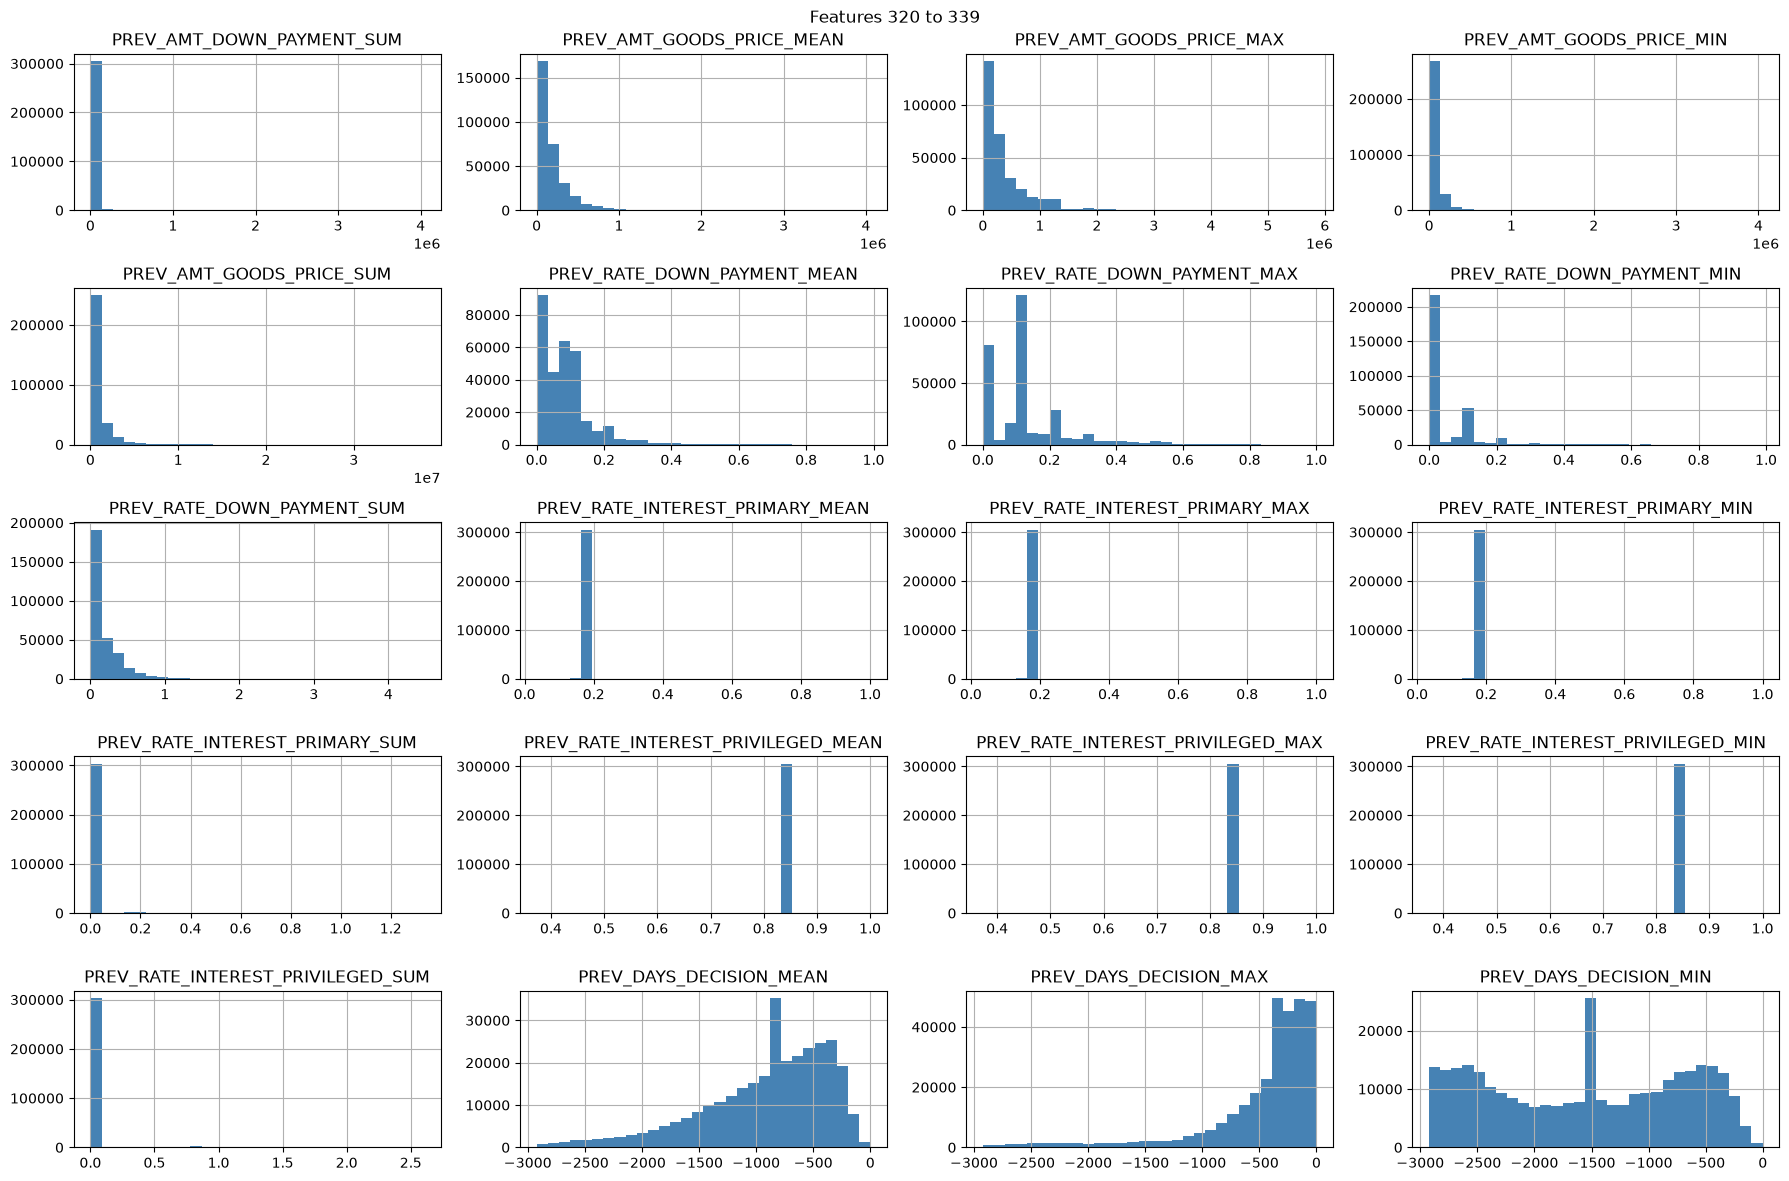

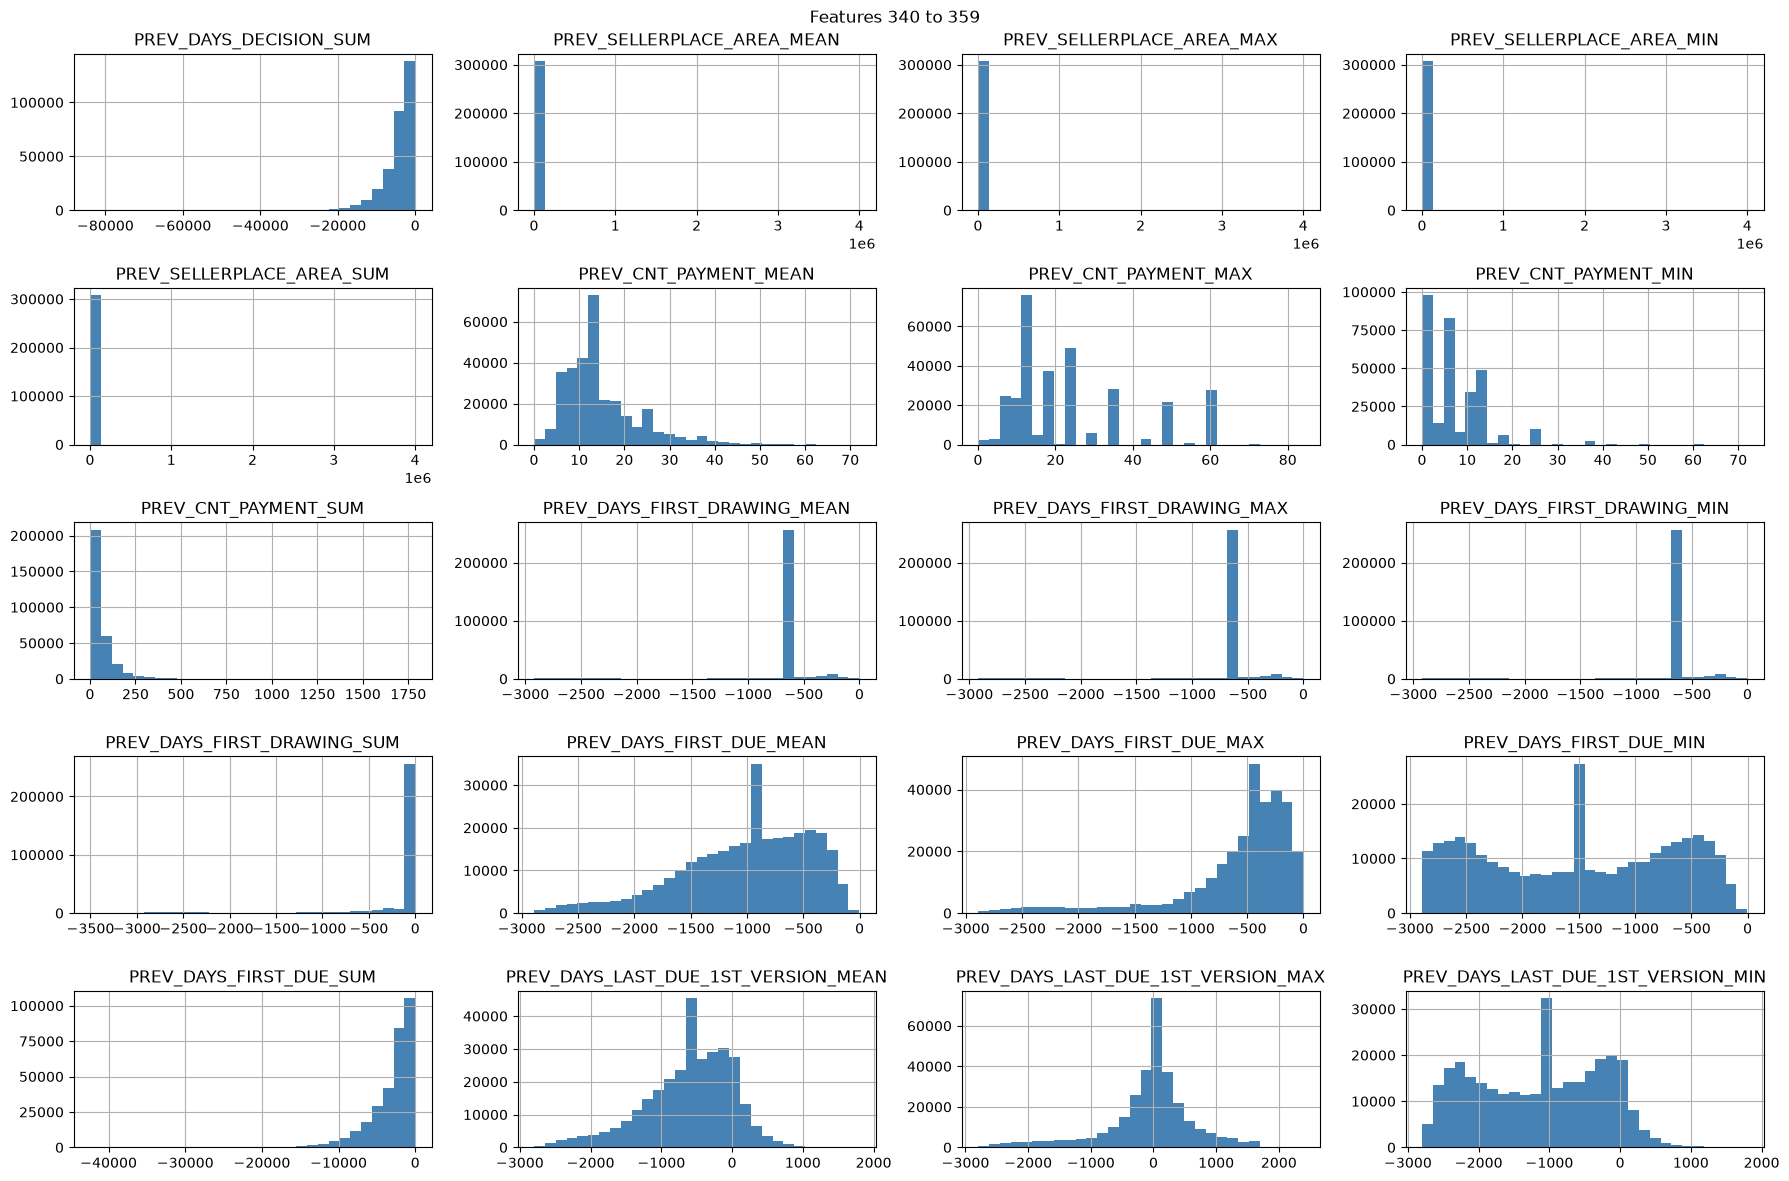

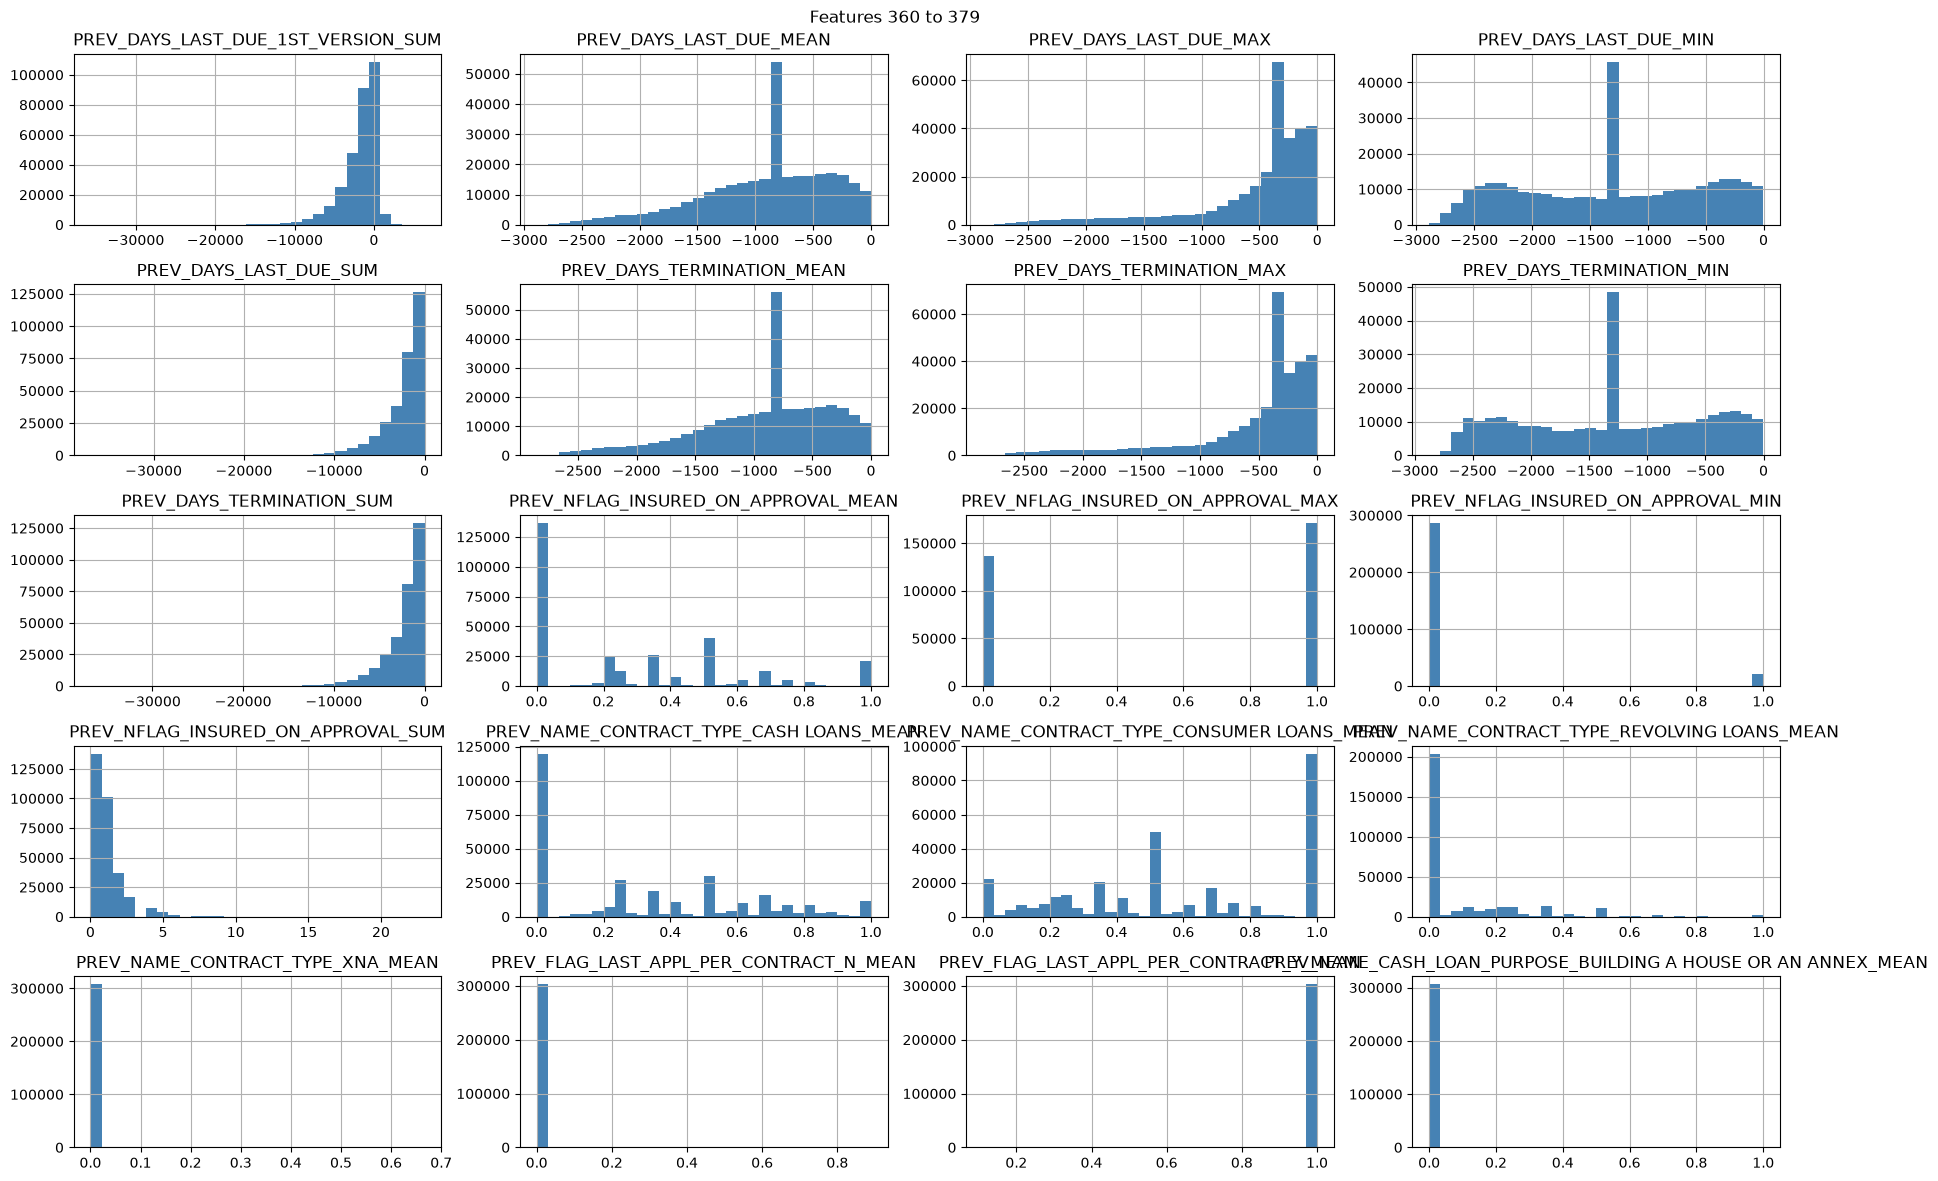

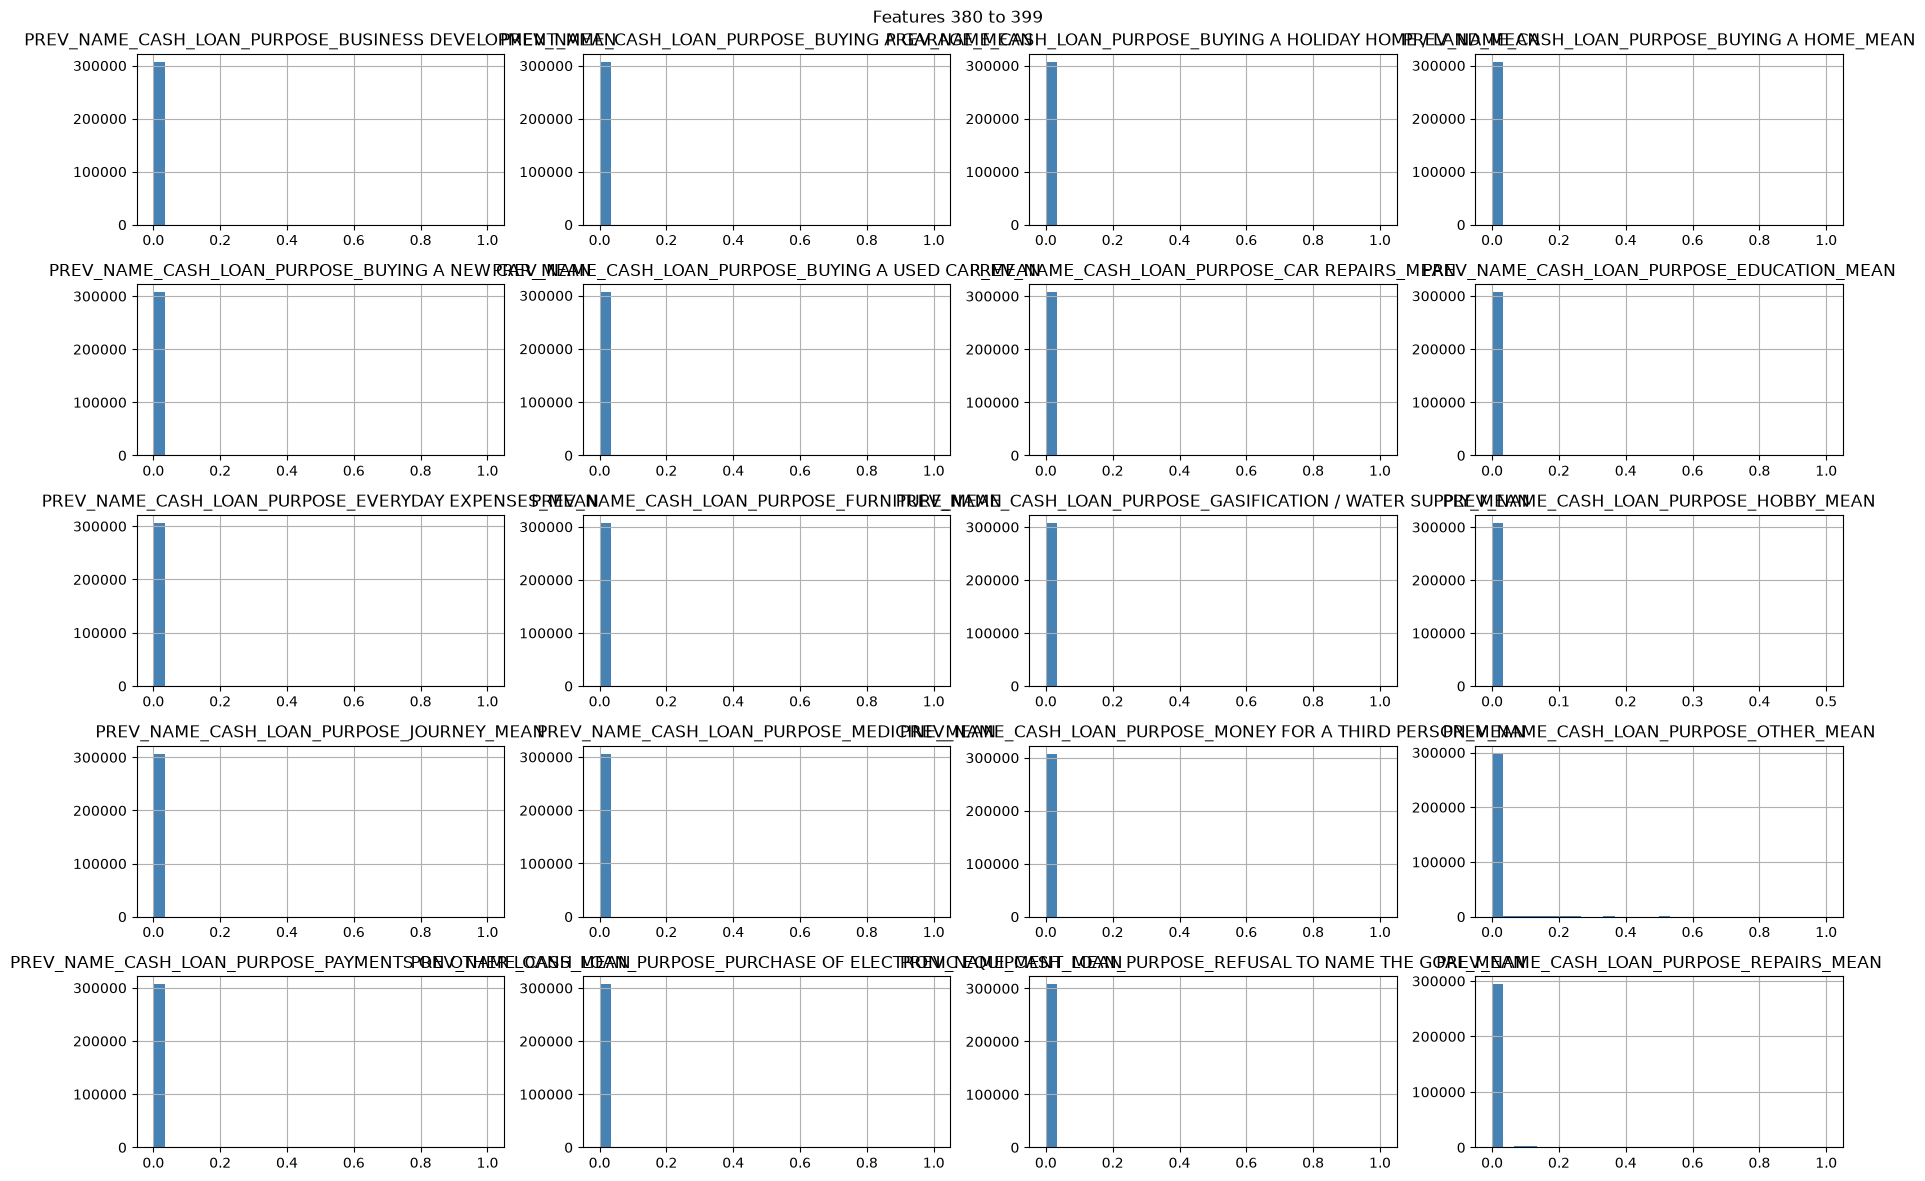

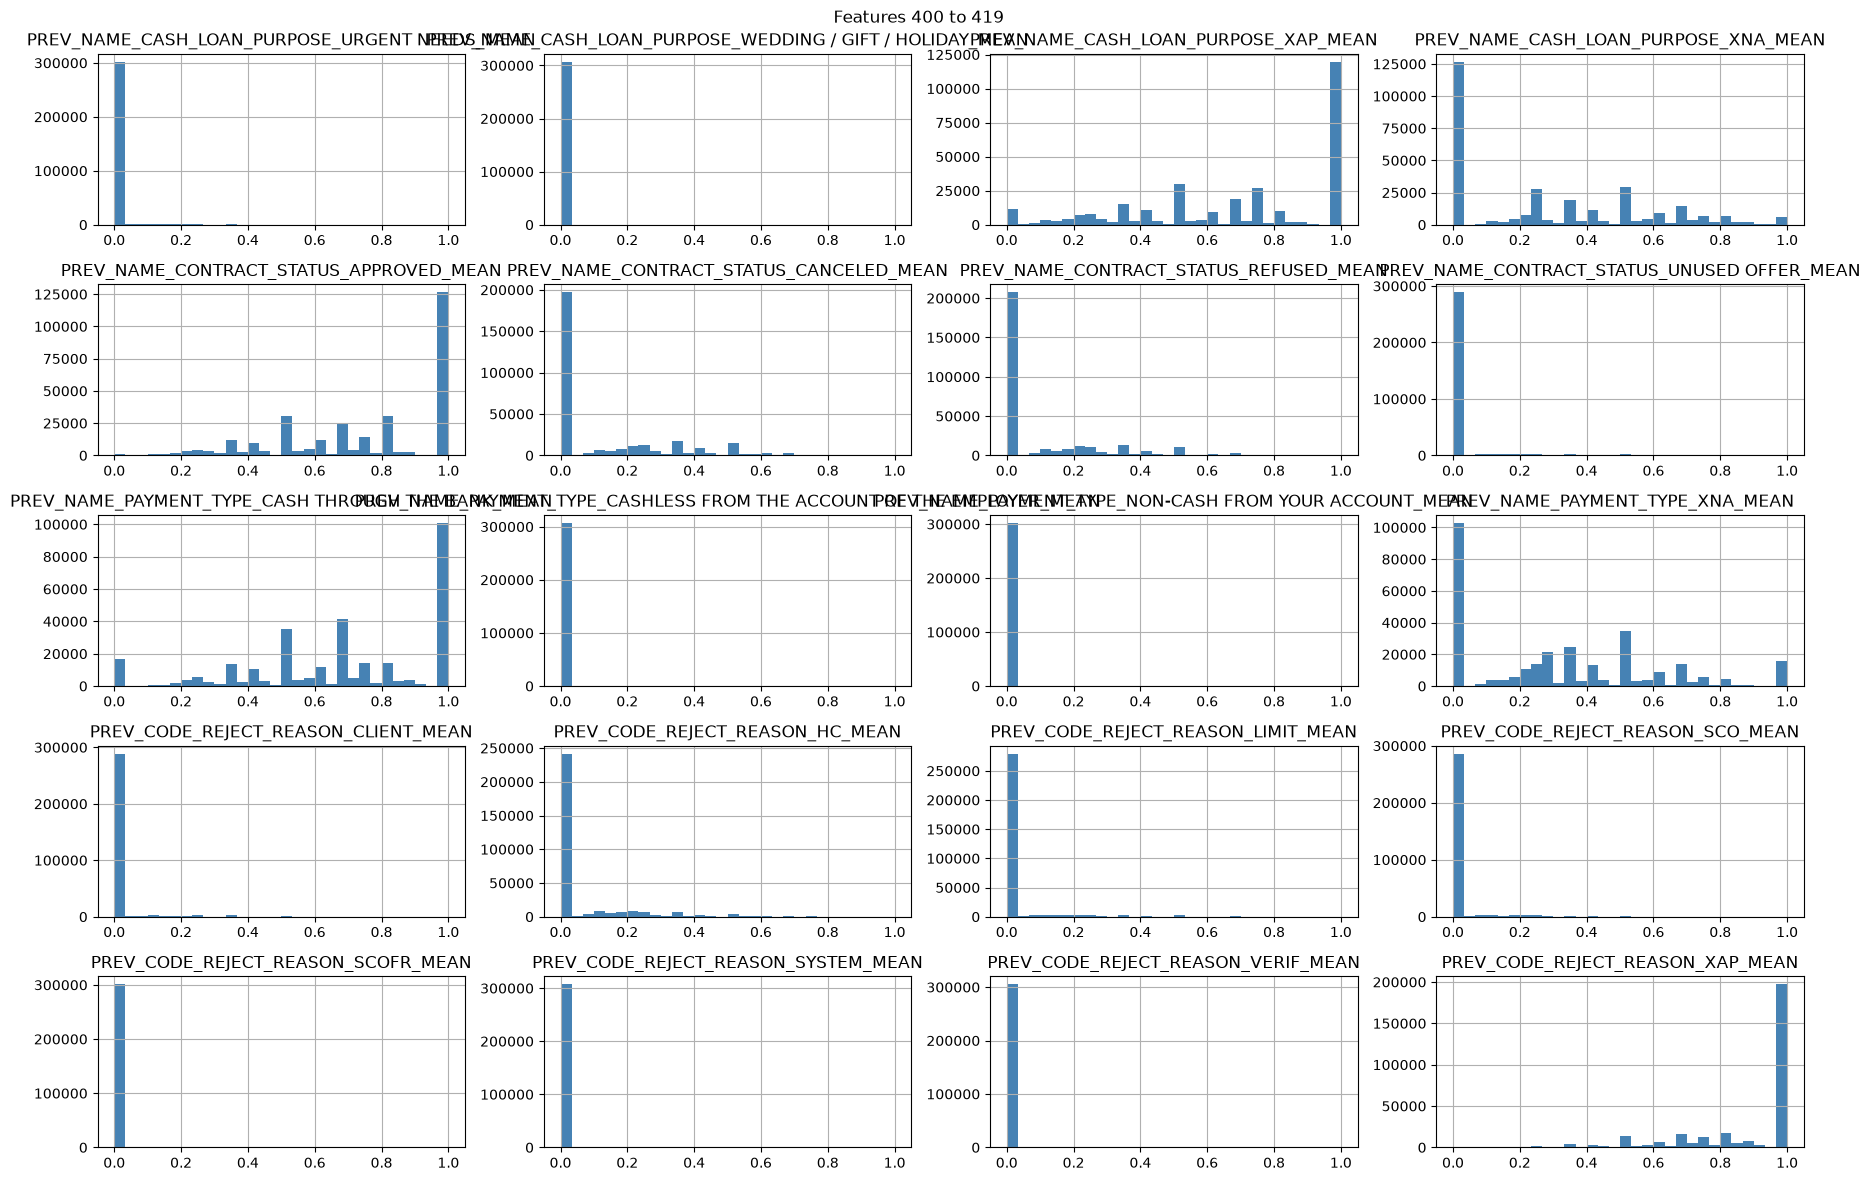

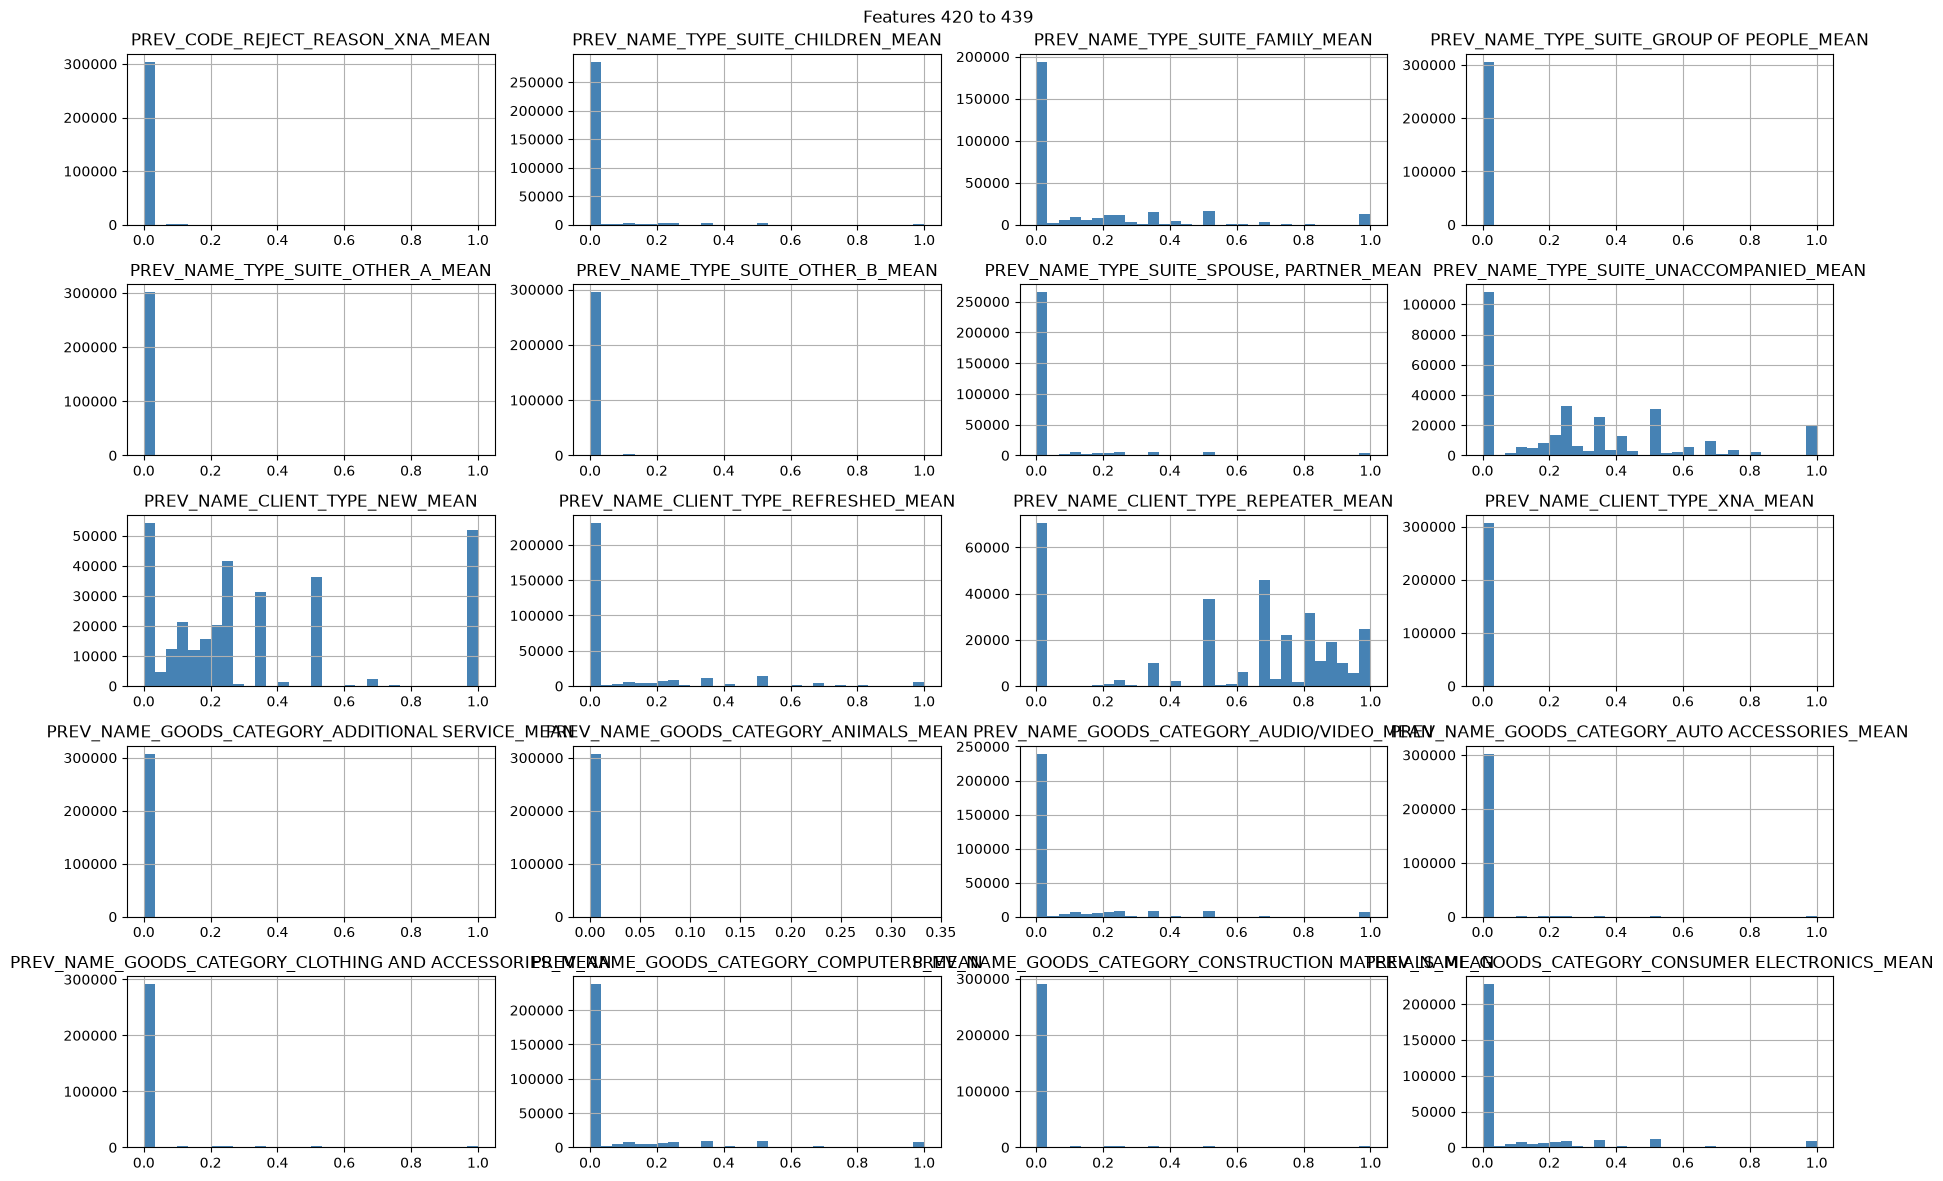

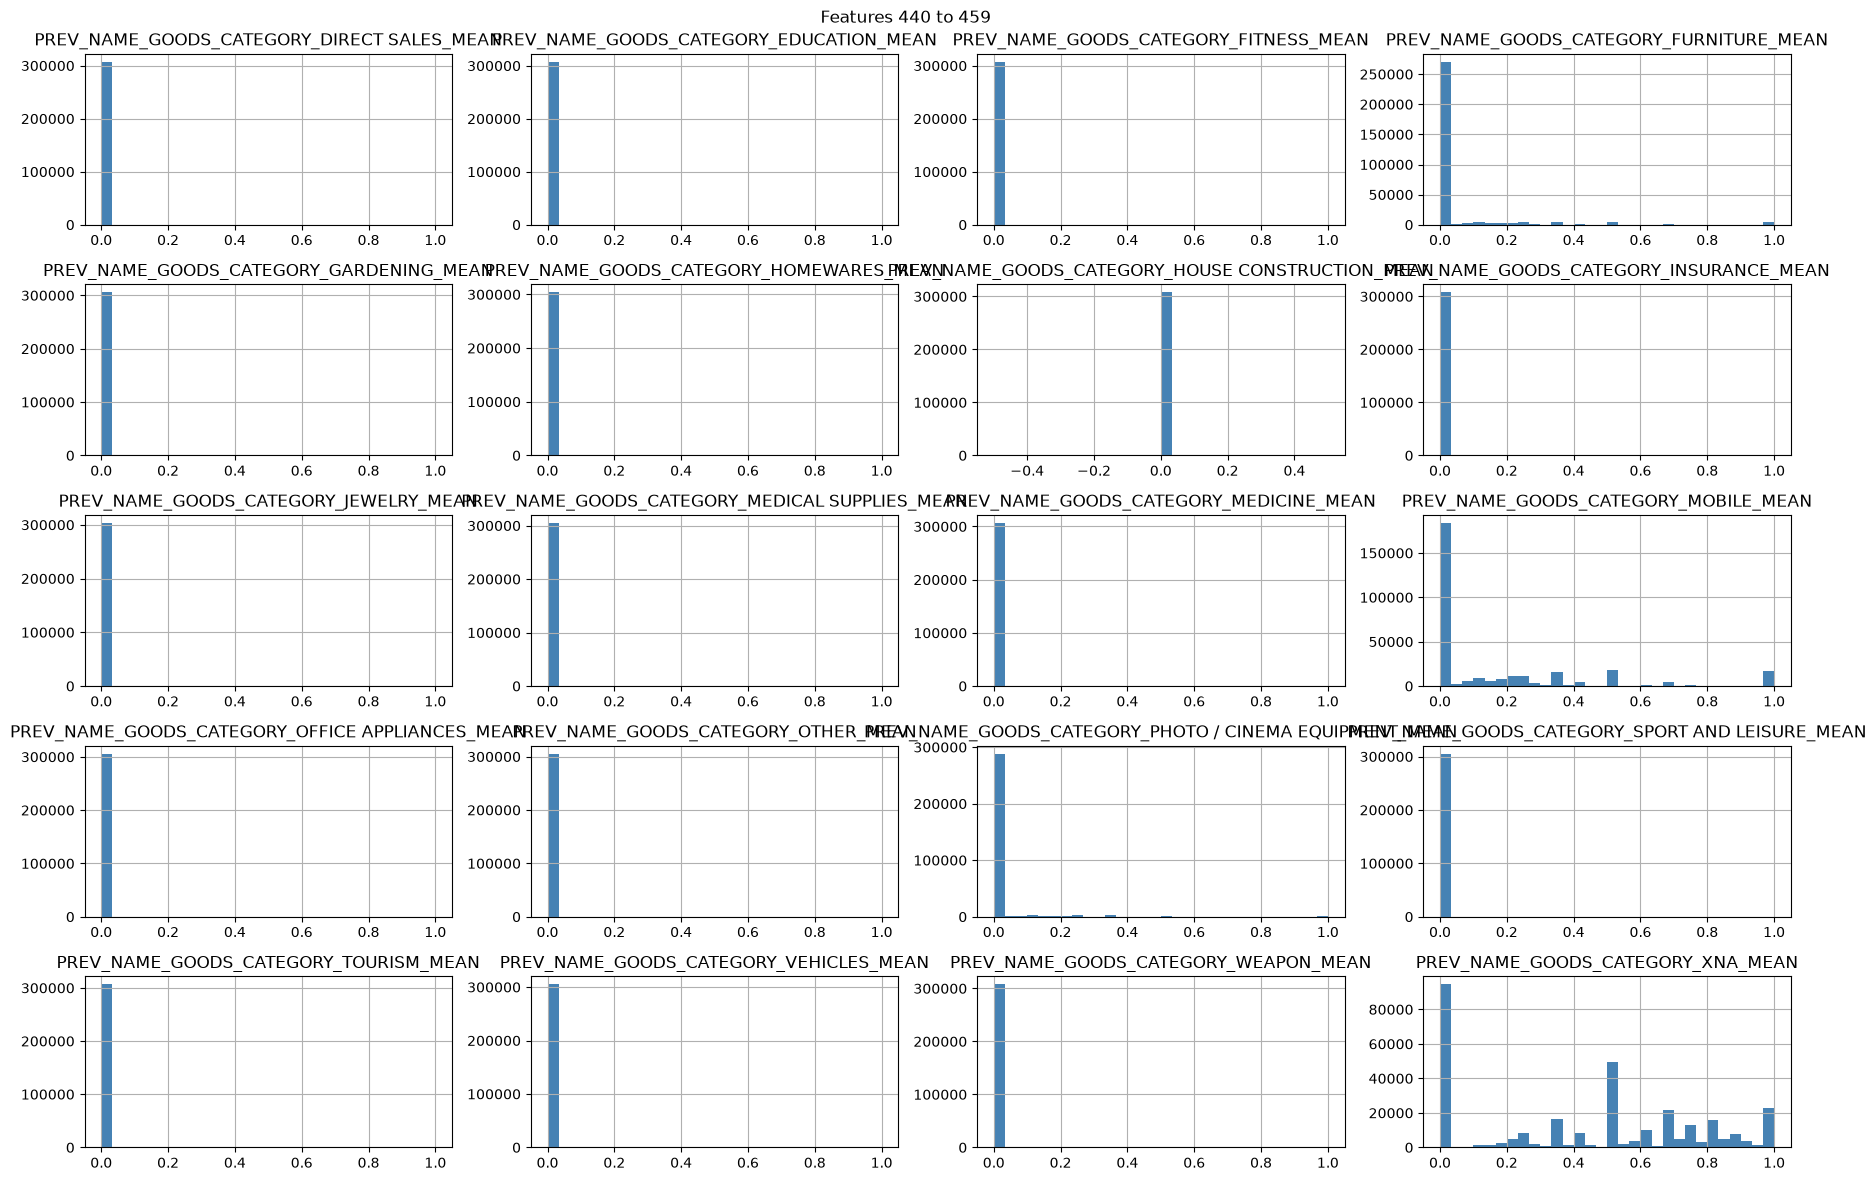

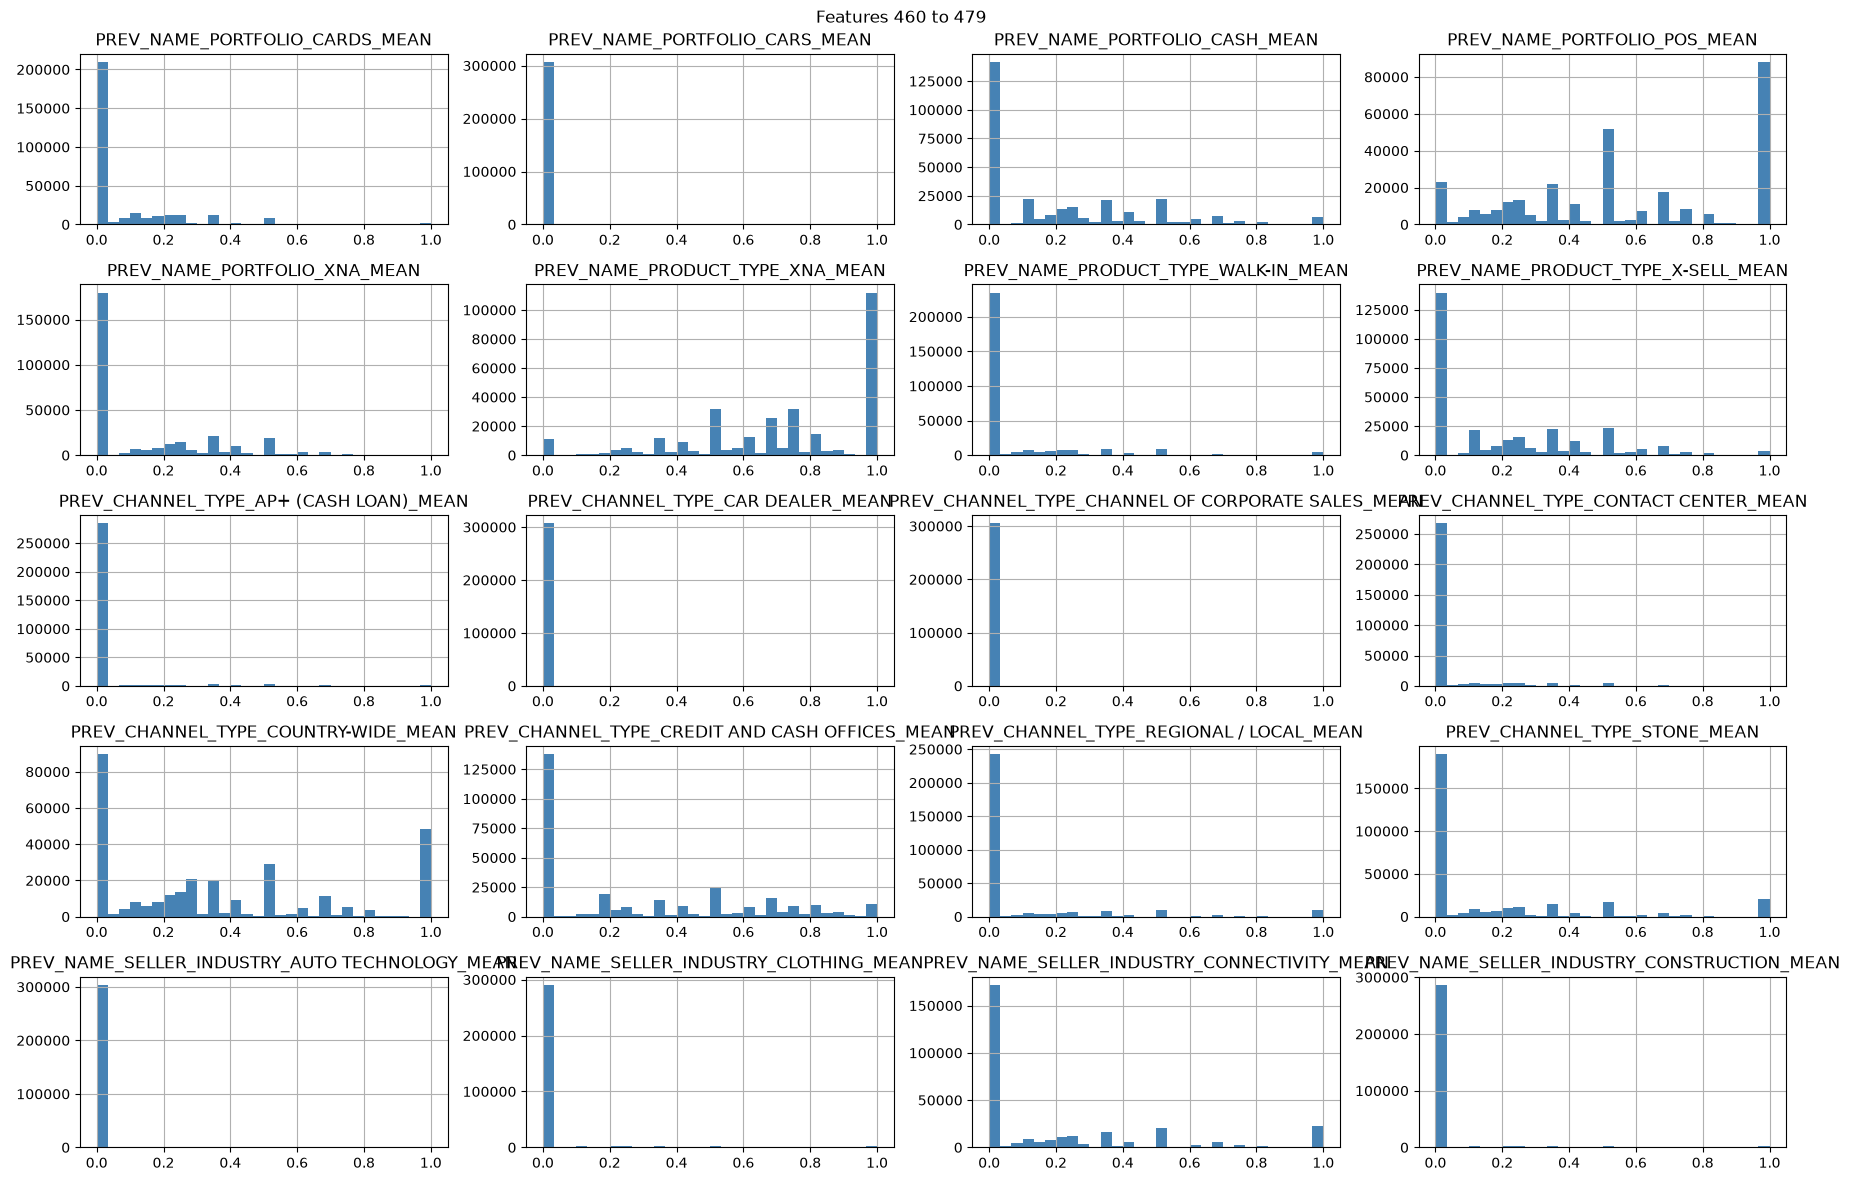

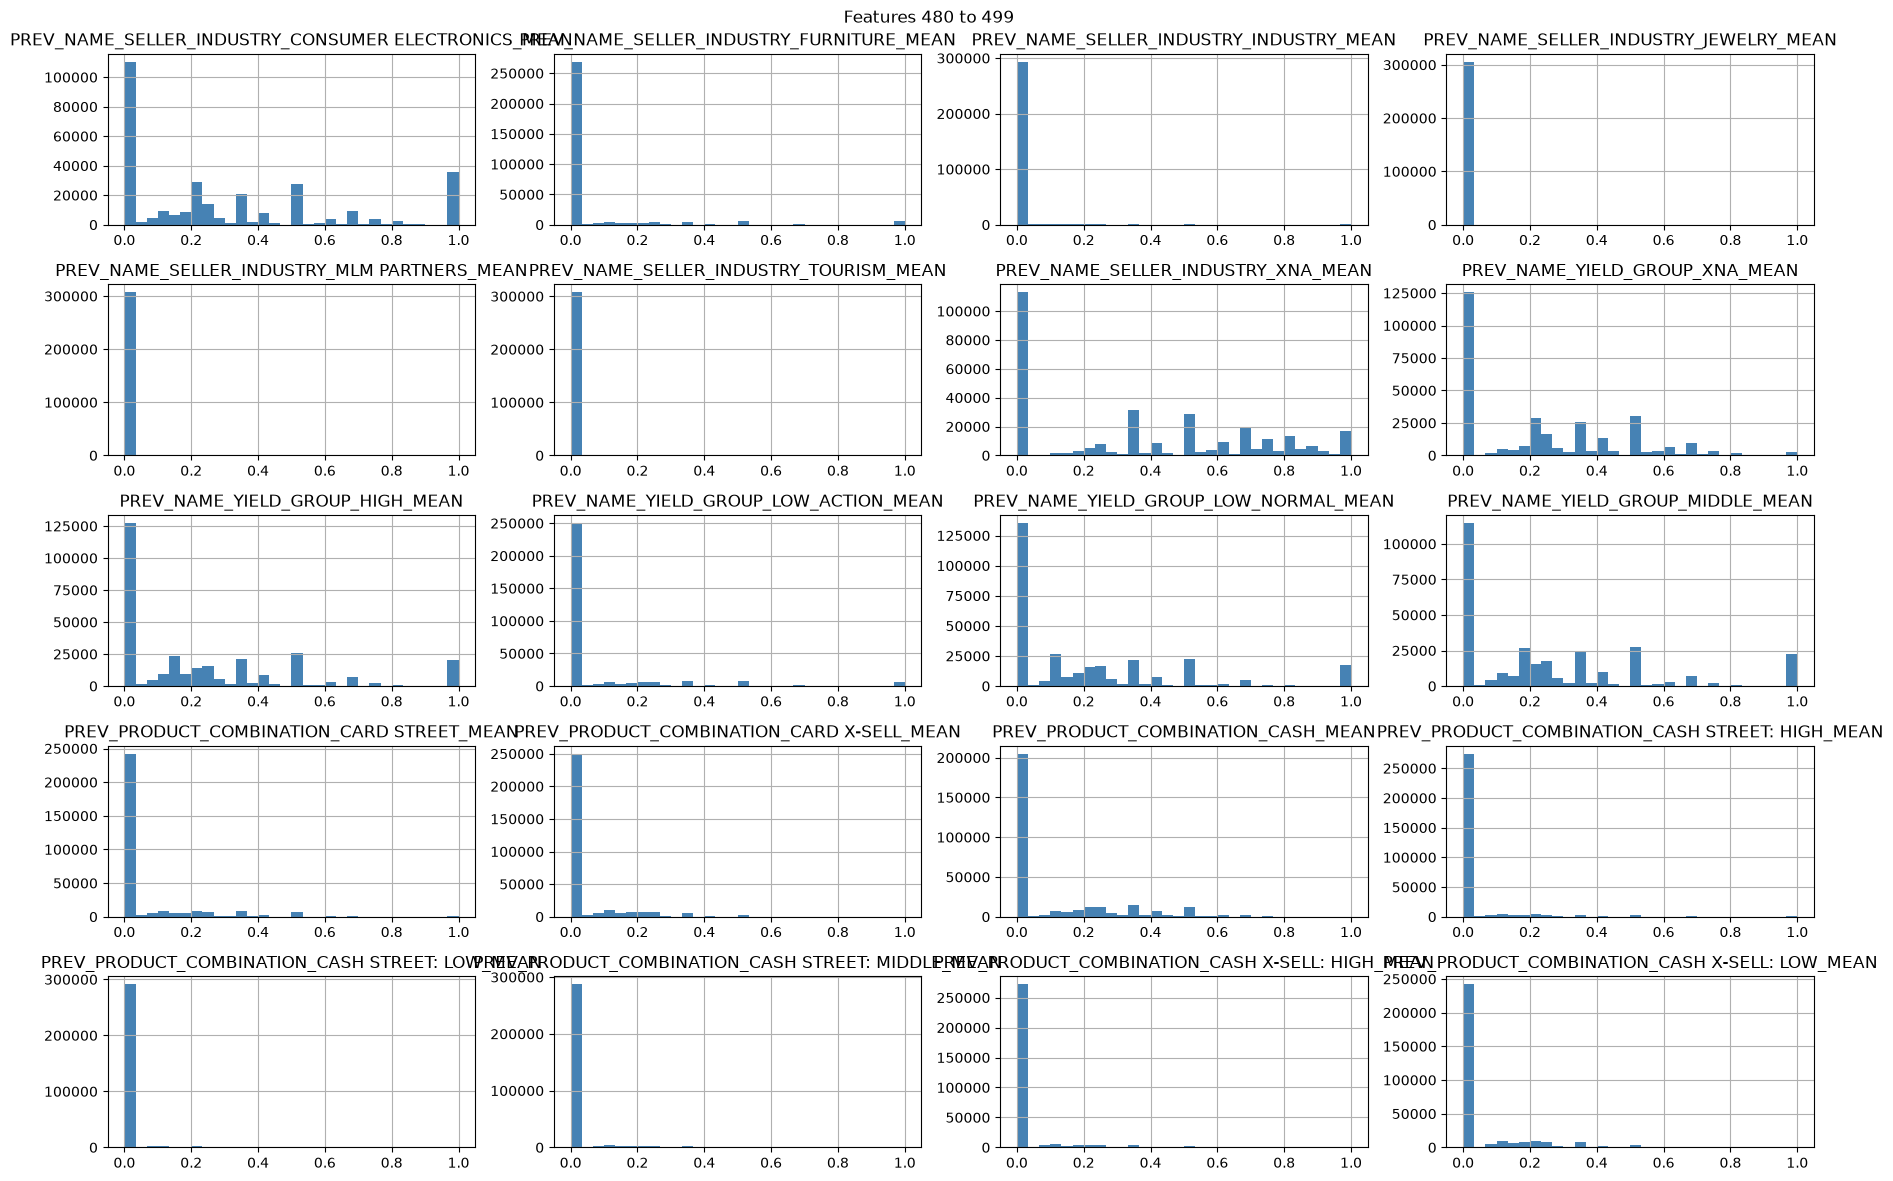

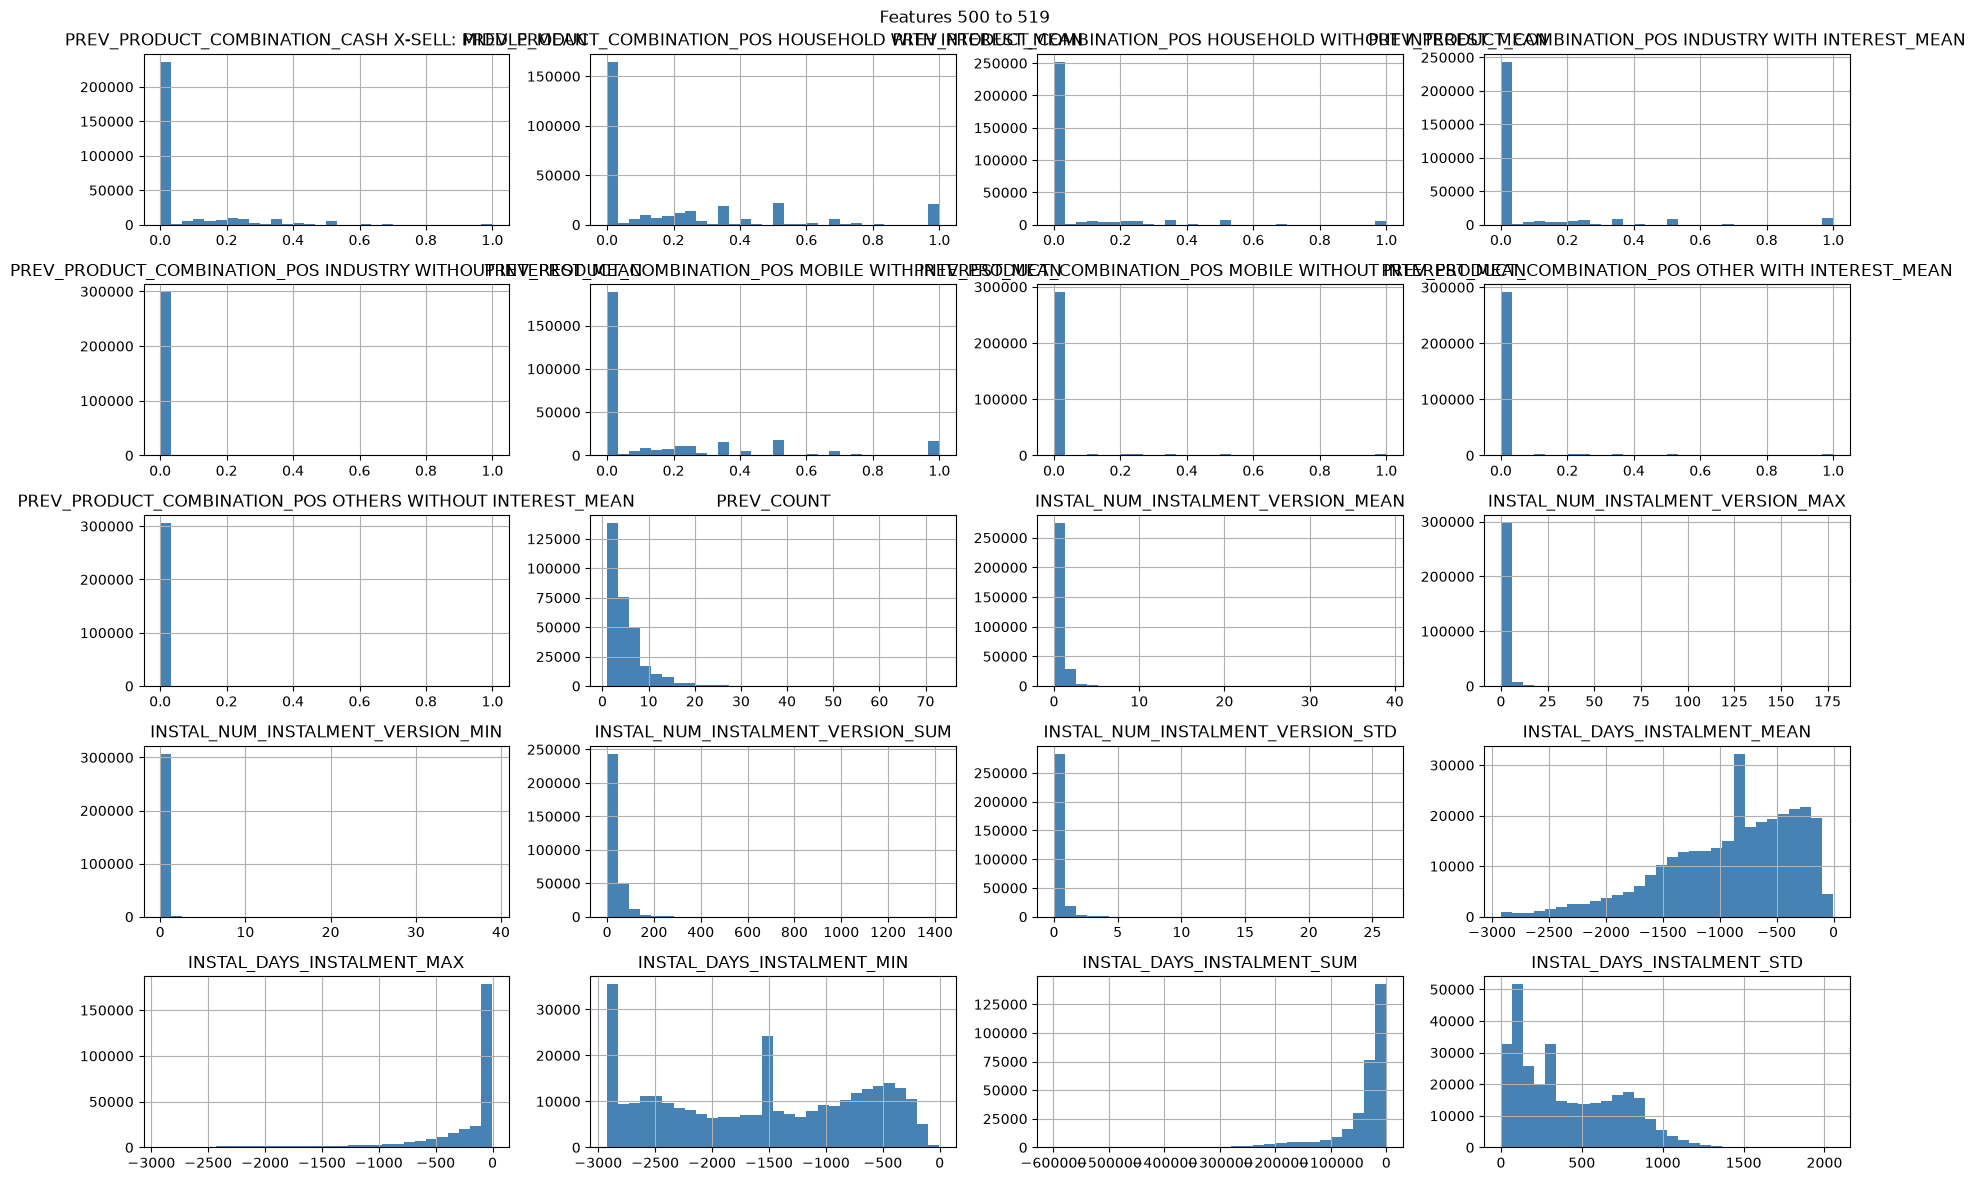

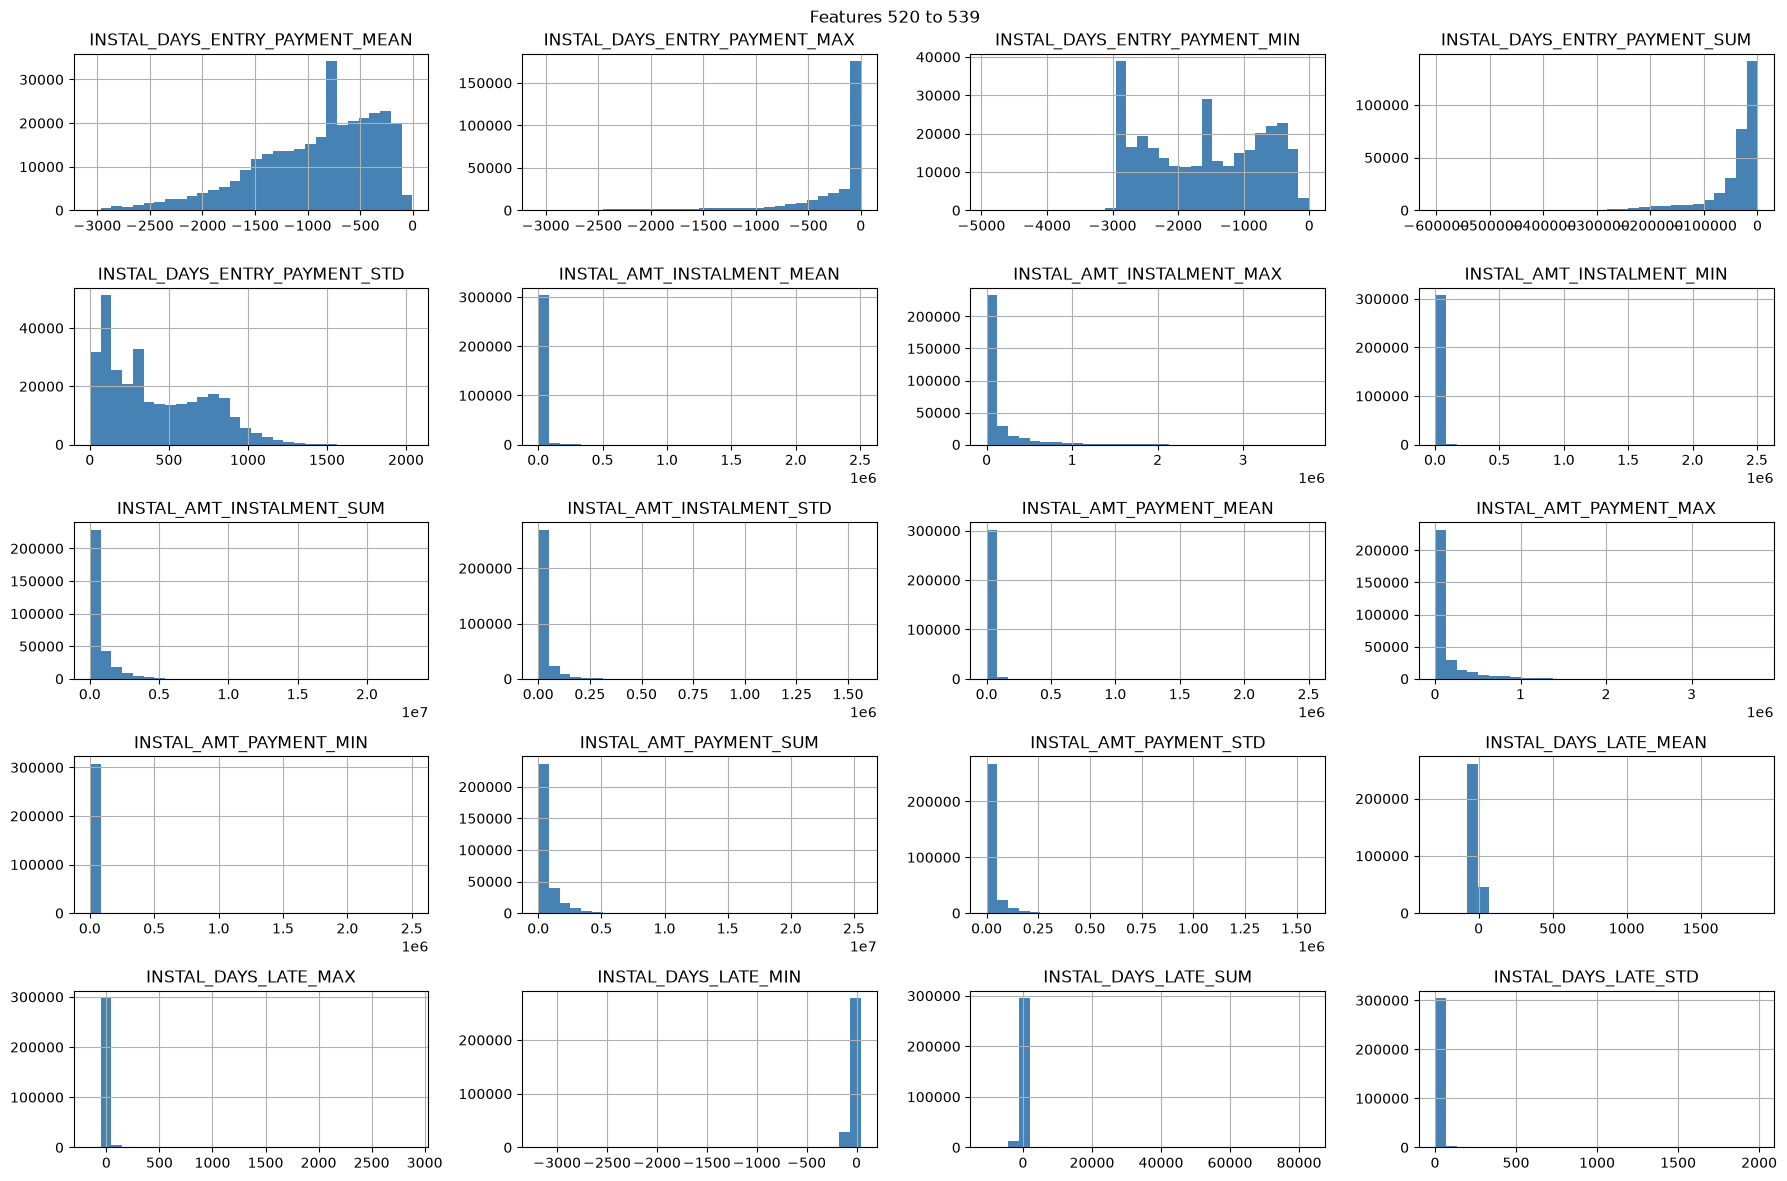

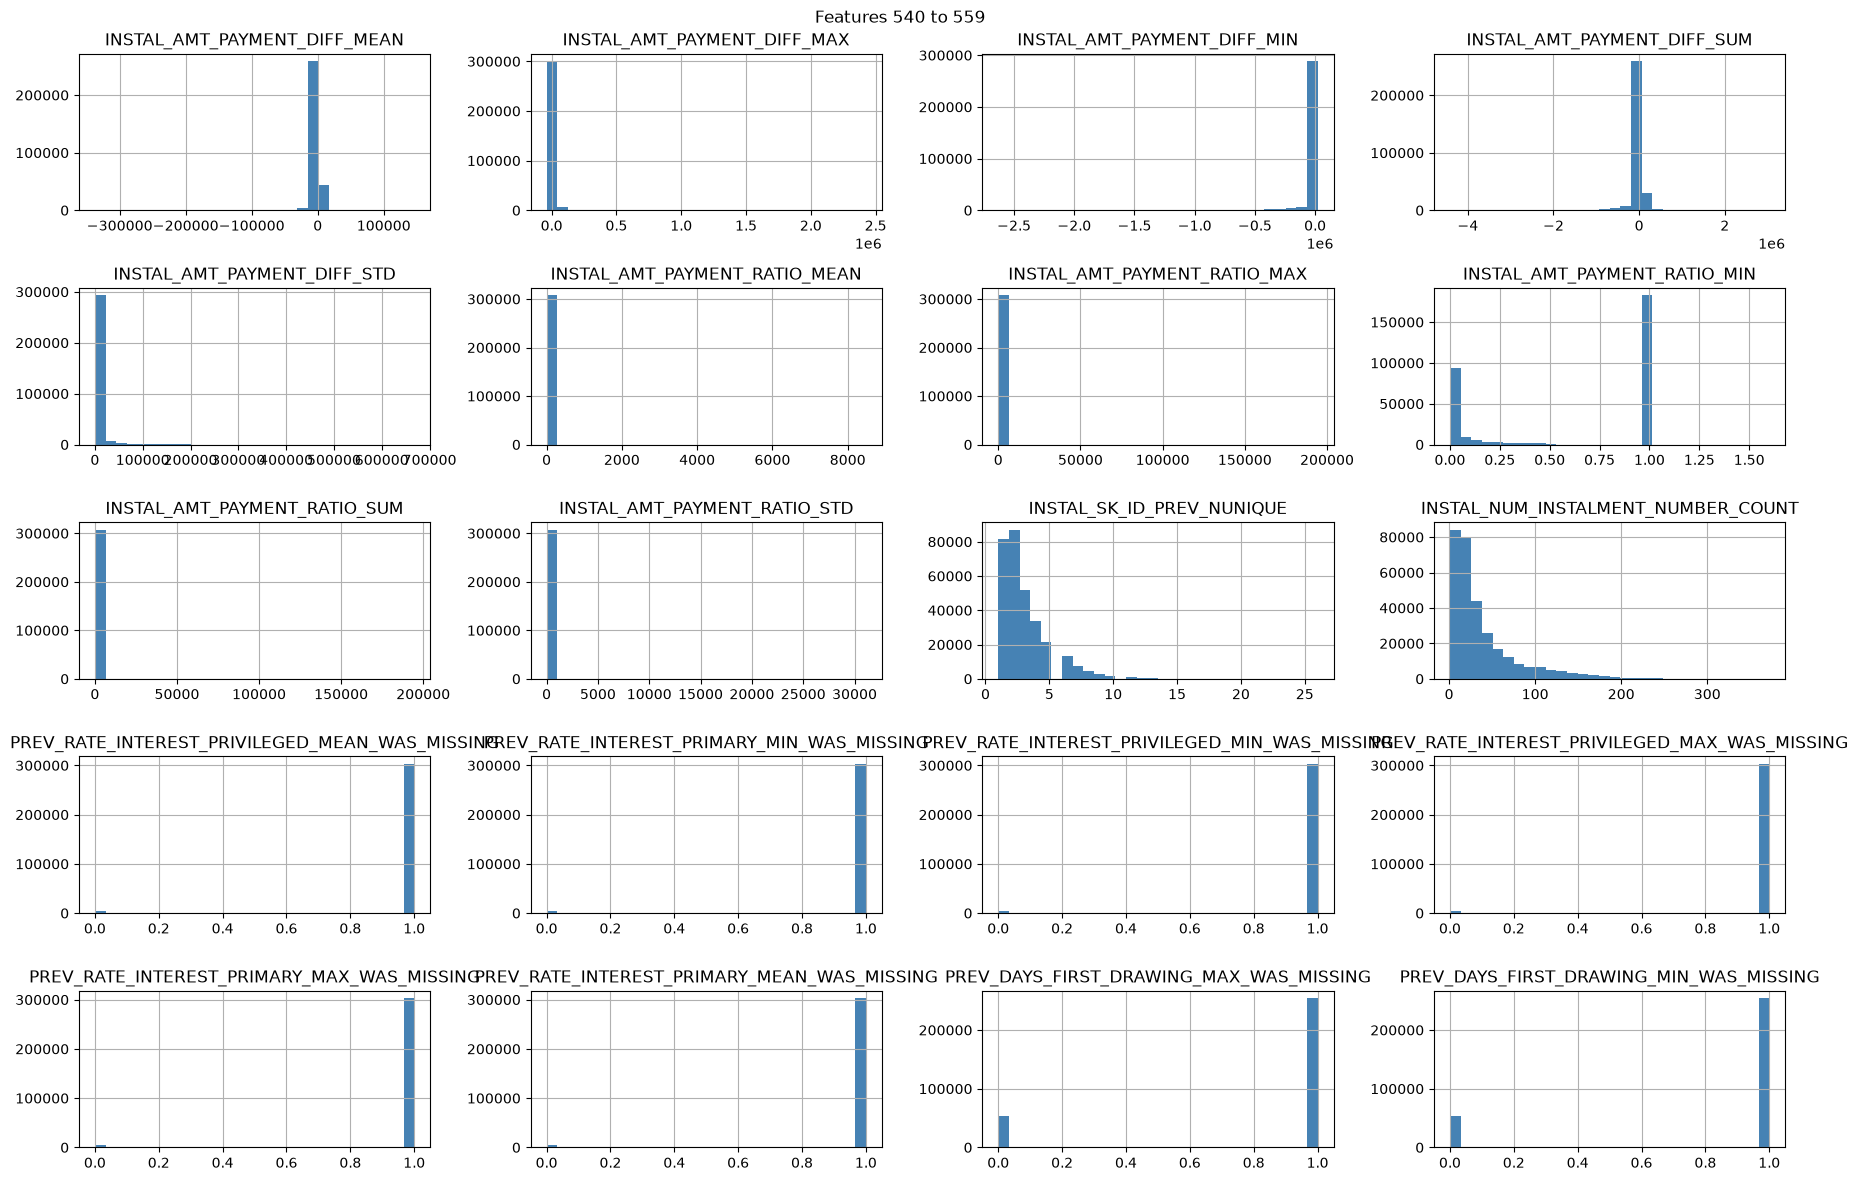

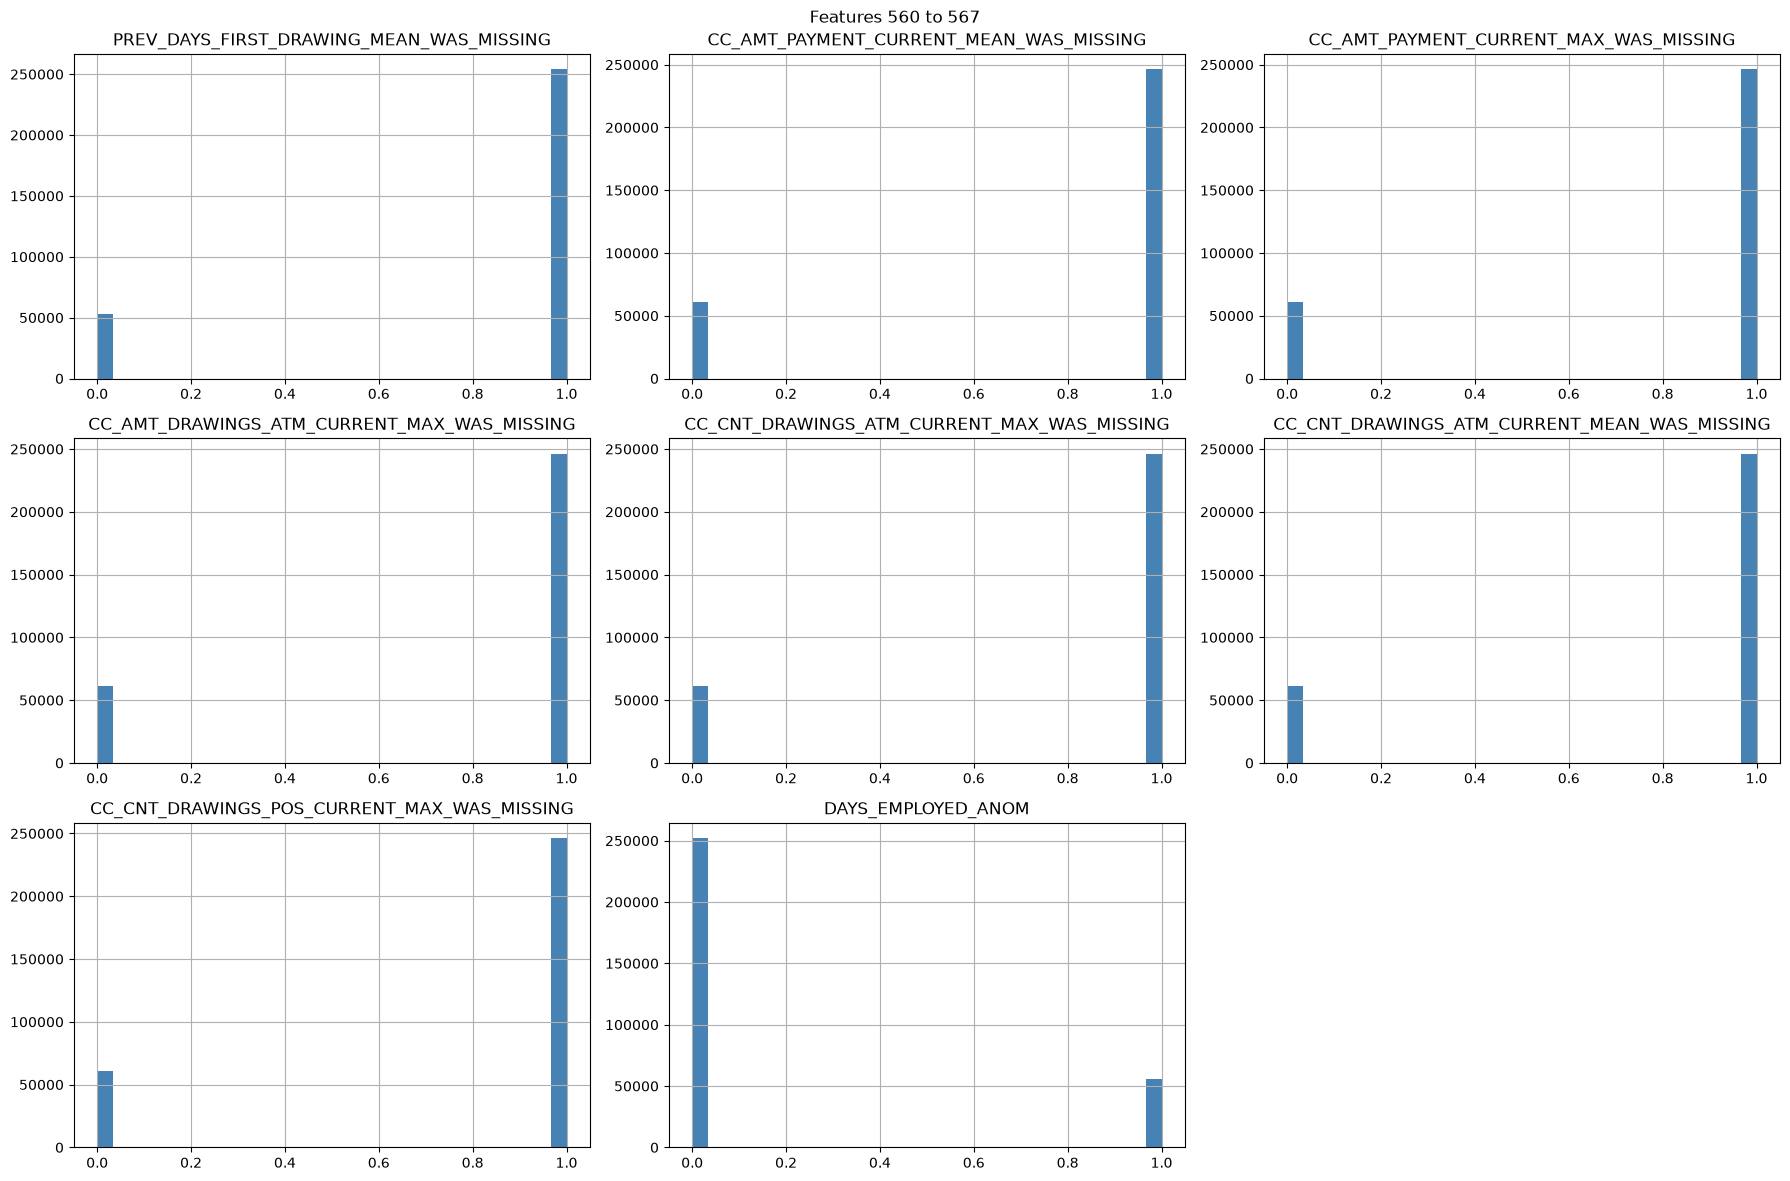

In [38]:
chunk_size = 20
cols = list(numeric_cols)

for i in range(0, len(cols), chunk_size):
    batch = cols[i:i+chunk_size]
    train[batch].hist(figsize=(18,12), bins=30, color="steelblue")
    plt.suptitle(f"Features {i} to {i+len(batch)-1}")
    plt.tight_layout()
    plt.show()


  A more efficient alternative is a skewness table (Skewness measures how asymmetrical a variable's distribution is), where the expected analysis should be 

| Skewness Value | Interpretation |
|---------------|----------------|
| **0** | Perfectly symmetric (normal distribution). |
| **Between -0.5 and 0.5** | Approximately symmetric with little or no skewness. |
| **Between 0.5 and 1** | Moderately positively skewed (right-skewed). |
| **Greater than 1** | Highly positively skewed (long right tail). |
| **Between -1 and -0.5** | Moderately negatively skewed (left-skewed). |
| **Less than -1** | Highly negatively skewed (long left tail). |

This will  flag which columns are worth looking at

In [39]:
skew = train[numeric_cols].skew().sort_values(ascending=False)
print("Most skewed features:")
skew.head(20)

Most skewed features:


BUREAU_CREDIT_TYPE_INTERBANK CREDIT_MEAN                                554.536744
PREV_NAME_GOODS_CATEGORY_ANIMALS_MEAN                                   554.536744
BUREAU_CREDIT_TYPE_MOBILE OPERATOR LOAN_MEAN                            554.536744
BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN                                       480.296240
BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN                                      411.543044
BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN                                       393.825372
POS_POS_STATUS_XNA_MEAN                                                 392.165512
FLAG_DOCUMENT_12                                                        392.114779
AMT_INCOME_TOTAL                                                        391.559654
PREV_NAME_CASH_LOAN_PURPOSE_REFUSAL TO NAME THE GOAL_MEAN               385.635758
PREV_SELLERPLACE_AREA_MIN                                               384.781515
BUREAU_CREDIT_TYPE_LOAN FOR PURCHASE OF SHARES (MARGIN LENDING)_MEAN    381.376998
BURE

Skewness analysis is carried out to understand how the numerical features were distributed. The results showed that many features were highly positively skewed, with skewness values much greater than 1. This means that most applicants had low values for these features, while only a few applicants had very high values. Most of the highly skewed features came from the bureau and previous application datasets, where many values were zero and only a small number of applicants had non-zero values. The AMT_INCOME_TOTAL feature was also highly skewed because most applicants had moderate incomes, while a few had much higher incomes. Overall, the results show that the data is not evenly distributed.

c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\Desktop\final project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


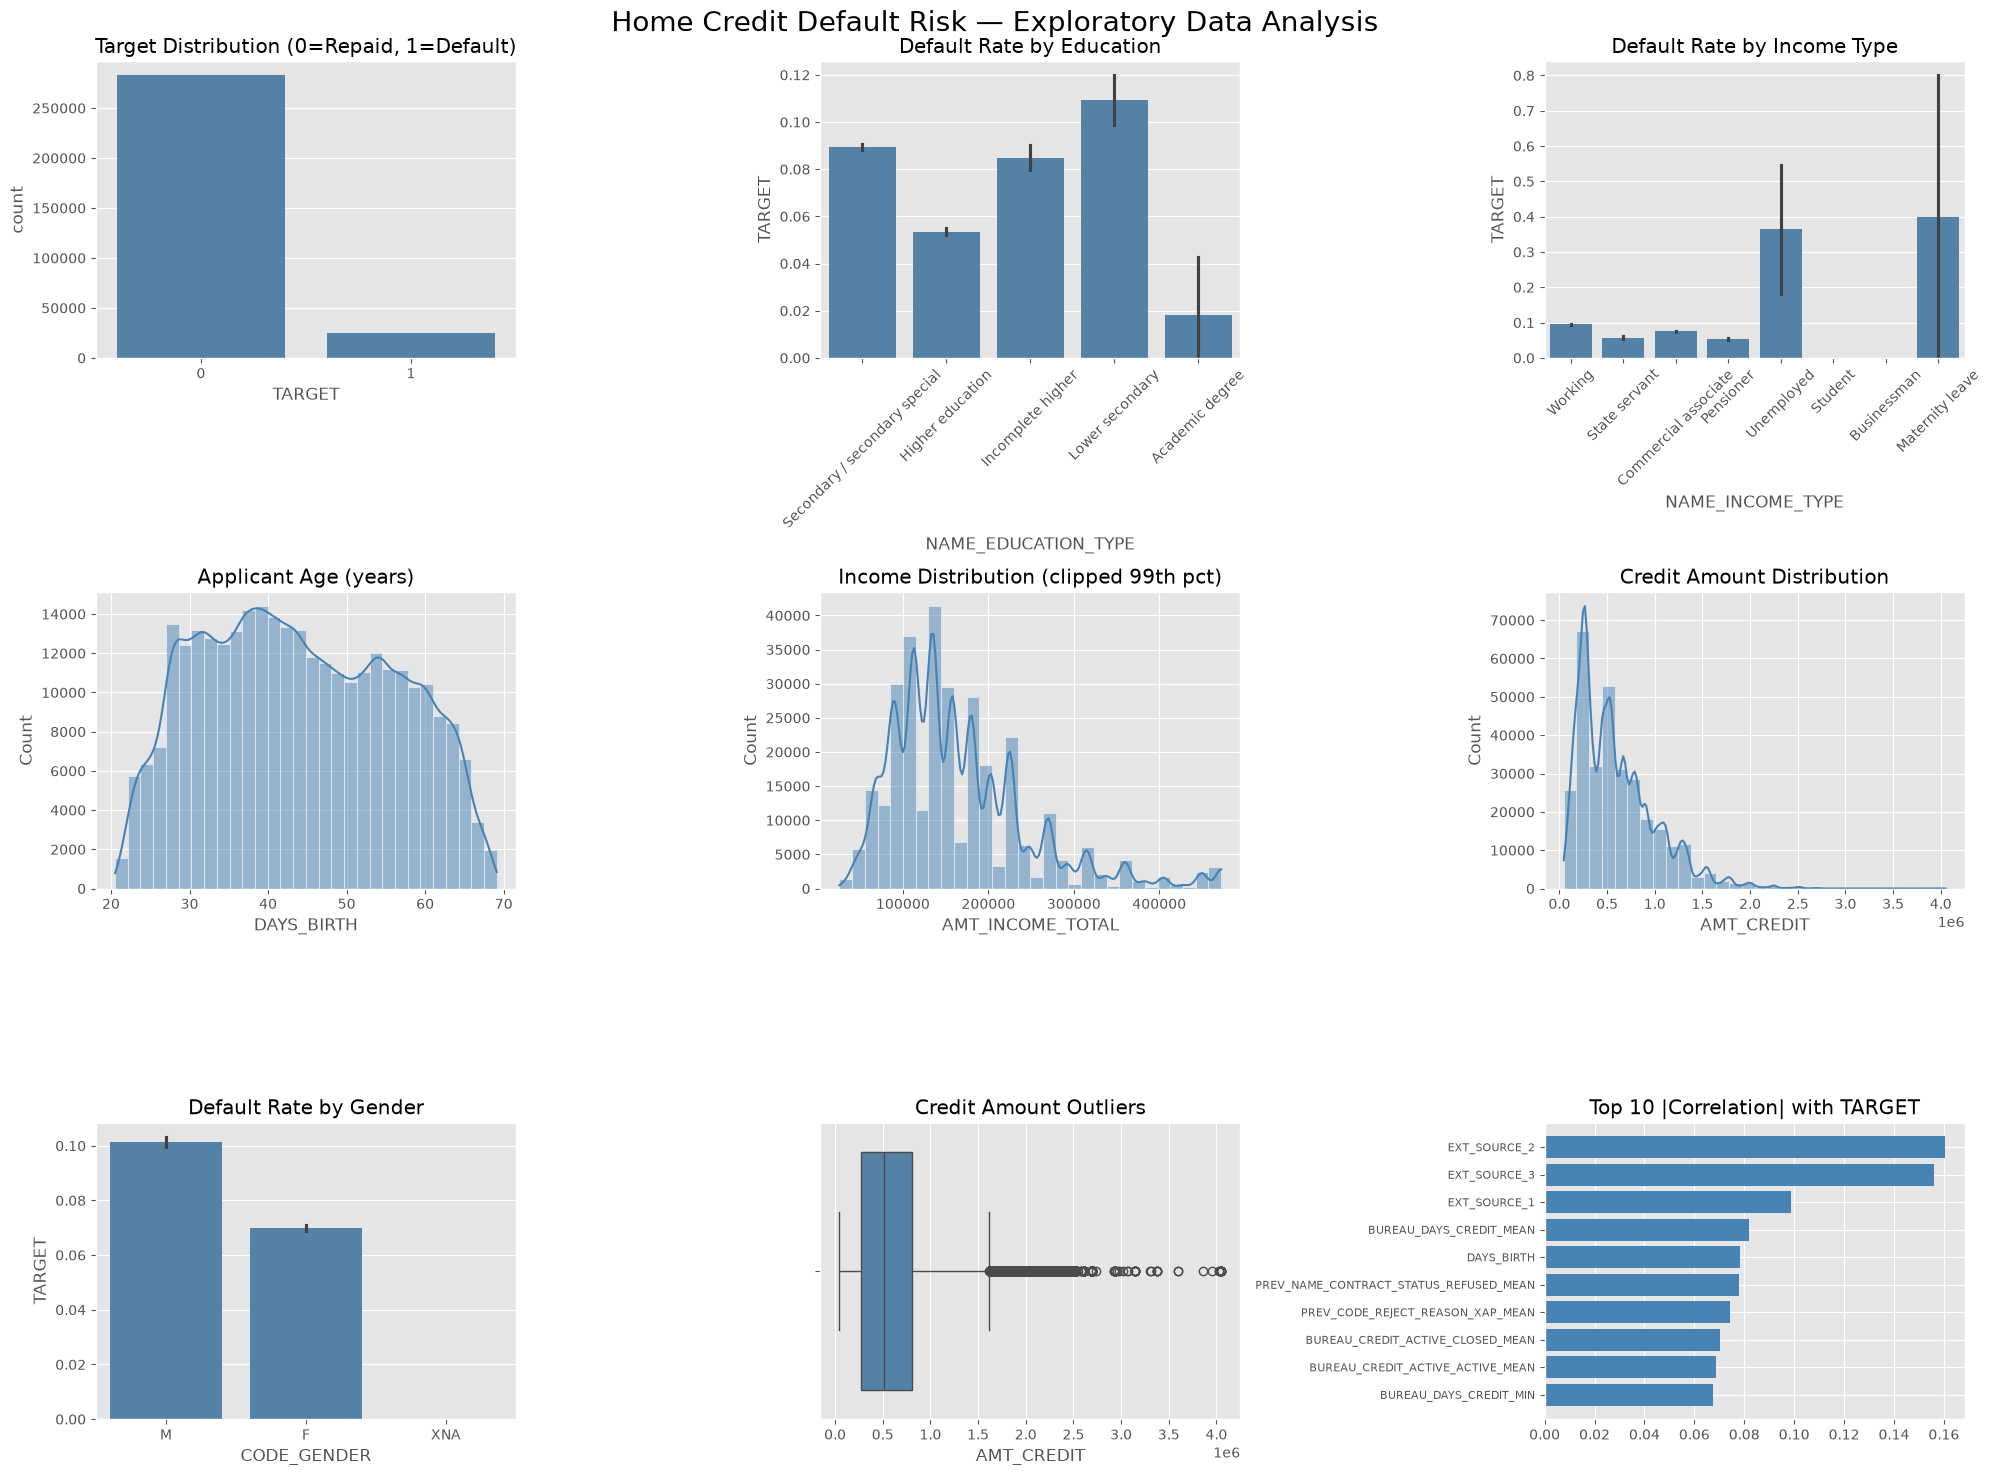

In [40]:
BLUE = "steelblue"
RED = "indianred"

plt.style.use("ggplot")

# Create dashboard
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("Home Credit Default Risk — Exploratory Data Analysis", fontsize=20)

# 1. Target distribution (class imbalance)
sns.countplot(data=train, x="TARGET", color=BLUE, ax=axes[0,0])
axes[0,0].set_title("Target Distribution (0=Repaid, 1=Default)")

# 2. Default rate by education
sns.barplot(
    data=train, x="NAME_EDUCATION_TYPE", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[0,1]
)
axes[0,1].set_title("Default Rate by Education")
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Default rate by income type
sns.barplot(
    data=train, x="NAME_INCOME_TYPE", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[0,2]
)
axes[0,2].set_title("Default Rate by Income Type")
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Age distribution
age_years = -train["DAYS_BIRTH"] / 365
sns.histplot(age_years, bins=30, kde=True, color=BLUE, ax=axes[1,0])
axes[1,0].set_title("Applicant Age (years)")

# 5. Income distribution (clipped at 99th pct - long tail otherwise)
income_clipped = train["AMT_INCOME_TOTAL"].clip(upper=train["AMT_INCOME_TOTAL"].quantile(0.99))
sns.histplot(income_clipped, bins=30, kde=True, color=BLUE, ax=axes[1,1])
axes[1,1].set_title("Income Distribution (clipped 99th pct)")

# 6. Credit amount distribution
sns.histplot(train["AMT_CREDIT"], bins=30, kde=True, color=BLUE, ax=axes[1,2])
axes[1,2].set_title("Credit Amount Distribution")

# 7. Default rate by gender
sns.barplot(
    data=train, x="CODE_GENDER", y="TARGET",
    estimator="mean", color=BLUE, ax=axes[2,0]
)
axes[2,0].set_title("Default Rate by Gender")

# 8. Credit amount boxplot (outliers)
sns.boxplot(x=train["AMT_CREDIT"], color=BLUE, ax=axes[2,1])
axes[2,1].set_title("Credit Amount Outliers")

# 9. Top 10 features correlated with TARGET
top_corr = train[numeric_cols].corrwith(train["TARGET"]).drop("TARGET").abs().sort_values(ascending=False).head(10)
axes[2,2].barh(top_corr.index[::-1], top_corr.values[::-1], color=BLUE)
axes[2,2].set_title("Top 10 |Correlation| with TARGET")
axes[2,2].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

The exploratory data analysis provided insights into the characteristics of the applicants, their financial information, and the factors associated with loan default. It showed that the dataset is imbalanced, with most applicants successfully repaying their loans. The analysis also revealed differences in default rates across education levels, income types, and gender, while the distributions of income and credit amounts showed the presence of high-value applicants and outliers. Overall, the findings suggest that loan default is influenced by several demographic and financial factors rather than a single variable.

1. Target Distribution (0 = Repaid, 1 = Default)

Interpretation

The target distribution shows that the dataset is highly imbalanced. Most applicants successfully repaid their loans (Target = 0), while only a small proportion defaulted (Target = 1). This means that default cases are relatively rare, which should be considered during model development because machine learning models may become biased towards predicting the majority class.

2. Default Rate by Education

Interpretation

The default rate varies across education levels. Applicants with lower secondary education have the highest default rate, while applicants with higher education and academic degrees have lower default rates. This suggests that higher education may be associated with a lower likelihood of loan default.

3. Default Rate by Income Type

Interpretation

The default rate differs across income groups. Applicants who are unemployed or on maternity leave appear to have higher default rates than those who are working or are state servants. However, some groups contain relatively few applicants, so these results should be interpreted with caution.

4. Applicant Age Distribution

Interpretation

Most applicants are between approximately 30 and 60 years old, with fewer applicants at younger and older ages. The distribution indicates that the majority of loan applicants are middle-aged adults.

5. Income Distribution

Interpretation

The income distribution is positively skewed. Most applicants earn moderate incomes, while a small number earn substantially higher incomes. The distribution shown has been clipped at the 99th percentile to improve visualization by reducing the effect of extremely high income values.

6. Credit Amount Distribution

Interpretation

The distribution of credit amounts is also positively skewed. Most applicants requested relatively small or moderate loan amounts, while only a few requested very large loans. This pattern is common in financial datasets.

7. Default Rate by Gender

Interpretation

Male applicants have a higher default rate than female applicants. The XNA category contains very few records and therefore does not provide meaningful information. Overall, gender appears to have some relationship with loan default, although the difference is not large.

8. Credit Amount Outliers

Interpretation

The boxplot shows several high-value outliers in the credit amount variable. Most applicants requested similar loan amounts, while a small number requested much larger loans. These outliers appear to represent genuine high-value loans rather than data errors and were therefore retained in the dataset.

9. Top 10 Features Most Correlated with TARGET

Interpretation

The chart shows the features with the strongest correlation to loan default. The external credit score variables (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3) have the strongest relationship with the target variable, indicating that applicants with better external credit scores are less likely to default. Other bureau and previous application features also contribute to predicting default, although their correlations are relatively weak. This suggests that no single feature can accurately predict default on its own, and multiple features should be used together in the machine learning model.

#### Drop constant / near-zero-variance columns

These add nothing and just bloat the feature space - but check train variance only, then apply the same drop list to test, so you never let test data influence what you keep.

In [41]:
# Identify Constant Numerical Features


# Count the number of unique values in each numerical column.
# By default, NaN values are not included in the count.
nunique = train.select_dtypes(include=[np.number]).nunique()
# Identify columns that have only one unique value.These are constant features and provide no useful information
# for machine learning models.
constant_cols = nunique[nunique <= 1].index.tolist()
# Display how many constant columns were found and list their names.
print(f"Dropping {len(constant_cols)} constant columns:", constant_cols)
# Remove Constant Features

# Drop the constant columns from the training dataset.
train = train.drop(columns=constant_cols)

# Drop the same columns from the testing dataset.
# The list comprehension ensures that only columns present in the test dataset are removed.
test = test.drop(columns=[c for c in constant_cols if c in test.columns])

Dropping 1 constant columns: ['PREV_NAME_GOODS_CATEGORY_HOUSE CONSTRUCTION_MEAN']


Constant feature detection was performed to identify numerical variables with only one unique value across all observations. Such features do not provide useful information because they do not vary between applicants and therefore cannot help distinguish between loan defaulters and non-defaulters. All identified constant features were removed from both the training and testing datasets to reduce unnecessary variables and improve the efficiency of the machine learning models.

Constant features are removed because Machine learning models learn by finding differences between observations.

If every applicant has exactly the same value for a feature, then that feature:

* cannot separate defaulters from non-defaulters,
* contains no predictive information,
* only increases the size of the dataset,
* can slightly slow down model training.

Removing constant features makes the dataset cleaner and more efficient.

### Class Imbalance Analysis

In [42]:
target_counts = train['TARGET'].value_counts()
target_pct = train['TARGET'].value_counts(normalize=True) * 100
imbalance_ratio = target_counts[0] / target_counts[1]

print(f"Class 0 (repaid):   {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Class 1 (default):  {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.1f} : 1")

Class 0 (repaid):   282,686 (91.93%)
Class 1 (default):  24,825 (8.07%)
Imbalance ratio: 11.4 : 1


In [43]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
num_df = train[numeric_cols]

### Linear separability

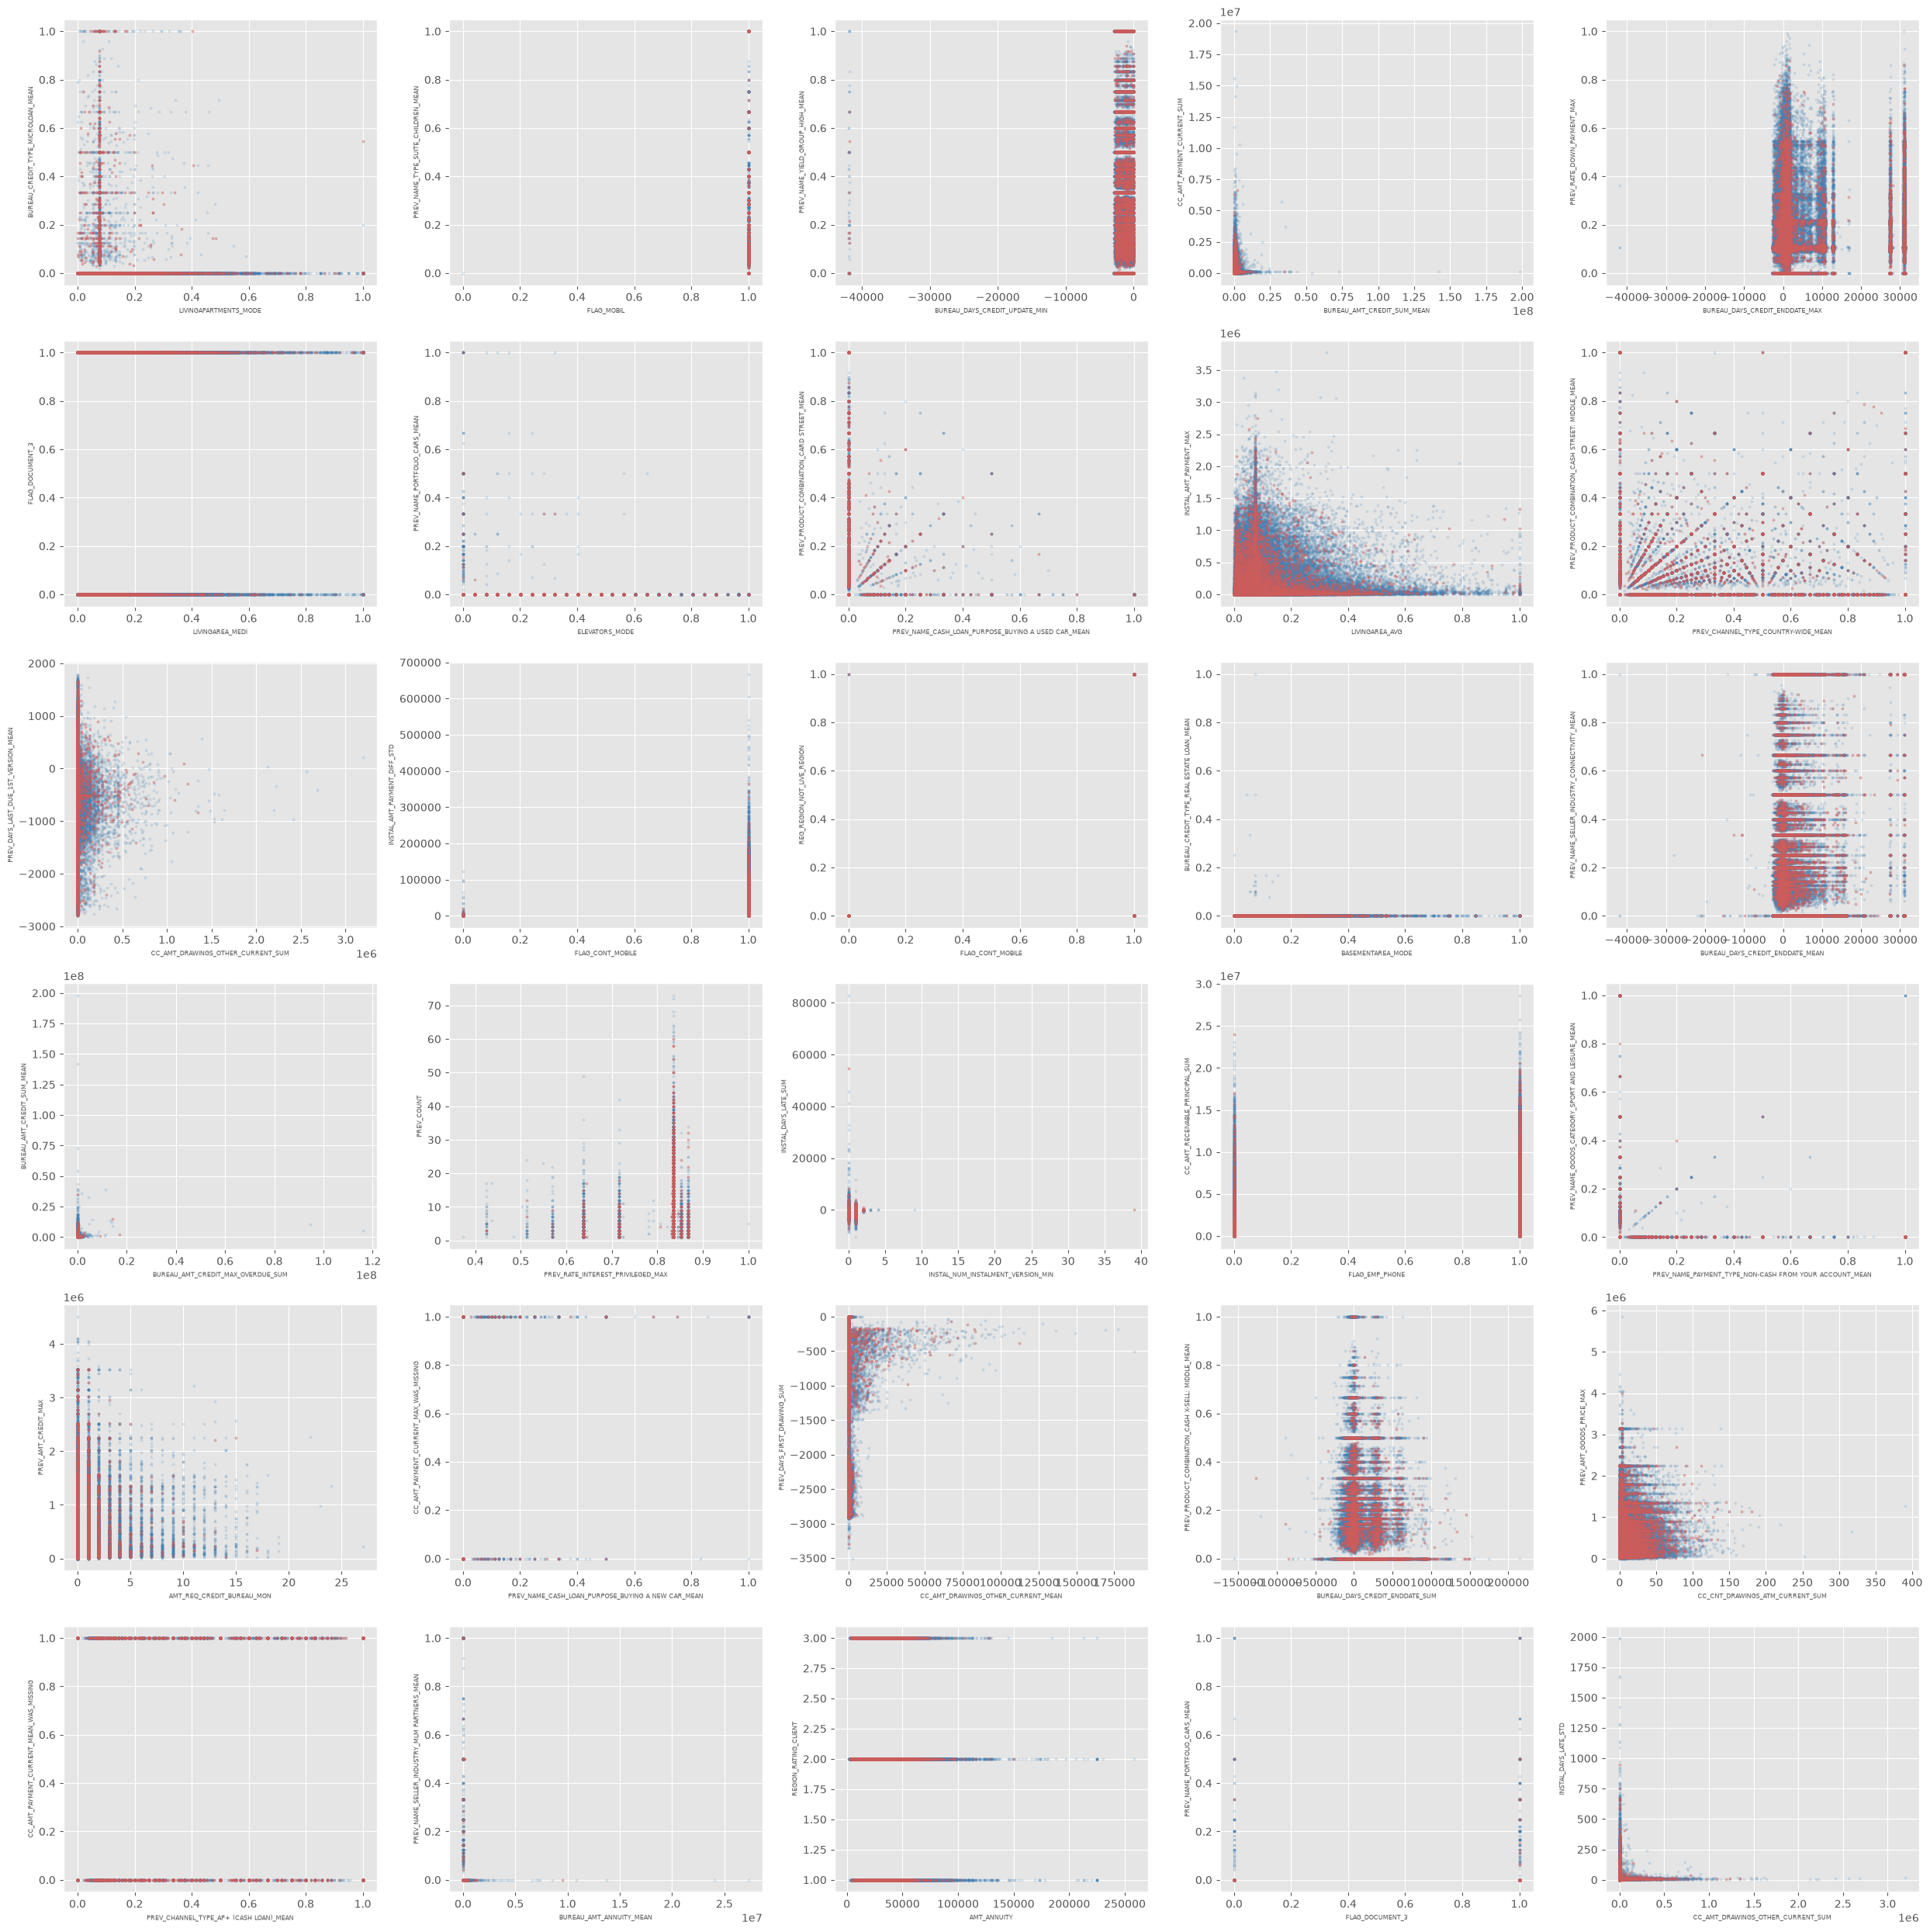

In [44]:


num_df = train[numeric_cols]  # actual data — selects those columns from train
feature_only_cols = [c for c in num_df.columns if c not in ('TARGET', 'SK_ID_CURR')]
comb = list(itertools.combinations(range(len(feature_only_cols)), 2))
rand = random.sample(comb, k=30)

fig = plt.figure(figsize=(25, 25))
for i, (a, b) in enumerate(rand):
    ax = fig.add_subplot(6, 5, i + 1)
    col_a, col_b = feature_only_cols[a], feature_only_cols[b]

    majority = num_df[num_df['TARGET'] == 0]
    minority = num_df[num_df['TARGET'] == 1]
    ax.scatter(majority[col_a], majority[col_b], c='steelblue', alpha=0.15, s=5)
    ax.scatter(minority[col_a], minority[col_b], c='indianred', alpha=0.4, s=5)
    ax.set_xlabel(col_a, fontsize=6)
    ax.set_ylabel(col_b, fontsize=6)

plt.tight_layout()
plt.show()

The scatter plots show substantial overlap between defaulters and non-defaulters across most numerical features. This indicates that the data is not linearly separable, as no single feature can clearly distinguish the two classes using a straight decision boundary. The presence of skewed distributions, outliers, and overlapping observations suggests that loan default is influenced by complex interactions among multiple variables rather than a simple linear relationship. Therefore, machine learning models capable of capturing non-linear patterns, such as Random Forest, XGBoost, LightGBM, or CatBoost, are likely to perform better than models that rely solely on linear decision boundaries.

### Preparing data set for modelling

 Encode categoricals 
 


First check how many unique values each one has (nunique()), because one-hot encoding creates one new column per unique category

In [45]:

cardinality = train[categorical_cols].nunique().sort_values(ascending=False)
print(cardinality)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
dtype: int64


In [46]:
# Count how many rows fall into each ORGANIZATION_TYPE category
org_counts = train["ORGANIZATION_TYPE"].value_counts()
print(org_counts)

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      


ORGANIZATION_TYPE is a column that tells you what kind of company each applicant works for. It has 58 different possible answers.

Some of these 58 answers show up a lot - thousands of people work in that same type of organization. 

The problem: when I one-hot encode (turn each answer into its own yes/no column), I'll get 58 new columns. That's a lot, and the rare ones don't really help the model learn much, since there's barely any data behind them.

To fix it I'll keep the 15 most common answers exactly as they are. But for every answer that's not in that top 15 (the rare ones), just relabel it as "Other" instead.

Therefore, Instead of 58 different labels, I'll only have 16 - the 15 common ones, plus one new group called "Other" that all the rare ones get lumped into.

The goal is to reduce the number of unique categories before encoding the data for machine learning.


In [47]:
# Keep only the top 15 most common organization types; group everything else into "Other"
top_orgs = train["ORGANIZATION_TYPE"].value_counts().head(15).index

train["ORGANIZATION_TYPE"] = train["ORGANIZATION_TYPE"].where(
    train["ORGANIZATION_TYPE"].isin(top_orgs), "Other"
)
test["ORGANIZATION_TYPE"] = test["ORGANIZATION_TYPE"].where(
    test["ORGANIZATION_TYPE"].isin(top_orgs), "Other"
)

print("Unique ORGANIZATION_TYPE values now:", train["ORGANIZATION_TYPE"].nunique())

Unique ORGANIZATION_TYPE values now: 15


In [48]:
train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=False)
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=False)

# Align columns (test may be missing a category train had, or vice versa)
train_target = train_encoded['TARGET']
train_ids = train_encoded['SK_ID_CURR']
test_ids = test_encoded['SK_ID_CURR']

feature_cols = [c for c in train_encoded.columns if c not in ('TARGET', 'SK_ID_CURR')]
test_encoded = test_encoded.reindex(columns=feature_cols, fill_value=0)
train_encoded = train_encoded[feature_cols]

print("train_encoded:", train_encoded.shape, "| test_encoded:", test_encoded.shape)

train_encoded: (307511, 668) | test_encoded: (48744, 668)


After encoding the categorical variables, the training dataset contained 307,511 applicants and 668 features, while the testing dataset contained 48,744 applicants and the same 668 features. The increase in the number of features was due to the conversion of categorical variables into numerical variables using encoding. Both datasets have the same number of features to ensure consistency between model training and prediction.

* *After encoding identify columns that may contain the same information (duplicate features).*

In [53]:
# Function to identify likely duplicate columns in a dataset
def find_duplicate_cols(df, sample_frac=0.1):
    
    # If the dataset is large (>50,000 rows), randomly sample 10% of the rows
    # to make the duplicate search faster. Otherwise, use the full dataset.
    sample = df.sample(frac=sample_frac, random_state=42) if len(df) > 50000 else df

    # List to store pairs of columns that appear to be duplicates
    dupes = []

    # Dictionary to store fingerprints of columns that have already been seen
    seen = {}

    # Loop through each column in the sampled dataset
    for col in sample.columns:

        # Skip the applicant ID and target variable since they should not be checked for duplicate feature values
        if col in ('SK_ID_CURR', 'TARGET'):
            continue

        # Create a simple fingerprint for the column by:
        # replacing missing values with -999
        # taking the first 1,000 values
        # converting them into a tuple for easy comparison
        key = tuple(sample[col].fillna(-999).values[:1000])

        # If this fingerprint has already been seen,
        # record the current column and its matching column as likely duplicates
        if key in seen:
            dupes.append((col, seen[key]))
        else:
            # Otherwise, remember this fingerprint and the corresponding column name
            seen[key] = col

    # Return the list of likely duplicate column pairs
    return dupes


# Run the duplicate detection function on the training dataset
dupes = find_duplicate_cols(train_encoded)

# Display the total number of likely duplicate column pairs found
# and show the first 10 pairs
print(f"Found {len(dupes)} likely duplicate columns:", dupes[:10])

Found 71 likely duplicate columns: [('FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_2'), ('FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_2'), ('BUREAU_CREDIT_DAY_OVERDUE_MAX', 'BUREAU_CREDIT_DAY_OVERDUE_SUM'), ('BUREAU_CNT_CREDIT_PROLONG_MAX', 'BUREAU_CNT_CREDIT_PROLONG_SUM'), ('BUREAU_BB_STATUS_3_MIN', 'BUREAU_BB_STATUS_2_MIN')]


The duplicate detection function identified **71 pairs of columns that may contain identical or highly similar values** in the encoded dataset. These columns were flagged as potential duplicates because they produced the same fingerprint when comparing sampled values from the data.

The results indicate that some features may be storing the same information, which could introduce redundancy into the dataset and increase the number of features unnecessarily.

However, these columns are **not yet confirmed duplicates** because the detection method only compares a sample of the dataset for efficiency. Each identified pair should be further verified using the complete dataset before removing any columns to avoid accidentally deleting useful information.


In [55]:
# Function to verify whether the candidate duplicate columns are actually identical across the entire dataset
def verify_and_get_true_duplicates(df, candidate_pairs):

    # Create an empty list to store confirmed duplicate column pairs
    confirmed = []

    # Loop through each pair of suspected duplicate columns
    for col_a, col_b in candidate_pairs:

        # Compare the two columns using the .equals() method.
        # This checks every value in both columns.
        # If the columns contain exactly the same values, return True.
        if df[col_a].equals(df[col_b]):

            # Store the confirmed duplicate pair
            confirmed.append((col_a, col_b))

    # Return confirmed duplicate pairs
    return confirmed


# Verify suspected duplicates using the encoded dataset
true_dupes = verify_and_get_true_duplicates(train_encoded, dupes)

# Display verification results
print(f"Confirmed on full data: {len(true_dupes)} / {len(dupes)} candidates")

# Display first 10 confirmed duplicate pairs
print(true_dupes[:10])

Confirmed on full data: 9 / 71 candidates
[('PREV_CODE_REJECT_REASON_CLIENT_MEAN', 'PREV_NAME_CONTRACT_STATUS_UNUSED OFFER_MEAN'), ('PREV_RATE_INTEREST_PRIMARY_MIN_WAS_MISSING', 'PREV_RATE_INTEREST_PRIVILEGED_MEAN_WAS_MISSING'), ('PREV_RATE_INTEREST_PRIVILEGED_MIN_WAS_MISSING', 'PREV_RATE_INTEREST_PRIVILEGED_MEAN_WAS_MISSING'), ('PREV_RATE_INTEREST_PRIVILEGED_MAX_WAS_MISSING', 'PREV_RATE_INTEREST_PRIVILEGED_MEAN_WAS_MISSING'), ('PREV_RATE_INTEREST_PRIMARY_MAX_WAS_MISSING', 'PREV_RATE_INTEREST_PRIVILEGED_MEAN_WAS_MISSING'), ('PREV_RATE_INTEREST_PRIMARY_MEAN_WAS_MISSING', 'PREV_RATE_INTEREST_PRIVILEGED_MEAN_WAS_MISSING'), ('PREV_DAYS_FIRST_DRAWING_MIN_WAS_MISSING', 'PREV_DAYS_FIRST_DRAWING_MAX_WAS_MISSING'), ('PREV_DAYS_FIRST_DRAWING_MEAN_WAS_MISSING', 'PREV_DAYS_FIRST_DRAWING_MAX_WAS_MISSING'), ('CC_AMT_PAYMENT_CURRENT_MAX_WAS_MISSING', 'CC_AMT_PAYMENT_CURRENT_MEAN_WAS_MISSING')]


After identifying likely duplicate features, a verification step was performed to confirm whether the suspected column pairs were truly identical across the entire training dataset. The verification used the .equals() method to compare every value in each pair of columns. Only columns that matched exactly were considered true duplicates. This approach ensured that no useful features were removed by mistake while eliminating only redundant columns that contained identical information.

###### key insights
The duplicate verification process was performed on the full encoded training dataset to confirm the suspected duplicate features. Out of the 71 candidate duplicate pairs identified during the initial sampling step, only 9 pairs were confirmed to contain exactly identical values across all observations.

#### Drop the duplicates

In [56]:
# Extract the first column from each confirmed duplicate pair.
# Since both columns contain identical information, only one needs to be kept.
cols_to_drop = [pair[0] for pair in true_dupes]

# Create cleaned encoded datasets by removing the confirmed duplicate columns.
train_encoded_clean = train_encoded.drop(columns=cols_to_drop)

test_encoded_clean = test_encoded.drop(
    columns=[c for c in cols_to_drop if c in test_encoded.columns]
)

# Display the new dataset dimensions.
print("Original train_encoded shape:", train_encoded.shape)
print("Cleaned train_encoded shape:", train_encoded_clean.shape)

print("Original test_encoded shape:", test_encoded.shape)
print("Cleaned test_encoded shape:", test_encoded_clean.shape)

Original train_encoded shape: (307511, 668)
Cleaned train_encoded shape: (307511, 659)
Original test_encoded shape: (48744, 668)
Cleaned test_encoded shape: (48744, 659)


Scalling

In [61]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Use the cleaned encoded features
X_train_clean = train_encoded_clean.copy()
X_test_clean = test_encoded_clean.copy()

# Ensure train and test have the same columns
X_test_clean = X_test_clean.reindex(
    columns=X_train_clean.columns,
    fill_value=0
)

# Fit scaler on training features and transform
train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)

# Transform test features using the same scaler
test_scaled = pd.DataFrame(
    scaler.transform(X_test_clean),
    columns=X_test_clean.columns,
    index=X_test_clean.index
)

# Add TARGET and ID back to training data
train_scaled['TARGET'] = train_target.values
train_scaled['SK_ID_CURR'] = train_ids.values

# Add ID back to testing data
test_scaled['SK_ID_CURR'] = test_ids.values

print("Scaled train shape:", train_scaled.shape)
print("Scaled test shape:", test_scaled.shape)

Scaled train shape: (307511, 661)
Scaled test shape: (48744, 660)


*check whether there are any missing values (NaN) remaining after scaling.* 

In [63]:
# Select only feature columns (exclude target and ID)
feature_cols_clean = [
    c for c in train_scaled.columns 
    if c not in ['TARGET', 'SK_ID_CURR']
]

# Count missing values in the scaled features
missing_counts = train_scaled[feature_cols_clean].isnull().sum()

# Keep only columns that still contain missing values
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Display results
print(f"{len(missing_counts)} columns still contain NaN")
print(missing_counts.head(20))

0 columns still contain NaN
Series([], dtype: int64)


After completing missing value treatment, categorical encoding, duplicate feature removal, and feature scaling, a final missing value check was performed on the processed training dataset. The analysis confirmed that 0 columns contained missing values, indicating that all features were successfully transformed into a complete numerical format suitable for machine learning model development.

This verification ensures that the dataset contains no remaining NaN values that could interfere with model training or evaluation.

### Linear Separability Check



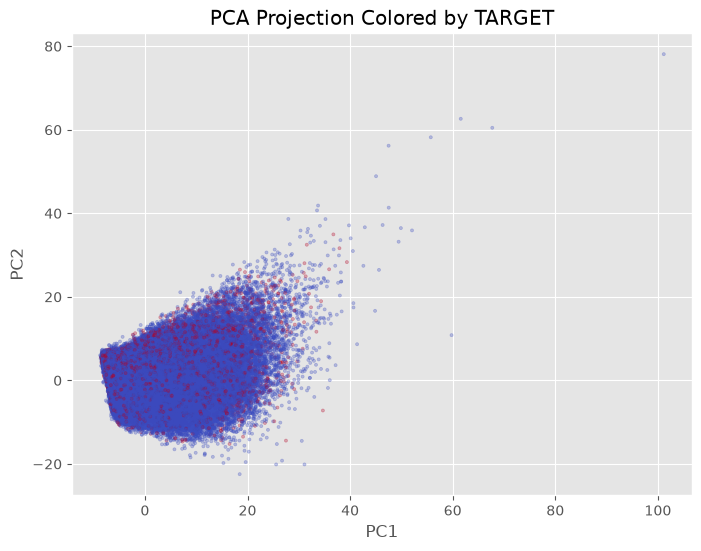

Logistic Regression (linear) AUC: 0.7756
Random Forest (non-linear) AUC:  0.7512
Gap: -0.0244


In [ ]:



# Select only feature columns.
# Exclude TARGET because it is the prediction variable.
# Exclude SK_ID_CURR because it is only an identifier.
feature_cols_clean = [
    c for c in train_scaled.columns
    if c not in ['TARGET', 'SK_ID_CURR']
]


# Create feature matrix (X) and target variable (y)
X = train_scaled[feature_cols_clean]
y = train_scaled['TARGET']


# Split the dataset into training and validation sets.
# Stratify ensures that both sets maintain the same TARGET class distribution,
# which is important because Home Credit has an imbalanced target variable.
X_train_ls, X_val_ls, y_train_ls, y_val_ls = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#  PCA Visualization

# Reduce the high-dimensional feature space (659 features)
# into 2 principal components for visualization.
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_ls)


# Plot applicants in 2D space and color points by default status.
# This helps visually check whether default and non-default applicants
# form separate clusters.
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train_ls,
    alpha=0.3,
    cmap='coolwarm',
    s=5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by TARGET')
plt.show()


# Model Comparison 

# Logistic Regression represents a linear model.
# class_weight='balanced' gives more importance to the minority class
# (default cases) to reduce the effect of class imbalance.
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_reg.fit(X_train_ls, y_train_ls)


# Calculate validation ROC-AUC score.
# ROC-AUC is suitable for imbalanced classification problems.
auc_linear = roc_auc_score(
    y_val_ls,
    log_reg.predict_proba(X_val_ls)[:, 1]
)


# Random Forest represents a non-linear model.
# It can capture complex relationships between features.
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_ls, y_train_ls)


# Calculate validation ROC-AUC for the non-linear model.
auc_nonlinear = roc_auc_score(
    y_val_ls,
    rf.predict_proba(X_val_ls)[:, 1]
)


# Display comparison results
print(f"Logistic Regression (linear) AUC: {auc_linear:.4f}")
print(f"Random Forest (non-linear) AUC:  {auc_nonlinear:.4f}")
print(f"Gap: {auc_nonlinear - auc_linear:.4f}")

##### Why The Linear Separability Diagnostic

Before building the final machine learning models, a simple diagnostic check was performed to understand the relationship between the applicant features and loan default (TARGET).

A stratified train-validation split was created to keep the same proportion of default and non-default cases in both datasets. This was important because the Home Credit dataset has many more non-default cases than default cases.

PCA (Principal Component Analysis) was used to reduce the many features into two main components so that the data could be visualized in two dimensions. The plot was colored based on the TARGET value to check whether default and non-default applicants formed separate groups. Clear separation would suggest that the problem can be handled well by a simple linear model, while overlapping groups would suggest more complex patterns.

Two simple models were then compared only for diagnostic purposes:

Logistic Regression was used to represent a linear relationship.
Random Forest was used to represent a non-linear relationship.

Their ROC-AUC scores were compared to see whether the non-linear model performed much better than the linear model.

This analysis was not used to select the final model. It was only used to understand the structure of the data and guide the choice of suitable machine learning algorithms. A small difference between the models suggests a more linear problem, while a larger difference suggests that more advanced models may be needed to capture complex patterns.

#### Linear Separability Diagnostic Results

The diagnostic comparison showed that Logistic Regression achieved a higher ROC-AUC score (0.7756) compared to Random Forest (0.7512). The performance gap was -0.0244, meaning that the non-linear model did not provide an improvement over the linear model in this initial test.

These results suggest that the relationship between the available applicant features and loan default risk contains strong linear patterns. The features appear to provide useful separation between default and non-default applicants without requiring a highly complex decision boundary.

However, this result does not rule out the presence of non-linear relationships. The Random Forest model used in this diagnostic was not fully optimized, and more advanced algorithms may still capture additional patterns. Therefore, this analysis was used only as a guide for model selection and not as the final evaluation of model performance.


Save both versions that is the  raw (unscaled) and the processed one 

In [65]:
# Save cleaned encoded data (after duplicate removal, before scaling)
train_encoded_clean.to_parquet(
    f'{OUTPUT_DIR}/train_clean.parquet',
    index=False
)

test_encoded_clean.to_parquet(
    f'{OUTPUT_DIR}/test_clean.parquet',
    index=False
)


# Save scaled processed data (ready for models that require scaling)
train_scaled.to_parquet(
    f'{OUTPUT_DIR}/train_processed.parquet',
    index=False
)

test_scaled.to_parquet(
    f'{OUTPUT_DIR}/test_processed.parquet',
    index=False
)


print("Saved:")
print("- train_clean.parquet")
print("- test_clean.parquet")
print("- train_processed.parquet")
print("- test_processed.parquet")

Saved:
- train_clean.parquet
- test_clean.parquet
- train_processed.parquet
- test_processed.parquet


### Model Preparation 

### 1. *Check target imbalance*

Before training models, I need to understand how many applicants defaulted (TARGET=1) versus those who did not (TARGET=0).

In [66]:
# Check class distribution
target_distribution = train_scaled['TARGET'].value_counts()

print(target_distribution)

# Check percentage distribution
target_percentage = train_scaled['TARGET'].value_counts(normalize=True) * 100

print(target_percentage)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


The target variable was examined to determine whether the dataset was balanced. The results showed that 282,686 applicants (91.93%) did not default on their loans (TARGET = 0), while 24,825 applicants (8.07%) defaulted (TARGET = 1).

These results indicate that the dataset is highly imbalanced, with non-default cases making up the majority of the observations. This class imbalance can affect model performance because a model may become biased towards predicting the majority class.

To address this issue, stratified sampling was used when splitting the data into training and validation sets to maintain the original class distribution. In addition, evaluation metrics such as ROC-AUC, Precision, Recall, and F1-score will be used during model evaluation because they provide a more reliable assessment of performance on imbalanced datasets than accuracy alone.

#### 2.  Feature Selection


1. **Correlation removal**. Drop one of any pair correlated above 0.9, keeping whichever of the two correlates more strongly with `TARGET`. Removes pure redundancy cheaply.


In [67]:
# Create a list of feature columns Exclude the target variable and applicant ID
feature_cols = [
    c for c in train_scaled.columns
    if c not in ['TARGET', 'SK_ID_CURR']
]

# Compute the absolute correlation matrix for all features
corr_matrix = train_scaled[feature_cols].corr().abs()

# Keep only the upper triangle of the matrix (This avoids checking the same pair twice)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identify feature pairs with correlation greater than 0.90
high_corr_pairs = [
    (col, row)
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.90
]

# Compute the absolute correlation between each feature and the target
target_corr = train_scaled[feature_cols].corrwith(
    train_scaled['TARGET']
).abs()

# Store features selected for removal
to_drop_corr = set()

# For each highly correlated pair,
# remove the feature that has the weaker correlation with TARGET
for col_a, col_b in high_corr_pairs:

    if col_a in to_drop_corr or col_b in to_drop_corr:
        continue

    if target_corr[col_a] >= target_corr[col_b]:
        to_drop_corr.add(col_b)
    else:
        to_drop_corr.add(col_a)

# Create the final feature list after removing highly correlated features
feature_cols_v1 = [
    c for c in feature_cols
    if c not in to_drop_corr
]

print(f"Dropped {len(to_drop_corr)} highly correlated features")
print(f"Remaining: {len(feature_cols_v1)} features")

Dropped 149 highly correlated features
Remaining: 510 features


The correlation analysis was carried out to identify features that contained very similar information. Features with a correlation greater than 0.90 were considered highly correlated.

For each highly correlated pair, the feature with the stronger relationship to the target variable (TARGET) was kept, while the feature with the weaker relationship was removed. This helped reduce duplicate information without removing the feature that was likely to be more useful for predicting loan default.

Reducing highly correlated features makes the dataset simpler and helps reduce multicollinearity, which is especially important for models such as Logistic Regression. At the same time, the dataset still retains the features that are most relevant to predicting the target variable.

***Its Important because***:
Removing highly correlated features reduces redundant information in the dataset. This makes the model simpler, reduces multicollinearity, improves model stability, and can reduce training time while keeping the most useful features for predicting loan default.

### **Model Development**

##### 1. *Create the final datasets*

Use the selected features after correlation removal.

In [70]:
# Final feature matrix
X = train_scaled[feature_cols_v1]

# Target variable
y = train_scaled['TARGET']

*for the test*

In [71]:
X_test = test_scaled[feature_cols_v1]

##### 2 *Train / Validation Split*

Splitting the data into training and validation sets helps evaluate how well a machine learning model performs on new, unseen data. The model learns patterns from the training set, while the validation set is used to measure its performance without influencing the learning process.

Using stratify=y ensures that both the training and validation datasets have the same proportion of default and non-default cases. This is especially important because the target variable is highly imbalanced. Keeping the same class distribution in both datasets provides a fair and reliable evaluation of the model's performance.

In [73]:
# Create the feature matrix using the selected features
selected_features = feature_cols_v1

X = train_scaled[selected_features]

# Create the target variable
y = train_scaled['TARGET']

# Split the data into training (80%) and validation (20%) sets.
# Stratify is used to maintain the same class distribution
# in both datasets because TARGET is highly imbalanced.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the size of the training and validation datasets
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

# Verify that both datasets have a similar default rate
print(f"Train default rate: {y_train.mean():.4f} | Val default rate: {y_val.mean():.4f}")

X_train: (246008, 510) | X_val: (61503, 510)
Train default rate: 0.0807 | Val default rate: 0.0807


The dataset was successfully split into training and validation sets using an 80:20 ratio. The training set contains 246,008 observations, while the validation set contains 61,503 observations, with both datasets having 510 features.

The default rate remained 8.07% in both the training and validation sets, confirming that stratified sampling preserved the original class distribution. This ensures that the validation data is representative of the training data and provides a fair and reliable evaluation of the machine learning models.

##### 3. *Train your baseline model*

* Start with Logistic Regression since it performed well in the liner separability analysis.


In [ ]:
# Create the Logistic Regression model
# class_weight='balanced' helps handle the imbalanced target classes
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [77]:
# Predict the class labels for the validation dataset
y_pred = log_model.predict(X_val)

# Predict the probability of default (TARGET = 1)
y_prob = log_model.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

# Display the evaluation metrics
print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Performance
----------------------------------------
Accuracy : 0.7081
Precision: 0.1744
Recall   : 0.7005
F1-Score : 0.2792
ROC-AUC  : 0.7714


##### Train the The advanced Models
1. XGBOOST
2. LIGHTGBM
3. CATBOOST
4. DECISION TREE
5. RANDOM FOREST

In [79]:
# Calculate the positive class weight for XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define the baseline models
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        scale_pos_weight=pos_weight,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ),

    'CatBoost': cb.CatBoostClassifier(
        iterations=300,
        depth=6,
        auto_class_weights='Balanced',
        random_state=42,
        verbose=0
    )
}

# Dictionary to store model results
baseline_results = {}

# Train and evaluate each model
for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Predict class labels
    y_pred = model.predict(X_val)

    # Predict probabilities for the positive class
    y_prob = model.predict_proba(X_val)[:, 1]

    # Store evaluation metrics
    baseline_results[name] = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "PR-AUC": average_precision_score(y_val, y_prob)
    }

    print(f"{name} completed.")

# Create a comparison table
baseline_df = (
    pd.DataFrame(baseline_results)
    .T
    .sort_values(by="ROC-AUC", ascending=False)
)

print("\nBaseline Model Comparison")
print(baseline_df.round(4))


Training Decision Tree...
Decision Tree completed.

Training Random Forest...
Random Forest completed.

Training XGBoost...
XGBoost completed.

Training CatBoost...
CatBoost completed.

Baseline Model Comparison
               Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
CatBoost         0.7642     0.1954  0.6161    0.2967   0.7663  0.2608
Random Forest    0.7416     0.1798  0.6179    0.2786   0.7539  0.2274
XGBoost          0.8176     0.2164  0.4806    0.2984   0.7490  0.2460
Decision Tree    0.6405     0.1425  0.6878    0.2360   0.7142  0.1927


**LightGBM is trained separately because**,It does not accept feature names that contain certain special characters, such as commas, colons, or brackets. These characters were introduced during one-hot encoding of categorical variables.

Unlike Logistic Regression, Decision Tree, Random Forest, XGBoost, and CatBoost, LightGBM requires feature names to follow a stricter format. Therefore, the feature names were cleaned before training the model. This preprocessing step was only necessary for LightGBM and did not affect the original datasets or the other machine learning models.

In [80]:
import re
import lightgbm as lgb


# Create copies so the original datasets remain unchanged
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

# Remove special characters from the feature names
X_train_lgb.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_train_lgb.columns
]

X_val_lgb.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X_val_lgb.columns
]

# Create the LightGBM model
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train the model
lgb_model.fit(X_train_lgb, y_train)

# Predict the class labels
y_pred = lgb_model.predict(X_val_lgb)

# Predict the probability of default
y_prob = lgb_model.predict_proba(X_val_lgb)[:, 1]

# Calculate evaluation metrics
lgb_results = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "F1-Score": f1_score(y_val, y_pred),
    "ROC-AUC": roc_auc_score(y_val, y_prob),
    "PR-AUC": average_precision_score(y_val, y_prob)
}

# Display the results
print("LightGBM Performance")
print("-" * 40)

for metric, value in lgb_results.items():
    print(f"{metric:<10}: {value:.4f}")

LightGBM Performance
----------------------------------------
Accuracy  : 0.7595
Precision : 0.1984
Recall    : 0.6512
F1-Score  : 0.3042
ROC-AUC   : 0.7814
PR-AUC    : 0.2772
